<a href="https://colab.research.google.com/github/WiseThoughts/Synoptic-Project-AI-Emotion-Chatbot/blob/main/Synoptic_Project_Model_testing_%26_dev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First I'll making/traing 2 AI models one in emotion detection within speach and the second on maniplulating the output from the LLM to be more appropiate to topic, discussion, etc.

#code

In [ ]:
##incase of mount problems only!!!!!
import os, shutil
from google.colab import drive

mountpoint = "/content/drive"

#clear mountpoint
if os.path.exists(mountpoint) and os.path.isdir(mountpoint) and os.listdir(mountpoint):
    shutil.rmtree(mountpoint)
#recreate directory
os.makedirs(mountpoint, exist_ok=True)
#mount Drive
drive.mount(mountpoint)


In [ ]:
# mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')
# change current working directory
import os
os.chdir('/content/drive/MyDrive/Synoptic_Project/')

Mounted at /content/drive


In [ ]:

##Load files
import os
import pandas as pd
import numpy as np
import json

BASE = "/content/drive/MyDrive/Synoptic_Project/data/raw"

GOEMOTIONS_DIR = os.path.join(BASE, "goemotions")
EMOTION_DET_PATH = os.path.join(BASE, "Emotion-Detection-From-Text", "tweet_emotions.csv")
EMOBANK_PATH = os.path.join(BASE, "emobank", "emobank.csv")

print("GoEmotions files:", os.listdir(GOEMOTIONS_DIR))
print("Emotion detection file exists:", os.path.exists(EMOTION_DET_PATH))
print("EmoBank file exists:", os.path.exists(EMOBANK_PATH))

##Merged columns for dataset
MERGED_COLUMNS = [
    "text",
    "emotion_labels",
    "raw_label",
    "vad_valence",
    "vad_arousal",
    "vad_dominance",
    "source",
    "task_type",
    "original_split",
    "source_id"
]

##convert labels to numbers
GOEMOTIONS_LABELS = {
    0: "admiration",
    1: "amusement",
    2: "anger",
    3: "annoyance",
    4: "approval",
    5: "caring",
    6: "confusion",
    7: "curiosity",
    8: "desire",
    9: "disappointment",
    10: "disapproval",
    11: "disgust",
    12: "embarrassment",
    13: "excitement",
    14: "fear",
    15: "gratitude",
    16: "grief",
    17: "joy",
    18: "love",
    19: "nervousness",
    20: "optimism",
    21: "pride",
    22: "realization",
    23: "relief",
    24: "remorse",
    25: "sadness",
    26: "surprise",
    27: "neutral"
}

def parse_goemotions_labels(label_str):
    label_str = str(label_str).strip()
    if not label_str:
        return []
    ids = [int(x.strip()) for x in label_str.split(",") if x.strip() != ""]
    return [GOEMOTIONS_LABELS[i] for i in ids if i in GOEMOTIONS_LABELS]

def load_goemotions_split(path, split_name):
    df = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=["text", "label_ids", "source_id"],
        quoting=3,
        keep_default_na=False
    )

    df["emotion_labels"] = df["label_ids"].apply(parse_goemotions_labels)
    df["raw_label"] = df["label_ids"].astype(str)
    df["vad_valence"] = np.nan
    df["vad_arousal"] = np.nan
    df["vad_dominance"] = np.nan
    df["source"] = "goemotions"
    df["task_type"] = "classification"
    df["original_split"] = split_name

    return df[MERGED_COLUMNS]

go_train = load_goemotions_split(os.path.join(GOEMOTIONS_DIR, "train.tsv"), "train")
go_dev = load_goemotions_split(os.path.join(GOEMOTIONS_DIR, "dev.tsv"), "dev")
go_test = load_goemotions_split(os.path.join(GOEMOTIONS_DIR, "test.tsv"), "test")

goemotions_df = pd.concat([go_train, go_dev, go_test], ignore_index=True)

print(goemotions_df.head())
print("GoEmotions rows:", len(goemotions_df))

##Map emotion-detection-from-text classes to goemotions
EMOTION_DET_MAPPING = {
    "empty": ["neutral"],
    "neutral": ["neutral"],
    "sadness": ["sadness"],
    "worry": ["nervousness"],
    "surprise": ["surprise"],
    "love": ["love"],
    "fun": ["joy"],
    "enthusiasm": ["excitement"],
    "hate": ["anger"],
    "anger": ["anger"],
    "happiness": ["joy"],
    "relief": ["relief"],
    "boredom": ["disappointment"]
}

def load_emotion_detection(path):
    df = pd.read_csv(path)

    # standardize column names just in case
    df.columns = [c.strip().lower() for c in df.columns]

    expected = {"tweet_id", "sentiment", "content"}
    missing = expected - set(df.columns)
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")

    df["text"] = df["content"].astype(str)
    df["raw_label"] = df["sentiment"].astype(str)
    df["emotion_labels"] = df["raw_label"].str.lower().map(EMOTION_DET_MAPPING)

    # keep unmapped rows visible rather than silently dropping them
    unmapped = df[df["emotion_labels"].isna()]["raw_label"].value_counts()
    if len(unmapped) > 0:
        print("Unmapped emotion_detection labels found:")
        print(unmapped)

    df["vad_valence"] = np.nan
    df["vad_arousal"] = np.nan
    df["vad_dominance"] = np.nan
    df["source"] = "emotion_detection"
    df["task_type"] = "classification"
    df["original_split"] = "unknown"
    df["source_id"] = df["tweet_id"].astype(str)

    return df[MERGED_COLUMNS]

emotion_detection_df = load_emotion_detection(EMOTION_DET_PATH)

print(emotion_detection_df.head())
print("Emotion detection rows:", len(emotion_detection_df))

##Map emobank
def load_emobank(path):
    df = pd.read_csv(path)

    # standardize column names
    df.columns = [c.strip() for c in df.columns]

    expected = {"id", "split", "V", "A", "D", "text"}
    missing = expected - set(df.columns)
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")

    df["text"] = df["text"].astype(str)
    df["emotion_labels"] = None
    df["raw_label"] = None
    df["vad_valence"] = pd.to_numeric(df["V"], errors="coerce")
    df["vad_arousal"] = pd.to_numeric(df["A"], errors="coerce")
    df["vad_dominance"] = pd.to_numeric(df["D"], errors="coerce")
    df["source"] = "emobank"
    df["task_type"] = "vad"
    df["original_split"] = df["split"].astype(str)
    df["source_id"] = df["id"].astype(str)

    return df[MERGED_COLUMNS]

emobank_df = load_emobank(EMOBANK_PATH)

print(emobank_df.head())
print("EmoBank rows:", len(emobank_df))

##Merge without any data prep
merged_raw_df = pd.concat(
    [goemotions_df, emotion_detection_df, emobank_df],
    ignore_index=True
)

print("Total merged rows:", len(merged_raw_df))
print(merged_raw_df.sample(10, random_state=42))

##save merged file
OUTPUT_DIR = "/content/drive/MyDrive/Synoptic_Project/data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

merged_to_save = merged_raw_df.copy()

merged_to_save["emotion_labels"] = merged_to_save["emotion_labels"].apply(
    lambda x: json.dumps(x) if isinstance(x, list) else ""
)

csv_path = os.path.join(OUTPUT_DIR, "merged_raw_preclean.csv")
jsonl_path = os.path.join(OUTPUT_DIR, "merged_raw_preclean.jsonl")

merged_to_save.to_csv(csv_path, index=False)

with open(jsonl_path, "w", encoding="utf-8") as f:
    for _, row in merged_raw_df.iterrows():
        rec = row.to_dict()
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

print("Saved CSV:", csv_path)
print("Saved JSONL:", jsonl_path)

##vailidty check
print("\nRows by source:")
print(merged_raw_df["source"].value_counts(dropna=False))

print("\nRows by task type:")
print(merged_raw_df["task_type"].value_counts(dropna=False))

print("\nMissing text rows:")
print(merged_raw_df["text"].isna().sum())

print("\nEmpty text rows:")
print((merged_raw_df["text"].astype(str).str.strip() == "").sum())

print("\nExample emotion_detection labels after mapping:")

tmp = emotion_detection_df[["raw_label", "emotion_labels"]].copy()
tmp["emotion_labels"] = tmp["emotion_labels"].apply(
    lambda x: tuple(x) if isinstance(x, list) else x
)

print(
    tmp.drop_duplicates()
       .sort_values("raw_label")
)

print("\nGoEmotions multi-label examples:")
print(goemotions_df[goemotions_df["emotion_labels"].apply(lambda x: len(x) > 1)].head(10))

##check for unmapped data
unmapped = emotion_detection_df[
    emotion_detection_df["emotion_labels"].isna()
]["raw_label"].value_counts()

print(unmapped)

tmp = emotion_detection_df[["raw_label","emotion_labels"]].copy()

tmp["emotion_labels"] = tmp["emotion_labels"].apply(
    lambda x: tuple(x) if isinstance(x,list) else x
)

print(tmp.drop_duplicates().sort_values("raw_label"))

GoEmotions files: ['dev.tsv', 'test.tsv', 'train.tsv']
Emotion detection file exists: True
EmoBank file exists: True
                                                text emotion_labels raw_label  \
0  My favourite food is anything I didn't have to...      [neutral]        27   
1  Now if he does off himself, everyone will thin...      [neutral]        27   
2                     WHY THE FUCK IS BAYLESS ISOING        [anger]         2   
3                        To make her feel threatened         [fear]        14   
4                             Dirty Southern Wankers    [annoyance]         3   

   vad_valence  vad_arousal  vad_dominance      source       task_type  \
0          NaN          NaN            NaN  goemotions  classification   
1          NaN          NaN            NaN  goemotions  classification   
2          NaN          NaN            NaN  goemotions  classification   
3          NaN          NaN            NaN  goemotions  classification   
4          NaN          Na

In [ ]:
import os
import re
import json
import html
import unicodedata
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

INPUT_PATH = "/content/drive/MyDrive/Synoptic_Project/data/processed/merged_raw_preclean.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Synoptic_Project/data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_SEED = 42

df = pd.read_csv(INPUT_PATH)

print("Loaded rows:", len(df))
print(df.head())

#convert back to lists
def parse_emotion_labels(x):
    if pd.isna(x) or str(x).strip() == "":
        return None
    try:
        val = json.loads(x)
        return val if isinstance(val, list) else None
    except Exception:
        return None

df["emotion_labels"] = df["emotion_labels"].apply(parse_emotion_labels)

print(df[["emotion_labels", "source"]].head())

#clean text
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
MENTION_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"#(\w+)")
MULTISPACE_PATTERN = re.compile(r"\s+")
REPEATED_PUNCT_PATTERN = re.compile(r"([!?.,])\1{2,}")
CONTROL_CHARS_PATTERN = re.compile(r"[\r\n\t]+")

def normalize_unicode_text(text):
    text = unicodedata.normalize("NFKC", text)
    return text

def standardize_quotes(text):
    replacements = {
        "\u2018": "'", # left single quote
        "\u2019": "'",# right single quote
        "\u201c": '"', # left double quote
        "\u201d": '"',# right double quote
        "\u2013": "-", # en dash
        "\u2014": "-", # em dash
        "\u2026": "...", # ellipsis
        "\xa0": " ", # non-breaking space
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    #normalize whitespace
    text = normalize_unicode_text(text)
    text = CONTROL_CHARS_PATTERN.sub(" ", text)

    #standardize quotes
    text = standardize_quotes(text)

    #HTML artifacts
    text = html.unescape(text)

    #URLs, mentions, hashtags
    text = URL_PATTERN.sub(" [URL] ", text)
    text = MENTION_PATTERN.sub(" [USER] ", text)
    text = HASHTAG_PATTERN.sub(r" \1 ", text)

    #reduce repeated punctuation
    text = REPEATED_PUNCT_PATTERN.sub(r"\1\1", text)

    #collapse whitespace
    text = MULTISPACE_PATTERN.sub(" ", text).strip()
    return text

df["text_original"] = df["text"]
df["text"] = df["text"].apply(clean_text)

print(df[["text_original", "text"]].head(10))

#remove broken & very low values
def is_low_value_text(text):
    if pd.isna(text):
        return True

    text = str(text).strip()

    if text == "":
        return True

    # too short to be useful
    if len(text) < 3:
        return True

    # only punctuation
    if re.fullmatch(r"[\W_]+", text):
        return True

    #single token with no semantic value
    low_value_tokens = {
        "lol", "ok", "okay", "yo", "hi", "hey", "hmm", "um", "uh", "nah"
    }
    if text.lower() in low_value_tokens:
        return True

    return False

before_low_value = len(df)
df = df[~df["text"].apply(is_low_value_text)].copy()
after_low_value = len(df)

print("Removed low-value rows:", before_low_value - after_low_value)
print("Remaining rows:", after_low_value)

#check and remove exact duplicates
#duplicate text with conflicting labels
#create hashable label key
def labels_to_key(x):
    if isinstance(x, list):
        return tuple(sorted(x))
    return None

df["emotion_labels_key"] = df["emotion_labels"].apply(labels_to_key)

#full row duplicates
before_exact = len(df)

df = df.drop_duplicates(
    subset=[
        "text",
        "emotion_labels_key",
        "vad_valence",
        "vad_arousal",
        "vad_dominance",
        "source",
        "task_type"
    ]
).copy()

after_exact = len(df)
print("Removed exact duplicates:", before_exact - after_exact)
print("Remaining rows:", after_exact)

#duplicate text with same labels
before_text_label = len(df)

df = df.drop_duplicates(
    subset=[
        "text",
        "emotion_labels_key",
        "task_type"
    ]
).copy()

after_text_label = len(df)
print("Removed duplicate text+label rows:", before_text_label - after_text_label)
print("Remaining rows:", after_text_label)

#inspect duplicate text
conflicts = (
    df[df["task_type"] == "classification"]
    .groupby("text")["emotion_labels_key"]
    .nunique()
    .reset_index(name="n_unique_label_sets")
)

conflicts = conflicts[conflicts["n_unique_label_sets"] > 1].sort_values(
    "n_unique_label_sets", ascending=False
)

print("Texts with conflicting label sets:", len(conflicts))
print(conflicts.head(20))

#examples
if len(conflicts) > 0:
    sample_conflict_text = conflicts.iloc[0]["text"]
    print("Sample conflicting text:", sample_conflict_text)
    print(
        df[df["text"] == sample_conflict_text][
            ["text", "emotion_labels", "raw_label", "source", "task_type"]
        ]
    )

#close copy detection
def fingerprint_text(text):
    text = text.lower()
    text = re.sub(r"\[url\]", "", text)
    text = re.sub(r"\[user\]", "", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_fingerprint"] = df["text"].apply(fingerprint_text)

near_dupes = (
    df.groupby("text_fingerprint")
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

near_dupes = near_dupes[
    (near_dupes["count"] > 1) & (near_dupes["text_fingerprint"] != "")
]

print("Potential near-duplicate:", len(near_dupes))
print(near_dupes.head(20))

#show example
if len(near_dupes) > 0:
    fp = near_dupes.iloc[0]["text_fingerprint"]
    print(df[df["text_fingerprint"] == fp][["text", "emotion_labels", "source"]].head(20))

#validity checks
print("\nRows by source:")
print(df["source"].value_counts(dropna=False))

print("\nRows by task type:")
print(df["task_type"].value_counts(dropna=False))

print("\nMissing text rows:")
print(df["text"].isna().sum())

print("\nEmpty text rows:")
print((df["text"].astype(str).str.strip() == "").sum())

print("\nClassification rows missing emotion labels:")
print(
    df[(df["task_type"] == "classification") & (df["emotion_labels"].isna())].shape[0]
)

print("\nVAD rows missing any V/A/D values:")
print(
    df[
        (df["task_type"] == "vad") &
        (
            df["vad_valence"].isna() |
            df["vad_arousal"].isna() |
            df["vad_dominance"].isna()
        )
    ].shape[0]
)

#remove generic phrases (yes, no, thanks, happy day, etc)
THRESHOLD = 30  # tuneable
bad_fingerprints = set(
    near_dupes[near_dupes["count"] > THRESHOLD]["text_fingerprint"]
)
before = len(df)
df = df[~df["text_fingerprint"].isin(bad_fingerprints)].copy()
after = len(df)
print("Removed high-frequency generic phrases:", before - after)

#shuffle dataset
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
print(df.head())

#split train/test/validate
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_SEED,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    shuffle=True
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

#save cleaned dataset
def labels_to_json(x):
    if isinstance(x, list):
        return json.dumps(x)
    return ""

save_df = df.copy()
save_train = train_df.copy()
save_val = val_df.copy()
save_test = test_df.copy()

for frame in [save_df, save_train, save_val, save_test]:
    frame["emotion_labels"] = frame["emotion_labels"].apply(labels_to_json)

cleaned_csv = os.path.join(OUTPUT_DIR, "merged_cleaned.csv")
train_csv = os.path.join(OUTPUT_DIR, "train_cleaned.csv")
val_csv = os.path.join(OUTPUT_DIR, "validation_cleaned.csv")
test_csv = os.path.join(OUTPUT_DIR, "test_cleaned.csv")
conflicts_csv = os.path.join(OUTPUT_DIR, "label_conflicts.csv")
near_dupes_csv = os.path.join(OUTPUT_DIR, "near_duplicates.csv")

save_df.to_csv(cleaned_csv, index=False)
save_train.to_csv(train_csv, index=False)
save_val.to_csv(val_csv, index=False)
save_test.to_csv(test_csv, index=False)
conflicts.to_csv(conflicts_csv, index=False)
near_dupes.to_csv(near_dupes_csv, index=False)

print("Saved:", cleaned_csv)
print("Saved:", train_csv)
print("Saved:", val_csv)
print("Saved:", test_csv)
print("Saved:", conflicts_csv)
print("Saved:", near_dupes_csv)

#final cleaning report
report = {
    "input_rows": int(len(pd.read_csv(INPUT_PATH))),
    "output_rows": int(len(df)),
    "train_rows": int(len(train_df)),
    "validation_rows": int(len(val_df)),
    "test_rows": int(len(test_df)),
    "rows_by_source": df["source"].value_counts(dropna=False).to_dict(),
    "rows_by_task_type": df["task_type"].value_counts(dropna=False).to_dict(),
    "conflicting_text_count": int(len(conflicts)),
    "near_duplicate_group_count": int(len(near_dupes)),
}

report_path = os.path.join(OUTPUT_DIR, "cleaning_report.json")
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print("Saved:", report_path)
print(json.dumps(report, indent=2))


Loaded rows: 104325
                                                text emotion_labels raw_label  \
0  My favourite food is anything I didn't have to...    ["neutral"]        27   
1  Now if he does off himself, everyone will thin...    ["neutral"]        27   
2                     WHY THE FUCK IS BAYLESS ISOING      ["anger"]         2   
3                        To make her feel threatened       ["fear"]        14   
4                             Dirty Southern Wankers  ["annoyance"]         3   

   vad_valence  vad_arousal  vad_dominance      source       task_type  \
0          NaN          NaN            NaN  goemotions  classification   
1          NaN          NaN            NaN  goemotions  classification   
2          NaN          NaN            NaN  goemotions  classification   
3          NaN          NaN            NaN  goemotions  classification   
4          NaN          NaN            NaN  goemotions  classification   

  original_split source_id  
0          train   

Loaded cleaned rows: 103489
                                                text emotion_labels  \
0  just got home from the show opening. fantastic...     ["relief"]   
1  muscle-y shirtless man in a kilt handling ball...    ["neutral"]   
2  Getting used to getting up in the cold, but my...    ["sadness"]   
3  [USER] Yea I think I waited to long. oh well. ...        ["joy"]   
4              > welcome to reality Oh thank [NAME]!  ["gratitude"]   

   raw_label  vad_valence  vad_arousal  vad_dominance             source  \
0     relief          NaN          NaN            NaN  emotion_detection   
1         27          NaN          NaN            NaN         goemotions   
2    sadness          NaN          NaN            NaN  emotion_detection   
3  happiness          NaN          NaN            NaN  emotion_detection   
4         15          NaN          NaN            NaN         goemotions   

        task_type original_split   source_id  \
0  classification        unknown  175171

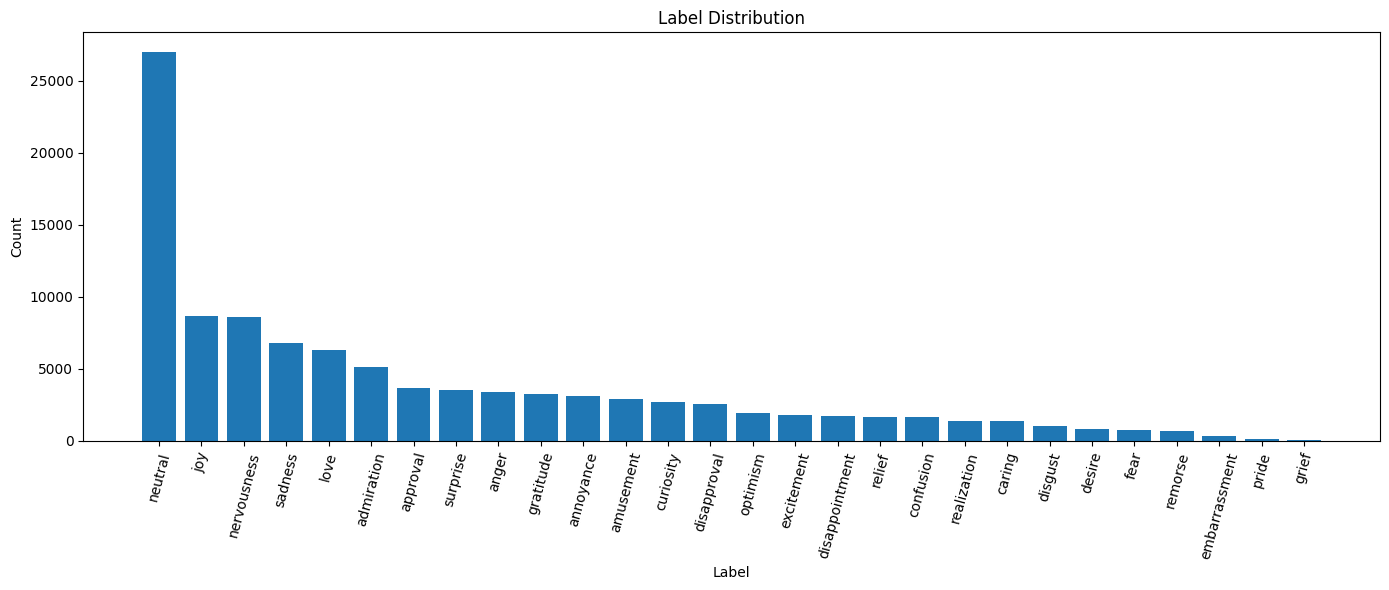

source       emotion_detection  goemotions
label                                     
neutral                   9277       17724
joy                       6918        1780
nervousness               8410         207
sadness                   5155        1623
love                      3745        2546
admiration                   0        5110
approval                     0        3683
surprise                  2181        1328
anger                     1432        1957
gratitude                    0        3279
annoyance                    0        3092
amusement                    0        2893
curiosity                    0        2720
disapproval                  0        2579
optimism                     0        1973


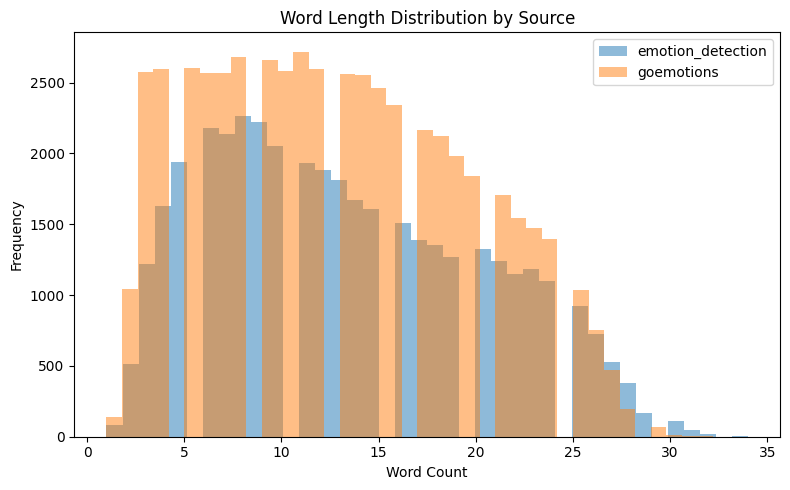

In [ ]:
#load cleanded dataset
import os
import json
import math
import pandas as pd
import numpy as np

INPUT_PATH = "/content/drive/MyDrive/Synoptic_Project/data/processed/merged_cleaned.csv"
ANALYSIS_DIR = "/content/drive/MyDrive/Synoptic_Project/data/analysis"
os.makedirs(ANALYSIS_DIR, exist_ok=True)

df = pd.read_csv(INPUT_PATH)

print("Loaded cleaned rows:", len(df))
print(df.head())

#parse goemotion structer back to list
def parse_emotion_labels(x):
    if pd.isna(x) or str(x).strip() == "":
        return None
    try:
        val = json.loads(x)
        return val if isinstance(val, list) else None
    except Exception:
        return None

df["emotion_labels"] = df["emotion_labels"].apply(parse_emotion_labels)

print(df[["emotion_labels", "source", "task_type"]].head(10))

#build clasifactions and vad set
cls_df = df[df["task_type"] == "classification"].copy()
vad_df = df[df["task_type"] == "vad"].copy()

print("Classification rows:", len(cls_df))
print("VAD rows:", len(vad_df))

#analysis columns
def label_count(x):
    if isinstance(x, list):
        return len(x)
    return 0

def labels_to_key(x):
    if isinstance(x, list):
        return tuple(sorted(x))
    return None

cls_df["n_labels"] = cls_df["emotion_labels"].apply(label_count)
cls_df["emotion_labels_key"] = cls_df["emotion_labels"].apply(labels_to_key)
cls_df["is_multilabel"] = cls_df["n_labels"] > 1

print(cls_df[["emotion_labels", "n_labels", "is_multilabel"]].head(10))

#Expand labels
exploded = cls_df.explode("emotion_labels").copy()
exploded = exploded.rename(columns={"emotion_labels": "label"})
exploded = exploded[exploded["label"].notna()].copy()

print("Exploded label rows:", len(exploded))
print(exploded[["text", "label", "source"]].head(10))

#label distrubution
label_counts = (
    exploded["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

label_counts["percent_of_label_occurrences"] = (
    label_counts["count"] / label_counts["count"].sum() * 100
)

label_counts["percent_of_classification_rows"] = (
    label_counts["count"] / len(cls_df) * 100
)

print(label_counts)
label_counts.to_csv(os.path.join(ANALYSIS_DIR, "label_distribution.csv"), index=False)

#rare label analysis
RARE_THRESHOLD = 500

rare_labels = label_counts[label_counts["count"] < RARE_THRESHOLD].copy()
print(f"Labels with fewer than {RARE_THRESHOLD} occurrences:")
print(rare_labels)

rare_labels.to_csv(os.path.join(ANALYSIS_DIR, "rare_labels.csv"), index=False)

#dominance (likely from "neutrual") analysis
neutral_label_occurrences = int((exploded["label"] == "neutral").sum())
neutral_row_occurrences = int(
    cls_df["emotion_labels"].apply(lambda x: isinstance(x, list) and "neutral" in x).sum()
)

neutral_report = {
    "neutral_label_occurrences": neutral_label_occurrences,
    "total_label_occurrences": int(len(exploded)),
    "neutral_percent_of_label_occurrences": round(
        neutral_label_occurrences / len(exploded) * 100, 4
    ),
    "neutral_row_occurrences": neutral_row_occurrences,
    "total_classification_rows": int(len(cls_df)),
    "neutral_percent_of_classification_rows": round(
        neutral_row_occurrences / len(cls_df) * 100, 4
    ),
}

print(json.dumps(neutral_report, indent=2))

with open(os.path.join(ANALYSIS_DIR, "neutral_report.json"), "w") as f:
    json.dump(neutral_report, f, indent=2)

#domaninace source analysis (which soucrce is contriubing to the most "noise")
neutral_by_source = (
    exploded[exploded["label"] == "neutral"]
    .groupby("source")
    .size()
    .reset_index(name="neutral_count")
)

source_cls_counts = (
    cls_df.groupby("source")
    .size()
    .reset_index(name="classification_rows")
)

neutral_by_source = neutral_by_source.merge(source_cls_counts, on="source", how="left")
neutral_by_source["neutral_percent_of_source_rows"] = (
    neutral_by_source["neutral_count"] / neutral_by_source["classification_rows"] * 100
)

print(neutral_by_source)
neutral_by_source.to_csv(os.path.join(ANALYSIS_DIR, "neutral_by_source.csv"), index=False)

#source contriubution per label
source_label_matrix = pd.crosstab(
    exploded["label"],
    exploded["source"]
)

print(source_label_matrix)

source_label_matrix.to_csv(os.path.join(ANALYSIS_DIR, "source_label_matrix.csv"))

source_label_props = source_label_matrix.div(source_label_matrix.sum(axis=1), axis=0) * 100

print(source_label_props.round(2))
source_label_props.round(4).to_csv(
    os.path.join(ANALYSIS_DIR, "source_label_matrix_percent.csv")
)

#source exculsive labels
exclusive_threshold = 0.90  # 90%
exclusive_rows = []

for label in source_label_props.index:
    row = source_label_props.loc[label]
    top_source = row.idxmax()
    top_pct = row.max()
    if top_pct >= exclusive_threshold * 100:
        exclusive_rows.append({
            "label": label,
            "dominant_source": top_source,
            "dominant_source_percent": top_pct
        })

exclusive_df = pd.DataFrame(exclusive_rows).sort_values(
    "dominant_source_percent", ascending=False
)

print(exclusive_df)
exclusive_df.to_csv(os.path.join(ANALYSIS_DIR, "source_exclusive_labels.csv"), index=False)

#multi vs single label balance
multilabel_report = {
    "classification_rows": int(len(cls_df)),
    "single_label_rows": int((cls_df["n_labels"] == 1).sum()),
    "multilabel_rows": int((cls_df["n_labels"] > 1).sum()),
    "single_label_percent": round((cls_df["n_labels"] == 1).mean() * 100, 4),
    "multilabel_percent": round((cls_df["n_labels"] > 1).mean() * 100, 4),
    "average_labels_per_row": round(cls_df["n_labels"].mean(), 4),
}

print(json.dumps(multilabel_report, indent=2))

with open(os.path.join(ANALYSIS_DIR, "multilabel_report.json"), "w") as f:
    json.dump(multilabel_report, f, indent=2)

#multi-label balance
multilabel_by_source = (
    cls_df.groupby("source")
    .agg(
        classification_rows=("text", "size"),
        single_label_rows=("is_multilabel", lambda x: (~x).sum()),
        multilabel_rows=("is_multilabel", lambda x: x.sum()),
    )
    .reset_index()
)

multilabel_by_source["multilabel_percent"] = (
    multilabel_by_source["multilabel_rows"] / multilabel_by_source["classification_rows"] * 100
)

print(multilabel_by_source)
multilabel_by_source.to_csv(os.path.join(ANALYSIS_DIR, "multilabel_by_source.csv"), index=False)

#label combination analysis
from collections import Counter
from itertools import combinations

pair_counter = Counter()

for labels in cls_df["emotion_labels"]:
    if isinstance(labels, list) and len(labels) > 1:
        for pair in combinations(sorted(set(labels)), 2):
            pair_counter[pair] += 1

cooccurrence_df = pd.DataFrame(
    [{"label_1": a, "label_2": b, "count": c} for (a, b), c in pair_counter.items()]
).sort_values("count", ascending=False)

print(cooccurrence_df.head(50))
cooccurrence_df.to_csv(os.path.join(ANALYSIS_DIR, "label_cooccurrence.csv"), index=False)

#alone vs combined emotions
label_multilabel_stats = (
    exploded.groupby("label")
    .agg(
        total_occurrences=("label", "size"),
        multilabel_occurrences=("is_multilabel", "sum")
    )
    .reset_index()
)

label_multilabel_stats["multilabel_percent"] = (
    label_multilabel_stats["multilabel_occurrences"] /
    label_multilabel_stats["total_occurrences"] * 100
)

label_multilabel_stats = label_multilabel_stats.sort_values(
    "multilabel_percent", ascending=False
)

print(label_multilabel_stats)
label_multilabel_stats.to_csv(
    os.path.join(ANALYSIS_DIR, "label_multilabel_stats.csv"), index=False
)

#source contriubution
# emotion_detection labels that were mapped into GoEmotions space
mapped_label_summary = (
    cls_df[cls_df["source"] == "emotion_detection"]
    .explode("emotion_labels")
    .groupby(["raw_label", "emotion_labels"])
    .size()
    .reset_index(name="count")
    .sort_values(["raw_label", "count"], ascending=[True, False])
)

print(mapped_label_summary)
mapped_label_summary.to_csv(
    os.path.join(ANALYSIS_DIR, "emotion_detection_mapping_summary.csv"), index=False
)

#text length analysis
cls_df["char_len"] = cls_df["text"].astype(str).str.len()
cls_df["word_len"] = cls_df["text"].astype(str).str.split().str.len()

length_by_source = (
    cls_df.groupby("source")
    .agg(
        mean_char_len=("char_len", "mean"),
        median_char_len=("char_len", "median"),
        mean_word_len=("word_len", "mean"),
        median_word_len=("word_len", "median"),
    )
    .reset_index()
)

print(length_by_source)
length_by_source.to_csv(os.path.join(ANALYSIS_DIR, "length_by_source.csv"), index=False)

#short text analysis
short_texts = cls_df[cls_df["word_len"] <= 2][
    ["text", "emotion_labels", "raw_label", "source"]
].copy()

print("Short classification rows (<=2 words):", len(short_texts))
print(short_texts.head(50))

short_texts.to_csv(os.path.join(ANALYSIS_DIR, "short_texts_le_2_words.csv"), index=False)

#high-frequancy check
fingerprint_counts = (
    df.groupby("text_fingerprint")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(fingerprint_counts.head(100))
fingerprint_counts.to_csv(os.path.join(ANALYSIS_DIR, "fingerprint_counts.csv"), index=False)

top_fps = fingerprint_counts.head(50)["text_fingerprint"].tolist()

top_fp_rows = df[df["text_fingerprint"].isin(top_fps)][
    ["text_fingerprint", "text", "emotion_labels", "raw_label", "source"]
].copy()

top_fp_rows.to_csv(os.path.join(ANALYSIS_DIR, "top_fingerprint_examples.csv"), index=False)
print(top_fp_rows.head(100))

###LABEL ENTROPY BY TEXT IDENTIFCATION (checks if pharses get different emotion classifcations given)
def entropy_from_counts(counts):
    total = sum(counts)
    probs = [c / total for c in counts if c > 0]
    return -sum(p * math.log2(p) for p in probs)

fp_label_entropy_rows = []

fp_cls = cls_df.copy()
fp_cls["first_label"] = fp_cls["emotion_labels"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)

for fp, group in fp_cls.groupby("text_fingerprint"):
    if fp == "" or len(group) < 3:
        continue
    counts = group["first_label"].value_counts()
    fp_label_entropy_rows.append({
        "text_fingerprint": fp,
        "count": len(group),
        "n_unique_first_labels": counts.size,
        "label_entropy": entropy_from_counts(counts.tolist())
    })

fp_label_entropy = pd.DataFrame(fp_label_entropy_rows).sort_values(
    ["count", "label_entropy"], ascending=[False, False]
)

print(fp_label_entropy.head(50))
fp_label_entropy.to_csv(os.path.join(ANALYSIS_DIR, "fingerprint_label_entropy.csv"), index=False)

#VAD disrtubtion analysis
vad_stats = {
    "vad_rows": int(len(vad_df)),
    "valence_mean": float(vad_df["vad_valence"].mean()),
    "valence_std": float(vad_df["vad_valence"].std()),
    "arousal_mean": float(vad_df["vad_arousal"].mean()),
    "arousal_std": float(vad_df["vad_arousal"].std()),
    "dominance_mean": float(vad_df["vad_dominance"].mean()),
    "dominance_std": float(vad_df["vad_dominance"].std()),
    "valence_min": float(vad_df["vad_valence"].min()),
    "valence_max": float(vad_df["vad_valence"].max()),
    "arousal_min": float(vad_df["vad_arousal"].min()),
    "arousal_max": float(vad_df["vad_arousal"].max()),
    "dominance_min": float(vad_df["vad_dominance"].min()),
    "dominance_max": float(vad_df["vad_dominance"].max()),
}

print(json.dumps(vad_stats, indent=2))

with open(os.path.join(ANALYSIS_DIR, "vad_stats.json"), "w") as f:
    json.dump(vad_stats, f, indent=2)

#balance summary and report
task_balance = {
    "classification_rows": int(len(cls_df)),
    "vad_rows": int(len(vad_df)),
    "classification_to_vad_ratio": round(len(cls_df) / len(vad_df), 4) if len(vad_df) else None
}

print(json.dumps(task_balance, indent=2))

with open(os.path.join(ANALYSIS_DIR, "task_balance.json"), "w") as f:
    json.dump(task_balance, f, indent=2)

summary = {
    "cleaned_total_rows": int(len(df)),
    "classification_rows": int(len(cls_df)),
    "vad_rows": int(len(vad_df)),
    "n_unique_labels": int(label_counts["label"].nunique()),
    "top_10_labels": label_counts.head(10).to_dict(orient="records"),
    "rare_label_threshold": RARE_THRESHOLD,
    "rare_labels": rare_labels.to_dict(orient="records"),
    "neutral_report": neutral_report,
    "multilabel_report": multilabel_report,
    "task_balance": task_balance,
    "n_conflicting_texts_from_previous_stage": None,
    "n_high_frequency_fingerprint_groups": int((fingerprint_counts["count"] > 1).sum()),
}

summary_path = os.path.join(ANALYSIS_DIR, "dataset_analysis_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved summary:", summary_path)
print(json.dumps(summary, indent=2))

#charts for easier viewing
import matplotlib.pyplot as plt

# label frequency chart
plt.figure(figsize=(14, 6))
plt.bar(label_counts["label"], label_counts["count"])
plt.xticks(rotation=75)
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#source contribution heat-style table preview (top labels)
top_labels = label_counts.head(15)["label"].tolist()
print(source_label_matrix.loc[top_labels])

#word length by source
plt.figure(figsize=(8, 5))
for source in cls_df["source"].unique():
    vals = cls_df.loc[cls_df["source"] == source, "word_len"]
    plt.hist(vals, bins=40, alpha=0.5, label=source)

plt.legend()
plt.title("Word Length Distribution by Source")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#Re-Cleaning

In [ ]:
#re-cleaning
import os
import json
import re
import pandas as pd
import numpy as np

INPUT_PATH = "/content/drive/MyDrive/Synoptic_Project/data/processed/merged_cleaned.csv"
ANALYSIS_DIR = "/content/drive/MyDrive/Synoptic_Project/data/analysis"
OUTPUT_DIR = "/content/drive/MyDrive/Synoptic_Project/data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(OUTPUT_DIR, "merged_refined.csv")
REPORT_PATH = os.path.join(OUTPUT_DIR, "refinement_report.json")

#config
#remove completely if appear often/low-information
BANNED_GENERIC_FINGERPRINTS = {
    "good morning",
    "happy cake day",
    "happy birthday",
    "happy birthday name",
    "youre welcome",
    "yes",
    "me too",
    "goodnight",
    "good luck",
    "i like it",
    "i dont know",
    "name",
    "oh name",
    "is that name",
    "thank you so much",
    "thanks so much",
    "thankyou",
    "thank you",
    "thanks for the follow",
    "thanks for following",
    "happy mothers day everyone",
    "happy mothers day to all the mommies",
    "happy star wars day",
    "happy star wars day may the 4th be with you",
    "happy star wars day may the fourth be with you",
}

#highly repetitive
BANNED_MIN_COUNT = 5

#generic short phrases should be filtered only when short
GENERIC_SHORT_FINGERPRINTS = {
    "thanks",
    "thank you",
    "im sorry",
    "good morning",
    "goodnight",
    "good luck",
    "yes",
    "yeah",
    "no",
    "why",
    "me too",
    "i know",
    "i dont know",
    "name",
    "oh no",
    "oh name",
    "what happened",
    "thats awesome",
    "i like it",
    "that sucks",
    "youre welcome",
    "miss you",
}

MIN_GENERIC_WORDS = 3

#keep emotionally meaningful short texts
SHORT_TEXT_ALLOWLIST = {
    "horrifying",
    "deserve better",
    "please no",
    "speechless",
    "good luck",
    "that sucks",
    "im sorry",
    "i love you",
    "i miss you",
    "headache",
}

RANDOM_SEED = 42

#helpers

def parse_emotion_labels(x):
    if pd.isna(x) or str(x).strip() == "":
        return None
    try:
        val = json.loads(x)
        return val if isinstance(val, list) else None
    except Exception:
        return None

def labels_to_json(x):
    if isinstance(x, list):
        return json.dumps(x)
    return ""

def word_len(text):
    return len(str(text).split())

#load
df = pd.read_csv(INPUT_PATH)
print("Loaded rows:", len(df))

df["emotion_labels"] = df["emotion_labels"].apply(parse_emotion_labels)

#helper columns exist
if "text_fingerprint" not in df.columns:
    raise ValueError("Expected 'text_fingerprint' column missing from merged_cleaned.csv")

df["word_len"] = df["text"].astype(str).str.split().str.len()

#frequency table
fp_counts = (
    df.groupby("text_fingerprint")
      .size()
      .reset_index(name="count")
)

fp_count_map = dict(zip(fp_counts["text_fingerprint"], fp_counts["count"]))
df["fingerprint_count"] = df["text_fingerprint"].map(fp_count_map)


#goemotions nuance/keep emobank intact
is_emobank = df["source"] == "emobank"
is_goemotions = df["source"] == "goemotions"
is_emotion_detection = df["source"] == "emotion_detection"

#remove highly repetitive generic phrases
#target noisy repeated classification phrases
remove_banned_generic = (
    df["text_fingerprint"].isin(BANNED_GENERIC_FINGERPRINTS)
    & (df["fingerprint_count"] >= BANNED_MIN_COUNT)
    & (~is_emobank)
)

#remove short generic phrases
#only if they are in the generic se/below minimum words
is_short_generic = (
    df["text_fingerprint"].isin(GENERIC_SHORT_FINGERPRINTS)
    & (df["word_len"] < MIN_GENERIC_WORDS)
    & (~df["text_fingerprint"].isin(SHORT_TEXT_ALLOWLIST))
    & (~is_emobank)
)

# preserve GoEmotions multilabel rows unless on the hard generic list
is_go_multilabel = (
    is_goemotions
    & df["emotion_labels"].apply(lambda x: isinstance(x, list) and len(x) > 1)
)

remove_mask = (
    (remove_banned_generic | is_short_generic)
    & (~is_emobank)
    & (~is_go_multilabel)
)

removed_df = df[remove_mask].copy()
kept_df = df[~remove_mask].copy()

# reshuffle after filtering
kept_df = kept_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

#reporting
report = {
    "input_rows": int(len(df)),
    "output_rows": int(len(kept_df)),
    "removed_rows": int(len(removed_df)),
    "removed_banned_generic_rows": int(remove_banned_generic.sum()),
    "removed_short_generic_rows": int(is_short_generic.sum()),
    "removed_by_source": removed_df["source"].value_counts(dropna=False).to_dict(),
    "kept_by_source": kept_df["source"].value_counts(dropna=False).to_dict(),
}

print(json.dumps(report, indent=2))

#save
save_df = kept_df.copy()
save_df["emotion_labels"] = save_df["emotion_labels"].apply(labels_to_json)

save_removed = removed_df.copy()
save_removed["emotion_labels"] = save_removed["emotion_labels"].apply(labels_to_json)

save_df.to_csv(OUTPUT_PATH, index=False)
save_removed.to_csv(os.path.join(OUTPUT_DIR, "removed_generic_rows.csv"), index=False)

with open(REPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print("Saved refined dataset:", OUTPUT_PATH)
print("Saved refinement report:", REPORT_PATH)
print("Saved removed rows:", os.path.join(OUTPUT_DIR, "removed_generic_rows.csv"))

Loaded rows: 103489
{
  "input_rows": 103489,
  "output_rows": 103239,
  "removed_rows": 250,
  "removed_banned_generic_rows": 237,
  "removed_short_generic_rows": 85,
  "removed_by_source": {
    "emotion_detection": 136,
    "goemotions": 114
  },
  "kept_by_source": {
    "goemotions": 53922,
    "emotion_detection": 39429,
    "emobank": 9888
  }
}
Saved refined dataset: /content/drive/MyDrive/Synoptic_Project/data/processed/merged_refined.csv
Saved refinement report: /content/drive/MyDrive/Synoptic_Project/data/processed/refinement_report.json
Saved removed rows: /content/drive/MyDrive/Synoptic_Project/data/processed/removed_generic_rows.csv


In [ ]:
import os
import json
import math
import pandas as pd
from collections import Counter
from itertools import combinations

INPUT_PATH = "/content/drive/MyDrive/Synoptic_Project/data/processed/merged_refined.csv"
ANALYSIS_DIR = "/content/drive/MyDrive/Synoptic_Project/data/analysis_refined"
os.makedirs(ANALYSIS_DIR, exist_ok=True)

def parse_emotion_labels(x):
    if pd.isna(x) or str(x).strip() == "":
        return None
    try:
        val = json.loads(x)
        return val if isinstance(val, list) else None
    except Exception:
        return None

df = pd.read_csv(INPUT_PATH)
df["emotion_labels"] = df["emotion_labels"].apply(parse_emotion_labels)

cls_df = df[df["task_type"] == "classification"].copy()
vad_df = df[df["task_type"] == "vad"].copy()

def label_count(x):
    return len(x) if isinstance(x, list) else 0

def labels_to_key(x):
    return tuple(sorted(x)) if isinstance(x, list) else None

cls_df["n_labels"] = cls_df["emotion_labels"].apply(label_count)
cls_df["emotion_labels_key"] = cls_df["emotion_labels"].apply(labels_to_key)
cls_df["is_multilabel"] = cls_df["n_labels"] > 1
cls_df["char_len"] = cls_df["text"].astype(str).str.len()
cls_df["word_len"] = cls_df["text"].astype(str).str.split().str.len()

exploded = cls_df.explode("emotion_labels").copy()
exploded = exploded.rename(columns={"emotion_labels": "label"})
exploded = exploded[exploded["label"].notna()].copy()

# label distribution
label_counts = (
    exploded["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)
label_counts["percent_of_label_occurrences"] = (
    label_counts["count"] / label_counts["count"].sum() * 100
)
label_counts["percent_of_classification_rows"] = (
    label_counts["count"] / len(cls_df) * 100
)

RARE_THRESHOLD = 500
rare_labels = label_counts[label_counts["count"] < RARE_THRESHOLD].copy()

# neutral
neutral_label_occurrences = int((exploded["label"] == "neutral").sum())
neutral_row_occurrences = int(
    cls_df["emotion_labels"].apply(lambda x: isinstance(x, list) and "neutral" in x).sum()
)
neutral_report = {
    "neutral_label_occurrences": neutral_label_occurrences,
    "total_label_occurrences": int(len(exploded)),
    "neutral_percent_of_label_occurrences": round(neutral_label_occurrences / len(exploded) * 100, 4),
    "neutral_row_occurrences": neutral_row_occurrences,
    "total_classification_rows": int(len(cls_df)),
    "neutral_percent_of_classification_rows": round(neutral_row_occurrences / len(cls_df) * 100, 4),
}

neutral_by_source = (
    exploded[exploded["label"] == "neutral"]
    .groupby("source")
    .size()
    .reset_index(name="neutral_count")
)
source_cls_counts = (
    cls_df.groupby("source")
    .size()
    .reset_index(name="classification_rows")
)
neutral_by_source = neutral_by_source.merge(source_cls_counts, on="source", how="left")
neutral_by_source["neutral_percent_of_source_rows"] = (
    neutral_by_source["neutral_count"] / neutral_by_source["classification_rows"] * 100
)

# source contribution
source_label_matrix = pd.crosstab(exploded["label"], exploded["source"])
source_label_props = source_label_matrix.div(source_label_matrix.sum(axis=1), axis=0) * 100

exclusive_rows = []
for label in source_label_props.index:
    row = source_label_props.loc[label]
    top_source = row.idxmax()
    top_pct = row.max()
    if top_pct >= 90:
        exclusive_rows.append({
            "label": label,
            "dominant_source": top_source,
            "dominant_source_percent": top_pct
        })
exclusive_df = pd.DataFrame(exclusive_rows).sort_values("dominant_source_percent", ascending=False)

# multilabel
multilabel_report = {
    "classification_rows": int(len(cls_df)),
    "single_label_rows": int((cls_df["n_labels"] == 1).sum()),
    "multilabel_rows": int((cls_df["n_labels"] > 1).sum()),
    "single_label_percent": round((cls_df["n_labels"] == 1).mean() * 100, 4),
    "multilabel_percent": round((cls_df["n_labels"] > 1).mean() * 100, 4),
    "average_labels_per_row": round(cls_df["n_labels"].mean(), 4),
}

multilabel_by_source = (
    cls_df.groupby("source")
    .agg(
        classification_rows=("text", "size"),
        single_label_rows=("is_multilabel", lambda x: (~x).sum()),
        multilabel_rows=("is_multilabel", lambda x: x.sum()),
    )
    .reset_index()
)
multilabel_by_source["multilabel_percent"] = (
    multilabel_by_source["multilabel_rows"] / multilabel_by_source["classification_rows"] * 100
)

#cooccurrence
pair_counter = Counter()
for labels in cls_df["emotion_labels"]:
    if isinstance(labels, list) and len(labels) > 1:
        for pair in combinations(sorted(set(labels)), 2):
            pair_counter[pair] += 1

cooccurrence_df = pd.DataFrame(
    [{"label_1": a, "label_2": b, "count": c} for (a, b), c in pair_counter.items()]
).sort_values("count", ascending=False)

#er-label multilabel tendency
label_multilabel_stats = (
    exploded.groupby("label")
    .agg(
        total_occurrences=("label", "size"),
        multilabel_occurrences=("is_multilabel", "sum")
    )
    .reset_index()
)
label_multilabel_stats["multilabel_percent"] = (
    label_multilabel_stats["multilabel_occurrences"] /
    label_multilabel_stats["total_occurrences"] * 100
)
label_multilabel_stats = label_multilabel_stats.sort_values("multilabel_percent", ascending=False)

# source map summary
mapped_label_summary = (
    cls_df[cls_df["source"] == "emotion_detection"]
    .explode("emotion_labels")
    .groupby(["raw_label", "emotion_labels"])
    .size()
    .reset_index(name="count")
    .sort_values(["raw_label", "count"], ascending=[True, False])
)

#lengths
length_by_source = (
    cls_df.groupby("source")
    .agg(
        mean_char_len=("char_len", "mean"),
        median_char_len=("char_len", "median"),
        mean_word_len=("word_len", "mean"),
        median_word_len=("word_len", "median"),
    )
    .reset_index()
)

short_texts = cls_df[cls_df["word_len"] <= 2][
    ["text", "emotion_labels", "raw_label", "source"]
].copy()

# fingerprints
fingerprint_counts = (
    df.groupby("text_fingerprint")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

def entropy_from_counts(counts):
    total = sum(counts)
    probs = [c / total for c in counts if c > 0]
    return -sum(p * math.log2(p) for p in probs)

fp_label_entropy_rows = []
fp_cls = cls_df.copy()
fp_cls["first_label"] = fp_cls["emotion_labels"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
)

for fp, group in fp_cls.groupby("text_fingerprint"):
    if fp == "" or len(group) < 3:
        continue
    counts = group["first_label"].value_counts()
    fp_label_entropy_rows.append({
        "text_fingerprint": fp,
        "count": len(group),
        "n_unique_first_labels": counts.size,
        "label_entropy": entropy_from_counts(counts.tolist())
    })

fp_label_entropy = pd.DataFrame(fp_label_entropy_rows).sort_values(
    ["count", "label_entropy"], ascending=[False, False]
)

# VAD
vad_stats = {
    "vad_rows": int(len(vad_df)),
    "valence_mean": float(vad_df["vad_valence"].mean()),
    "valence_std": float(vad_df["vad_valence"].std()),
    "arousal_mean": float(vad_df["vad_arousal"].mean()),
    "arousal_std": float(vad_df["vad_arousal"].std()),
    "dominance_mean": float(vad_df["vad_dominance"].mean()),
    "dominance_std": float(vad_df["vad_dominance"].std()),
    "valence_min": float(vad_df["vad_valence"].min()),
    "valence_max": float(vad_df["vad_valence"].max()),
    "arousal_min": float(vad_df["vad_arousal"].min()),
    "arousal_max": float(vad_df["vad_arousal"].max()),
    "dominance_min": float(vad_df["vad_dominance"].min()),
    "dominance_max": float(vad_df["vad_dominance"].max()),
}

task_balance = {
    "classification_rows": int(len(cls_df)),
    "vad_rows": int(len(vad_df)),
    "classification_to_vad_ratio": round(len(cls_df) / len(vad_df), 4) if len(vad_df) else None
}

summary = {
    "cleaned_total_rows": int(len(df)),
    "classification_rows": int(len(cls_df)),
    "vad_rows": int(len(vad_df)),
    "n_unique_labels": int(label_counts["label"].nunique()),
    "top_10_labels": label_counts.head(10).to_dict(orient="records"),
    "rare_label_threshold": RARE_THRESHOLD,
    "rare_labels": rare_labels.to_dict(orient="records"),
    "neutral_report": neutral_report,
    "multilabel_report": multilabel_report,
    "task_balance": task_balance,
    "n_high_frequency_fingerprint_groups": int((fingerprint_counts["count"] > 1).sum()),
}

# save all
label_counts.to_csv(os.path.join(ANALYSIS_DIR, "label_distribution.csv"), index=False)
rare_labels.to_csv(os.path.join(ANALYSIS_DIR, "rare_labels.csv"), index=False)
neutral_by_source.to_csv(os.path.join(ANALYSIS_DIR, "neutral_by_source.csv"), index=False)
source_label_matrix.to_csv(os.path.join(ANALYSIS_DIR, "source_label_matrix.csv"))
source_label_props.round(4).to_csv(os.path.join(ANALYSIS_DIR, "source_label_matrix_percent.csv"))
exclusive_df.to_csv(os.path.join(ANALYSIS_DIR, "source_exclusive_labels.csv"), index=False)
multilabel_by_source.to_csv(os.path.join(ANALYSIS_DIR, "multilabel_by_source.csv"), index=False)
cooccurrence_df.to_csv(os.path.join(ANALYSIS_DIR, "label_cooccurrence.csv"), index=False)
label_multilabel_stats.to_csv(os.path.join(ANALYSIS_DIR, "label_multilabel_stats.csv"), index=False)
mapped_label_summary.to_csv(os.path.join(ANALYSIS_DIR, "emotion_detection_mapping_summary.csv"), index=False)
length_by_source.to_csv(os.path.join(ANALYSIS_DIR, "length_by_source.csv"), index=False)
short_texts.to_csv(os.path.join(ANALYSIS_DIR, "short_texts_le_2_words.csv"), index=False)
fingerprint_counts.to_csv(os.path.join(ANALYSIS_DIR, "fingerprint_counts.csv"), index=False)
fp_label_entropy.to_csv(os.path.join(ANALYSIS_DIR, "fingerprint_label_entropy.csv"), index=False)

with open(os.path.join(ANALYSIS_DIR, "neutral_report.json"), "w") as f:
    json.dump(neutral_report, f, indent=2)

with open(os.path.join(ANALYSIS_DIR, "multilabel_report.json"), "w") as f:
    json.dump(multilabel_report, f, indent=2)

with open(os.path.join(ANALYSIS_DIR, "vad_stats.json"), "w") as f:
    json.dump(vad_stats, f, indent=2)

with open(os.path.join(ANALYSIS_DIR, "task_balance.json"), "w") as f:
    json.dump(task_balance, f, indent=2)

with open(os.path.join(ANALYSIS_DIR, "dataset_analysis_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("Saved refined analysis to:", ANALYSIS_DIR)

{
  "cleaned_total_rows": 103239,
  "classification_rows": 93351,
  "vad_rows": 9888,
  "n_unique_labels": 28,
  "top_10_labels": [
    {
      "label": "neutral",
      "count": 26915,
      "percent_of_label_occurrences": 26.1572251863514,
      "percent_of_classification_rows": 28.83204250623989
    },
    {
      "label": "joy",
      "count": 8652,
      "percent_of_label_occurrences": 8.408408408408409,
      "percent_of_classification_rows": 9.268245653501301
    },
    {
      "label": "nervousness",
      "count": 8606,
      "percent_of_label_occurrences": 8.363703509334577,
      "percent_of_classification_rows": 9.218969266531692
    },
    {
      "label": "sadness",
      "count": 6773,
      "percent_of_label_occurrences": 6.5823104658056115,
      "percent_of_classification_rows": 7.255412368373129
    },
    {
      "label": "love",
      "count": 6268,
      "percent_of_label_occurrences": 6.091528421625509,
      "percent_of_classification_rows": 6.714443337511114
  

In [ ]:
import os
import json
import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

INPUT_PATH = "/content/drive/MyDrive/Synoptic_Project/data/processed/merged_refined.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Synoptic_Project/data/final_training"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

#BALANCING POLICY
SOURCE_WEIGHTS = {
    "goemotions": 1.0,
    "emotion_detection": 0.6,
    "emobank": 1.0,
}

TASK_WEIGHTS = {
    "classification": 1.0,
    "vad": 2.0,
}

#light neutral cap for emotion_detection only
APPLY_NEUTRAL_CAP = True
EMOTION_DETECTION_NEUTRAL_MAX = 6000


# helpers
def parse_emotion_labels(x):
    if pd.isna(x) or str(x).strip() == "":
        return None
    try:
        val = json.loads(x)
        return val if isinstance(val, list) else None
    except Exception:
        return None

def labels_to_json(x):
    if isinstance(x, list):
        return json.dumps(x)
    return ""

def first_label(x):
    if isinstance(x, list) and len(x) > 0:
        return x[0]
    return None


#load
df = pd.read_csv(INPUT_PATH)
df["emotion_labels"] = df["emotion_labels"].apply(parse_emotion_labels)

cls_df = df[df["task_type"] == "classification"].copy()
vad_df = df[df["task_type"] == "vad"].copy()

#neutral cap on emotion_detection
if APPLY_NEUTRAL_CAP:
    ed_neutral = cls_df[
        (cls_df["source"] == "emotion_detection") &
        (cls_df["emotion_labels"].apply(lambda x: isinstance(x, list) and x == ["neutral"]))
    ].copy()

    ed_non_neutral = cls_df[
        ~(
            (cls_df["source"] == "emotion_detection") &
            (cls_df["emotion_labels"].apply(lambda x: isinstance(x, list) and x == ["neutral"]))
        )
    ].copy()

    if len(ed_neutral) > EMOTION_DETECTION_NEUTRAL_MAX:
        ed_neutral = ed_neutral.sample(
            n=EMOTION_DETECTION_NEUTRAL_MAX,
            random_state=RANDOM_SEED
        )

    cls_df = pd.concat([ed_non_neutral, ed_neutral], ignore_index=True)
    cls_df = cls_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)


#recombine
balanced_df = pd.concat([cls_df, vad_df], ignore_index=True)
balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)


#training metadata
balanced_df["source_weight"] = balanced_df["source"].map(SOURCE_WEIGHTS).astype(float)
balanced_df["task_weight"] = balanced_df["task_type"].map(TASK_WEIGHTS).astype(float)

# first label is useful for diagnostics
balanced_df["first_label"] = balanced_df["emotion_labels"].apply(first_label)

#class weights for multilabel classification
#based on inverse sqrt frequency to avoid extreme weights
exploded = cls_df.explode("emotion_labels").copy()
exploded = exploded.rename(columns={"emotion_labels": "label"})
exploded = exploded[exploded["label"].notna()].copy()

label_counts = exploded["label"].value_counts().sort_index()
max_count = label_counts.max()

class_weights = {}
for label, count in label_counts.items():
    weight = np.sqrt(max_count / count)
    class_weights[label] = float(round(weight, 6))

#normalize so average weight is ~1
mean_weight = np.mean(list(class_weights.values()))
class_weights = {k: float(round(v / mean_weight, 6)) for k, v in class_weights.items()}


#split
#random split after balancing
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.20,
    random_state=RANDOM_SEED,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    shuffle=True
)


#reports
report = {
    "input_rows": int(len(df)),
    "balanced_rows": int(len(balanced_df)),
    "train_rows": int(len(train_df)),
    "validation_rows": int(len(val_df)),
    "test_rows": int(len(test_df)),
    "rows_by_source": balanced_df["source"].value_counts(dropna=False).to_dict(),
    "rows_by_task_type": balanced_df["task_type"].value_counts(dropna=False).to_dict(),
    "source_weights": SOURCE_WEIGHTS,
    "task_weights": TASK_WEIGHTS,
    "neutral_cap_applied": APPLY_NEUTRAL_CAP,
    "emotion_detection_neutral_max": EMOTION_DETECTION_NEUTRAL_MAX if APPLY_NEUTRAL_CAP else None,
}


#save datasets
def prepare_for_save(frame):
    out = frame.copy()
    out["emotion_labels"] = out["emotion_labels"].apply(labels_to_json)
    return out

prepare_for_save(balanced_df).to_csv(os.path.join(OUTPUT_DIR, "dataset_balanced_full.csv"), index=False)
prepare_for_save(train_df).to_csv(os.path.join(OUTPUT_DIR, "train_final.csv"), index=False)
prepare_for_save(val_df).to_csv(os.path.join(OUTPUT_DIR, "validation_final.csv"), index=False)
prepare_for_save(test_df).to_csv(os.path.join(OUTPUT_DIR, "test_final.csv"), index=False)

with open(os.path.join(OUTPUT_DIR, "class_weights.json"), "w") as f:
    json.dump(class_weights, f, indent=2)

with open(os.path.join(OUTPUT_DIR, "source_weights.json"), "w") as f:
    json.dump(SOURCE_WEIGHTS, f, indent=2)

with open(os.path.join(OUTPUT_DIR, "task_weights.json"), "w") as f:
    json.dump(TASK_WEIGHTS, f, indent=2)

with open(os.path.join(OUTPUT_DIR, "balancing_report.json"), "w") as f:
    json.dump(report, f, indent=2)

# label counts after balancing
label_counts.reset_index()
label_counts_df = label_counts.rename_axis("label").reset_index(name="count")
label_counts_df.to_csv(os.path.join(OUTPUT_DIR, "label_counts_after_balancing.csv"), index=False)

print(json.dumps(report, indent=2))
print("Saved final training data to:", OUTPUT_DIR)

{
  "input_rows": 103239,
  "balanced_rows": 100011,
  "train_rows": 80008,
  "validation_rows": 10001,
  "test_rows": 10002,
  "rows_by_source": {
    "goemotions": 53922,
    "emotion_detection": 36201,
    "emobank": 9888
  },
  "rows_by_task_type": {
    "classification": 90123,
    "vad": 9888
  },
  "source_weights": {
    "goemotions": 1.0,
    "emotion_detection": 0.6,
    "emobank": 1.0
  },
  "task_weights": {
    "classification": 1.0,
    "vad": 2.0
  },
  "neutral_cap_applied": true,
  "emotion_detection_neutral_max": 6000
}
Saved final training data to: /content/drive/MyDrive/Synoptic_Project/data/final_training


#FIRST TRAINING PIPELINE for emotion detection

In [ ]:
### Trainign pipeline v1


# %%writefile model_core.py
# import json
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset
# from transformers import AutoModel
# from sklearn.metrics import f1_score
# import numpy as np

# class EmotionDataset(Dataset):
#     def __init__(self, df, tokenizer, max_len=128):
#         self.df = df.reset_index(drop=True)
#         self.tokenizer = tokenizer
#         self.max_len = max_len

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]

#         encoding = self.tokenizer(
#             str(row["text"]),
#             truncation=True,
#             padding="max_length",
#             max_length=self.max_len,
#             return_tensors="pt"
#         )

#         labels = row["emotion_labels"]
#         if isinstance(labels, str) and labels != "":
#             labels = json.loads(labels)
#         else:
#             labels = []

#         return {
#             "input_ids": encoding["input_ids"].squeeze(0),
#             "attention_mask": encoding["attention_mask"].squeeze(0),
#             "labels": labels,
#             "vad": torch.tensor([
#                 row["vad_valence"] if not np.isnan(row["vad_valence"]) else 0.0,
#                 row["vad_arousal"] if not np.isnan(row["vad_arousal"]) else 0.0,
#                 row["vad_dominance"] if not np.isnan(row["vad_dominance"]) else 0.0,
#             ], dtype=torch.float32),
#             "task_type": row["task_type"],
#             "source_weight": torch.tensor(float(row["source_weight"]), dtype=torch.float32),
#             "task_weight": torch.tensor(float(row["task_weight"]), dtype=torch.float32),
#         }

# def collate_fn(batch):
#     return {
#         "input_ids": torch.stack([x["input_ids"] for x in batch]),
#         "attention_mask": torch.stack([x["attention_mask"] for x in batch]),
#         "labels": [x["labels"] for x in batch],
#         "vad": torch.stack([x["vad"] for x in batch]),
#         "task_type": [x["task_type"] for x in batch],
#         "source_weight": torch.stack([x["source_weight"] for x in batch]),
#         "task_weight": torch.stack([x["task_weight"] for x in batch]),
#     }

# class MultiTaskModel(nn.Module):
#     def __init__(self, model_name, num_labels):
#         super().__init__()
#         self.encoder = AutoModel.from_pretrained(model_name)
#         hidden_size = self.encoder.config.hidden_size
#         self.classifier = nn.Linear(hidden_size, num_labels)
#         self.regressor = nn.Linear(hidden_size, 3)

#     def forward(self, input_ids, attention_mask):
#         outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

#         if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
#           pooled = outputs.pooler_output
#         else:
#           pooled = outputs.last_hidden_state[:, 0]

#         pooled = pooled.float()

#         logits = self.classifier(pooled)
#         vad = self.regressor(pooled)
#         return logits, vad

# def compute_loss(batch, logits, vad_pred, label_map, class_weights):
#     cls_loss_fn = nn.BCEWithLogitsLoss(reduction="none")
#     reg_loss_fn = nn.MSELoss(reduction="none")

#     total_loss = 0.0
#     batch_size = len(batch["task_type"])
#     device = logits.device

#     weight_tensor = torch.tensor(
#         [class_weights[label] for label in label_map.keys()],
#         dtype=torch.float32,
#         device=device
#     )

#     for i in range(batch_size):
#         source_weight = batch["source_weight"][i]
#         task_weight = batch["task_weight"][i]

#         if batch["task_type"][i] == "classification":
#             target = torch.zeros(len(label_map), dtype=torch.float32, device=device)
#             for label in batch["labels"][i]:
#                 if label in label_map:
#                     target[label_map[label]] = 1.0

#             loss = cls_loss_fn(logits[i], target)
#             loss = (loss * weight_tensor).mean()
#         else:
#             target = batch["vad"][i].to(device)
#             loss = reg_loss_fn(vad_pred[i], target).mean()

#         total_loss += loss * source_weight * task_weight

#     return total_loss / batch_size

# def compute_classification_metrics(preds, targets):
#     preds = (preds > 0.5).astype(int)
#     return {
#         "micro_f1": f1_score(targets, preds, average="micro", zero_division=0),
#         "macro_f1": f1_score(targets, preds, average="macro", zero_division=0),
#     }

# def compute_vad_metrics(preds, targets):
#     mae = np.mean(np.abs(preds - targets))
#     rmse = np.sqrt(np.mean((preds - targets) ** 2))
#     return {
#         "mae": float(mae),
#         "rmse": float(rmse),
#     }

Overwriting model_core.py


In [ ]:
###Training V2

%%writefile model_core.py
import json
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from transformers import AutoModel
from sklearn.metrics import f1_score



# DATASET
class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        encoding = self.tokenizer(
            str(row["text"]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        labels = row["emotion_labels"]
        if isinstance(labels, str) and labels != "":
            labels = json.loads(labels)
        else:
            labels = []

        def safe_float(x):
            try:
                x = float(x)
                if np.isnan(x):
                    return 0.0
                return x
            except Exception:
                return 0.0

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels,
            "vad": torch.tensor([
                safe_float(row["vad_valence"]),
                safe_float(row["vad_arousal"]),
                safe_float(row["vad_dominance"]),
            ], dtype=torch.float32),
            "task_type": row["task_type"],
            "source_weight": torch.tensor(float(row["source_weight"]), dtype=torch.float32),
            "task_weight": torch.tensor(float(row["task_weight"]), dtype=torch.float32),
        }

def collate_fn(batch):
    return {
        "input_ids": torch.stack([x["input_ids"] for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"] for x in batch]),
        "labels": [x["labels"] for x in batch],
        "vad": torch.stack([x["vad"] for x in batch]),
        "task_type": [x["task_type"] for x in batch],
        "source_weight": torch.stack([x["source_weight"] for x in batch]),
        "task_weight": torch.stack([x["task_weight"] for x in batch]),
    }

# MODEL
class MultiTaskModel(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(
            model_name,
            torch_dtype=torch.float32
        )
        hidden_size = self.encoder.config.hidden_size
        self.classifier = nn.Linear(hidden_size, num_labels)
        self.regressor = nn.Linear(hidden_size, 3)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state[:, 0]

        pooled = pooled.to(dtype=torch.float32)

        logits = self.classifier(pooled)
        vad = self.regressor(pooled)
        return logits, vad



# LOS
def compute_loss(batch, logits, vad_pred, label_map, class_weights):
    cls_loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    reg_loss_fn = nn.MSELoss(reduction="none")

    total_loss = 0.0
    batch_size = len(batch["task_type"])
    device = logits.device

    weight_tensor = torch.tensor(
        [class_weights[label] for label in label_map.keys()],
        dtype=torch.float32,
        device=device
    )

    for i in range(batch_size):
        source_weight = batch["source_weight"][i]
        task_weight = batch["task_weight"][i]

        if batch["task_type"][i] == "classification":
            target = torch.zeros(len(label_map), dtype=torch.float32, device=device)
            for label in batch["labels"][i]:
                if label in label_map:
                    target[label_map[label]] = 1.0

            loss = cls_loss_fn(logits[i], target)
            loss = (loss * weight_tensor).mean()
        else:
            target = batch["vad"][i].to(device)
            loss = reg_loss_fn(vad_pred[i], target).mean()

        total_loss += loss * source_weight * task_weight

    return total_loss / batch_size


def multilabel_targets(labels_batch, label_map):
    targets = np.zeros((len(labels_batch), len(label_map)), dtype=np.float32)
    for i, labels in enumerate(labels_batch):
        for label in labels:
            if label in label_map:
                targets[i, label_map[label]] = 1.0
    return targets

def compute_classification_metrics(preds, targets, label_names):
    pred_bin = (preds > 0.5).astype(int)

    metrics = {
        "micro_f1": float(f1_score(targets, pred_bin, average="micro", zero_division=0)),
        "macro_f1": float(f1_score(targets, pred_bin, average="macro", zero_division=0)),
    }

    per_label = {}
    for i, label in enumerate(label_names):
        per_label[label] = float(f1_score(targets[:, i], pred_bin[:, i], zero_division=0))

    metrics["per_label_f1"] = per_label
    return metrics

def compute_vad_metrics(preds, targets):
    mae = np.mean(np.abs(preds - targets))
    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    return {
        "mae": float(mae),
        "rmse": float(rmse),
    }


#TRAIN / EVAL

def run_epoch(model, loader, optimizer, device, label_map, class_weights, train=True, grad_clip=1.0):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    n_batches = 0

    cls_logits_all = []
    cls_targets_all = []

    vad_preds_all = []
    vad_targets_all = []

    context = torch.enable_grad() if train else torch.no_grad()

    with context:
        for batch in loader:
            for k in batch:
                if isinstance(batch[k], torch.Tensor):
                    batch[k] = batch[k].to(device)

            logits, vad_pred = model(batch["input_ids"], batch["attention_mask"])
            loss = compute_loss(batch, logits, vad_pred, label_map, class_weights)

            if not torch.isfinite(loss):
                print("Skipping non-finite loss batch.")
                continue

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

            total_loss += loss.item()
            n_batches += 1

            #classification metrics
            cls_indices = [i for i, t in enumerate(batch["task_type"]) if t == "classification"]
            if cls_indices:
                cls_logits = logits[cls_indices].detach().cpu().numpy()
                cls_labels = [batch["labels"][i] for i in cls_indices]
                cls_targets = multilabel_targets(cls_labels, label_map)
                cls_logits_all.append(cls_logits)
                cls_targets_all.append(cls_targets)

            #VAD metrics
            vad_indices = [i for i, t in enumerate(batch["task_type"]) if t == "vad"]
            if vad_indices:
                vad_preds = vad_pred[vad_indices].detach().cpu().numpy()
                vad_targets = batch["vad"][vad_indices].detach().cpu().numpy()
                vad_preds_all.append(vad_preds)
                vad_targets_all.append(vad_targets)

    avg_loss = total_loss / max(n_batches, 1)

    metrics = {"loss": float(avg_loss)}

    label_names = list(label_map.keys())

    if cls_logits_all:
        cls_logits_all = np.concatenate(cls_logits_all, axis=0)
        cls_targets_all = np.concatenate(cls_targets_all, axis=0)
        metrics["classification"] = compute_classification_metrics(
            cls_logits_all, cls_targets_all, label_names
        )
    else:
        metrics["classification"] = None

    if vad_preds_all:
        vad_preds_all = np.concatenate(vad_preds_all, axis=0)
        vad_targets_all = np.concatenate(vad_targets_all, axis=0)
        metrics["vad"] = compute_vad_metrics(vad_preds_all, vad_targets_all)
    else:
        metrics["vad"] = None

    return metrics

def save_report(report, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)

In [ ]:
import os
print(os.getcwd())
print(os.path.exists("model_core.py"))

/content/drive/MyDrive/Synoptic_Project
True


#DEBERTA TRAINING

In [ ]:
import os
import json
import copy
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)

MODEL_NAME = "microsoft/deberta-v3-base"
RUN_NAME = "deberta_v3_base_run_01"
DATA_DIR = "/content/drive/MyDrive/Synoptic_Project/data/final_training/"
OUT_DIR = f"/content/drive/MyDrive/Synoptic_Project/model_runs/{RUN_NAME}/"
os.makedirs(OUT_DIR, exist_ok=True)

EPOCHS = 4
BATCH_SIZE = 16
LR = 1e-5
MAX_LEN = 128
GRAD_CLIP = 1.0

train_df = pd.read_csv(DATA_DIR + "train_final.csv")
val_df = pd.read_csv(DATA_DIR + "validation_final.csv")
test_df = pd.read_csv(DATA_DIR + "test_final.csv")

with open(DATA_DIR + "class_weights.json") as f:
    class_weights = json.load(f)

labels = sorted(class_weights.keys())
label_map = {l: i for i, l in enumerate(labels)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=model_core.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model_core.MultiTaskModel(MODEL_NAME, len(label_map)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

history = []
best_state = None
best_val_macro_f1 = -1.0

for epoch in range(EPOCHS):
    train_metrics = model_core.run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=True,
        grad_clip=GRAD_CLIP,
    )

    val_metrics = model_core.run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
    )

    epoch_report = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_report)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    if val_metrics["classification"] is not None:
        print("Val micro F1:", val_metrics["classification"]["micro_f1"])
        print("Val macro F1:", val_metrics["classification"]["macro_f1"])

        if val_metrics["classification"]["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["classification"]["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, OUT_DIR + "best_model.pt")
            print("Saved new best checkpoint.")

    if val_metrics["vad"] is not None:
        print("Val VAD MAE:", val_metrics["vad"]["mae"])
        print("Val VAD RMSE:", val_metrics["vad"]["rmse"])

# load best checkpoint before test
if best_state is not None:
    model.load_state_dict(best_state)

test_metrics = model_core.run_epoch(
    model=model,
    loader=test_loader,
    optimizer=None,
    device=device,
    label_map=label_map,
    class_weights=class_weights,
    train=False,
    grad_clip=GRAD_CLIP,
)

final_report = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_len": MAX_LEN,
    "grad_clip": GRAD_CLIP,
    "best_val_macro_f1": best_val_macro_f1,
    "history": history,
    "test_metrics": test_metrics,
}

model_core.save_report(final_report, OUT_DIR + "report.json")

print("\n=== FINAL TEST RESULTS ===")
print(json.dumps(test_metrics, indent=2))
print("Saved report to:", OUT_DIR + "report.json")
print("Saved model to:", OUT_DIR + "best_model.pt")

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Epoch 1/4
Train loss: 0.09890132892479828
Val loss: 0.09163225700144474
Val micro F1: 0.05393951069158159
Val macro F1: 0.02789400278940028
Saved new best checkpoint.
Val VAD MAE: 0.3110034465789795
Val VAD RMSE: 0.368691623210907

Epoch 2/4
Train loss: 0.07455168706542777
Val loss: 0.07397912926495837
Val micro F1: 0.13657028550645572
Val macro F1: 0.08402647800244244
Saved new best checkpoint.
Val VAD MAE: 0.25033465027809143
Val VAD RMSE: 0.3037727177143097

Epoch 3/4
Train loss: 0.06558597780588304
Val loss: 0.0620015566162884
Val micro F1: 0.2440491104986219
Val macro F1: 0.14115790275910617
Saved new best checkpoint.
Val VAD MAE: 0.1820518523454666
Val VAD RMSE: 0.2415088564157486

Epoch 4/4
Train loss: 0.059405128964124455
Val loss: 0.06379768748681386
Val micro F1: 0.29705485433039613
Val macro F1: 0.20232607559731747
Saved new best checkpoint.
Val VAD MAE: 0.2178226262331009
Val VAD RMSE: 0.2807238698005676

=== FINAL TEST RESULTS ===
{
  "loss": 0.06354879613180225,
  "class

#ROBERTA-BASE TRAINING

In [ ]:
import os
import json
import copy
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)

MODEL_NAME = "roberta-base"
RUN_NAME = "roberta_base_run_01"
DATA_DIR = "/content/drive/MyDrive/Synoptic_Project/data/final_training/"
OUT_DIR = f"/content/drive/MyDrive/Synoptic_Project/model_runs/{RUN_NAME}/"
os.makedirs(OUT_DIR, exist_ok=True)

EPOCHS = 4
BATCH_SIZE = 16
LR = 2e-5
MAX_LEN = 128
GRAD_CLIP = 1.0

train_df = pd.read_csv(DATA_DIR + "train_final.csv")
val_df = pd.read_csv(DATA_DIR + "validation_final.csv")
test_df = pd.read_csv(DATA_DIR + "test_final.csv")

with open(DATA_DIR + "class_weights.json") as f:
    class_weights = json.load(f)

labels = sorted(class_weights.keys())
label_map = {l: i for i, l in enumerate(labels)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=model_core.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model_core.MultiTaskModel(MODEL_NAME, len(label_map)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

history = []
best_state = None
best_val_macro_f1 = -1.0

for epoch in range(EPOCHS):
    train_metrics = model_core.run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=True,
        grad_clip=GRAD_CLIP,
    )

    val_metrics = model_core.run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
    )

    epoch_report = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_report)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    if val_metrics["classification"] is not None:
        print("Val micro F1:", val_metrics["classification"]["micro_f1"])
        print("Val macro F1:", val_metrics["classification"]["macro_f1"])

        if val_metrics["classification"]["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["classification"]["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, OUT_DIR + "best_model.pt")
            print("Saved new best checkpoint.")

    if val_metrics["vad"] is not None:
        print("Val VAD MAE:", val_metrics["vad"]["mae"])
        print("Val VAD RMSE:", val_metrics["vad"]["rmse"])

# load best checkpoint before test
if best_state is not None:
    model.load_state_dict(best_state)

test_metrics = model_core.run_epoch(
    model=model,
    loader=test_loader,
    optimizer=None,
    device=device,
    label_map=label_map,
    class_weights=class_weights,
    train=False,
    grad_clip=GRAD_CLIP,
)

final_report = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_len": MAX_LEN,
    "grad_clip": GRAD_CLIP,
    "best_val_macro_f1": best_val_macro_f1,
    "history": history,
    "test_metrics": test_metrics,
}

model_core.save_report(final_report, OUT_DIR + "report.json")

print("\n=== FINAL TEST RESULTS ===")
print(json.dumps(test_metrics, indent=2))
print("Saved report to:", OUT_DIR + "report.json")
print("Saved model to:", OUT_DIR + "best_model.pt")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/4
Train loss: 0.08215674508114953
Val loss: 0.05812523287598984
Val micro F1: 0.22639256163098184
Val macro F1: 0.11987140649078806
Saved new best checkpoint.
Val VAD MAE: 0.16409741342067719
Val VAD RMSE: 0.22016748785972595

Epoch 2/4
Train loss: 0.05316002004986774
Val loss: 0.05276452824354362
Val micro F1: 0.35372805350763853
Val macro F1: 0.25836901547883684
Saved new best checkpoint.
Val VAD MAE: 0.16804036498069763
Val VAD RMSE: 0.22135232388973236

Epoch 3/4
Train loss: 0.04670403213265347
Val loss: 0.05026166402577116
Val micro F1: 0.37260314854883236
Val macro F1: 0.33580203270602205
Saved new best checkpoint.
Val VAD MAE: 0.1588868945837021
Val VAD RMSE: 0.20816858112812042

Epoch 4/4
Train loss: 0.04216903146323568
Val loss: 0.050745052196228276
Val micro F1: 0.3867298578199052
Val macro F1: 0.35703861390733593
Saved new best checkpoint.
Val VAD MAE: 0.1638849973678589
Val VAD RMSE: 0.21523311734199524

=== FINAL TEST RESULTS ===
{
  "loss": 0.0502878740554848,
  

#MODERN-BERT-BASE TRAINING

In [ ]:
import os
import json
import copy
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)

MODEL_NAME = "answerdotai/ModernBERT-base"
RUN_NAME = "modernbert_base_run_01"
DATA_DIR = "/content/drive/MyDrive/Synoptic_Project/data/final_training/"
OUT_DIR = f"/content/drive/MyDrive/Synoptic_Project/model_runs/{RUN_NAME}/"
os.makedirs(OUT_DIR, exist_ok=True)

EPOCHS = 4
BATCH_SIZE = 16
LR = 2e-5
MAX_LEN = 128
GRAD_CLIP = 1.0

train_df = pd.read_csv(DATA_DIR + "train_final.csv")
val_df = pd.read_csv(DATA_DIR + "validation_final.csv")
test_df = pd.read_csv(DATA_DIR + "test_final.csv")

with open(DATA_DIR + "class_weights.json") as f:
    class_weights = json.load(f)

labels = sorted(class_weights.keys())
label_map = {l: i for i, l in enumerate(labels)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=model_core.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model_core.MultiTaskModel(MODEL_NAME, len(label_map)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

history = []
best_state = None
best_val_macro_f1 = -1.0

for epoch in range(EPOCHS):
    train_metrics = model_core.run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=True,
        grad_clip=GRAD_CLIP,
    )

    val_metrics = model_core.run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
    )

    epoch_report = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_report)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    if val_metrics["classification"] is not None:
        print("Val micro F1:", val_metrics["classification"]["micro_f1"])
        print("Val macro F1:", val_metrics["classification"]["macro_f1"])

        if val_metrics["classification"]["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["classification"]["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, OUT_DIR + "best_model.pt")
            print("Saved new best checkpoint.")

    if val_metrics["vad"] is not None:
        print("Val VAD MAE:", val_metrics["vad"]["mae"])
        print("Val VAD RMSE:", val_metrics["vad"]["rmse"])

# load best checkpoint before test
if best_state is not None:
    model.load_state_dict(best_state)

test_metrics = model_core.run_epoch(
    model=model,
    loader=test_loader,
    optimizer=None,
    device=device,
    label_map=label_map,
    class_weights=class_weights,
    train=False,
    grad_clip=GRAD_CLIP,
)

final_report = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_len": MAX_LEN,
    "grad_clip": GRAD_CLIP,
    "best_val_macro_f1": best_val_macro_f1,
    "history": history,
    "test_metrics": test_metrics,
}

model_core.save_report(final_report, OUT_DIR + "report.json")

print("\n=== FINAL TEST RESULTS ===")
print(json.dumps(test_metrics, indent=2))
print("Saved report to:", OUT_DIR + "report.json")
print("Saved model to:", OUT_DIR + "best_model.pt")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(



Epoch 1/4
Train loss: 0.07864395122870078
Val loss: 0.05401058050806816
Val micro F1: 0.32406097752632407
Val macro F1: 0.2384537976258089
Saved new best checkpoint.
Val VAD MAE: 0.18047063052654266
Val VAD RMSE: 0.2321843057870865

Epoch 2/4
Train loss: 0.04853626199392909
Val loss: 0.049899062683311894
Val micro F1: 0.37375775237241277
Val macro F1: 0.3316298171582996
Saved new best checkpoint.
Val VAD MAE: 0.16138748824596405
Val VAD RMSE: 0.21588049829006195

Epoch 3/4
Train loss: 0.03944883345525918
Val loss: 0.050739388636197334
Val micro F1: 0.4093308603224426
Val macro F1: 0.3461114905495731
Saved new best checkpoint.
Val VAD MAE: 0.16384746134281158
Val VAD RMSE: 0.21789337694644928

Epoch 4/4
Train loss: 0.02963669323566329
Val loss: 0.055159607589744725
Val micro F1: 0.4367785234899329
Val macro F1: 0.3875673667120228
Saved new best checkpoint.
Val VAD MAE: 0.1709984540939331
Val VAD RMSE: 0.2239970564842224

=== FINAL TEST RESULTS ===
{
  "loss": 0.05448259074187364,
  "cl

#Training pipeline v3

In [ ]:
###Training pipeline v3

%%writefile model_core.py
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from transformers import AutoModel
from sklearn.metrics import f1_score, precision_score, recall_score

#datasets
class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        encoding = self.tokenizer(
            str(row["text"]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        labels = row["emotion_labels"]
        if isinstance(labels, str) and labels != "":
            labels = json.loads(labels)
        else:
            labels = []

        def safe_float(x):
            try:
                x = float(x)
                if np.isnan(x):
                    return 0.0
                return x
            except Exception:
                return 0.0

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels,
            "vad": torch.tensor([
                safe_float(row["vad_valence"]),
                safe_float(row["vad_arousal"]),
                safe_float(row["vad_dominance"]),
            ], dtype=torch.float32),
            "task_type": row["task_type"],
            "source_weight": torch.tensor(float(row["source_weight"]), dtype=torch.float32),
            "task_weight": torch.tensor(float(row["task_weight"]), dtype=torch.float32),
        }

def collate_fn(batch):
    return {
        "input_ids": torch.stack([x["input_ids"] for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"] for x in batch]),
        "labels": [x["labels"] for x in batch],
        "vad": torch.stack([x["vad"] for x in batch]),
        "task_type": [x["task_type"] for x in batch],
        "source_weight": torch.stack([x["source_weight"] for x in batch]),
        "task_weight": torch.stack([x["task_weight"] for x in batch]),
    }

#model type
class MultiTaskModel(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.classifier = nn.Linear(hidden_size, num_labels)
        self.regressor = nn.Linear(hidden_size, 3)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state[:, 0]

        pooled = pooled.to(dtype=torch.float32)
        logits = self.classifier(pooled)
        vad = self.regressor(pooled)
        return logits, vad

#loss
def compute_loss(batch, logits, vad_pred, label_map, class_weights):

    def focal_loss(logits, targets, alpha=0.25, gamma=2.0):
      bce = torch.nn.functional.binary_cross_entropy_with_logits(
          logits,
          targets,
          reduction="none"
      )
      probs = torch.sigmoid(logits)
      pt = targets * probs + (1 - targets) * (1 - probs)
      loss = alpha * (1 - pt) ** gamma * bce
      return loss

    reg_loss_fn = nn.MSELoss(reduction="none")

    total_loss = 0.0
    batch_size = len(batch["task_type"])
    device = logits.device

    weight_tensor = torch.tensor(
        [class_weights[label] for label in label_map.keys()],
        dtype=torch.float32,
        device=device
    )

    for i in range(batch_size):
        source_weight = batch["source_weight"][i]
        task_weight = batch["task_weight"][i]

        if batch["task_type"][i] == "classification":
            target = torch.zeros(len(label_map), dtype=torch.float32, device=device)
            for label in batch["labels"][i]:
                if label in label_map:
                    target[label_map[label]] = 1.0

            loss = focal_loss(logits[i], target)
            loss = (loss * weight_tensor).mean()
        else:
            target = batch["vad"][i].to(device)
            loss = reg_loss_fn(vad_pred[i], target).mean()

        total_loss += loss * source_weight * task_weight

    return total_loss / batch_size

#mettrics
def multilabel_targets(labels_batch, label_map):
    targets = np.zeros((len(labels_batch), len(label_map)), dtype=np.float32)
    for i, labels in enumerate(labels_batch):
        for label in labels:
            if label in label_map:
                targets[i, label_map[label]] = 1.0
    return targets

def threshold_predictions(logits, threshold=0.5):
    probs = torch.sigmoid(logits)
    return (probs > threshold).float().cpu().numpy()

def topk_predictions(logits, k=3):
    probs = torch.sigmoid(logits)
    k = min(k, probs.shape[1])
    topk = torch.topk(probs, k, dim=1)
    preds = torch.zeros_like(probs)
    preds.scatter_(1, topk.indices, 1.0)
    return preds.cpu().numpy()

def compute_prediction_metrics(pred_bin, targets, label_names):
    metrics = {
        "micro_precision": float(precision_score(targets, pred_bin, average="micro", zero_division=0)),
        "micro_recall": float(recall_score(targets, pred_bin, average="micro", zero_division=0)),
        "micro_f1": float(f1_score(targets, pred_bin, average="micro", zero_division=0)),
        "macro_precision": float(precision_score(targets, pred_bin, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(targets, pred_bin, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(targets, pred_bin, average="macro", zero_division=0)),
        "predicted_label_rate": float(pred_bin.mean()),
    }

    per_label_f1 = {}
    for i, label in enumerate(label_names):
        per_label_f1[label] = float(f1_score(targets[:, i], pred_bin[:, i], zero_division=0))
    metrics["per_label_f1"] = per_label_f1
    return metrics

def compute_vad_metrics(preds, targets):
    mae = np.mean(np.abs(preds - targets))
    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    return {
        "mae": float(mae),
        "rmse": float(rmse),
    }

#train/evaluation
def run_epoch(
    model,
    loader,
    optimizer,
    device,
    label_map,
    class_weights,
    train=True,
    grad_clip=1.0,
    threshold=0.5,
    top_k=3,
):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    n_batches = 0

    cls_logits_all = []
    cls_targets_all = []

    vad_preds_all = []
    vad_targets_all = []

    context = torch.enable_grad() if train else torch.no_grad()

    with context:
        for batch in loader:
            for k in batch:
                if isinstance(batch[k], torch.Tensor):
                    batch[k] = batch[k].to(device)

            logits, vad_pred = model(batch["input_ids"], batch["attention_mask"])
            loss = compute_loss(batch, logits, vad_pred, label_map, class_weights)

            if not torch.isfinite(loss):
                print("Skipping non-finite loss batch.")
                continue

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

            total_loss += loss.item()
            n_batches += 1

            cls_indices = [i for i, t in enumerate(batch["task_type"]) if t == "classification"]
            if cls_indices:
                cls_logits = logits[cls_indices].detach().cpu()
                cls_labels = [batch["labels"][i] for i in cls_indices]
                cls_targets = multilabel_targets(cls_labels, label_map)

                cls_logits_all.append(cls_logits)
                cls_targets_all.append(cls_targets)

            vad_indices = [i for i, t in enumerate(batch["task_type"]) if t == "vad"]
            if vad_indices:
                vad_preds = vad_pred[vad_indices].detach().cpu().numpy()
                vad_targets = batch["vad"][vad_indices].detach().cpu().numpy()
                vad_preds_all.append(vad_preds)
                vad_targets_all.append(vad_targets)

    avg_loss = total_loss / max(n_batches, 1)
    metrics = {"loss": float(avg_loss)}

    label_names = list(label_map.keys())

    if cls_logits_all:
        cls_logits_all = torch.cat(cls_logits_all, dim=0)
        cls_targets_all = np.concatenate(cls_targets_all, axis=0)

        threshold_preds = threshold_predictions(cls_logits_all, threshold=threshold)
        topk_preds = topk_predictions(cls_logits_all, k=top_k)

        threshold_metrics = compute_prediction_metrics(threshold_preds, cls_targets_all, label_names)
        topk_metrics = compute_prediction_metrics(topk_preds, cls_targets_all, label_names)

        metrics["classification"] = {
            #keep top-level for compatibility/early stopping
            "micro_f1": threshold_metrics["micro_f1"],
            "macro_f1": threshold_metrics["macro_f1"],
            "per_label_f1": threshold_metrics["per_label_f1"],

            #detailed evaluations
            f"threshold_{str(threshold).replace('.', '_')}": threshold_metrics,
            f"top_k_{top_k}": topk_metrics,
        }
    else:
        metrics["classification"] = None

    if vad_preds_all:
        vad_preds_all = np.concatenate(vad_preds_all, axis=0)
        vad_targets_all = np.concatenate(vad_targets_all, axis=0)
        metrics["vad"] = compute_vad_metrics(vad_preds_all, vad_targets_all)
    else:
        metrics["vad"] = None

    return metrics

def save_report(report, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)

Overwriting model_core.py


#Deberta V2

In [ ]:
import os
import json
import copy
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)

MODEL_NAME = "microsoft/deberta-v3-base"
RUN_NAME = "deberta_v3_base_run_01"
DATA_DIR = "/content/drive/MyDrive/Synoptic_Project/data/final_training/"
OUT_DIR = f"/content/drive/MyDrive/Synoptic_Project/model_runs/{RUN_NAME}/"
os.makedirs(OUT_DIR, exist_ok=True)

#report file to show progression
REPORT_FILENAME = "report_run_02_10epochs_earlystop_topk.json"

EPOCHS = 10
PATIENCE = 3
BATCH_SIZE = 16
LR = 1e-5
MAX_LEN = 128
GRAD_CLIP = 1.0
THRESHOLD = 0.5
TOP_K = 3

train_df = pd.read_csv(DATA_DIR + "train_final.csv")
val_df = pd.read_csv(DATA_DIR + "validation_final.csv")
test_df = pd.read_csv(DATA_DIR + "test_final.csv")

with open(DATA_DIR + "class_weights.json") as f:
    class_weights = json.load(f)

labels = sorted(class_weights.keys())
label_map = {l: i for i, l in enumerate(labels)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=model_core.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model_core.MultiTaskModel(MODEL_NAME, len(label_map)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

history = []
best_state = None
best_val_macro_f1 = -1.0
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_metrics = model_core.run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=True,
        grad_clip=GRAD_CLIP,
        threshold=THRESHOLD,
        top_k=TOP_K,
    )

    val_metrics = model_core.run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
        threshold=THRESHOLD,
        top_k=TOP_K,
    )

    epoch_report = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_report)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    if val_metrics["classification"] is not None:
        print("Val threshold micro F1:", val_metrics["classification"]["micro_f1"])
        print("Val threshold macro F1:", val_metrics["classification"]["macro_f1"])

        print(
            f"Val top-{TOP_K} micro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_f1"]
        )
        print(
            f"Val top-{TOP_K} macro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["macro_f1"]
        )
        print(
            f"Val top-{TOP_K} micro precision:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_precision"]
        )
        print(
            f"Val top-{TOP_K} micro recall:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_recall"]
        )
        print(
            f"Val top-{TOP_K} predicted label rate:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["predicted_label_rate"]
        )

        current_val_macro_f1 = val_metrics["classification"]["macro_f1"]

        if current_val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = current_val_macro_f1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, OUT_DIR + "best_model.pt")
            epochs_without_improvement = 0
            print("Saved new best checkpoint.")
        else:
            epochs_without_improvement += 1
            print(f"No validation macro F1 improvement ({epochs_without_improvement}/{PATIENCE})")

    if val_metrics["vad"] is not None:
        print("Val VAD MAE:", val_metrics["vad"]["mae"])
        print("Val VAD RMSE:", val_metrics["vad"]["rmse"])

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

test_metrics = model_core.run_epoch(
    model=model,
    loader=test_loader,
    optimizer=None,
    device=device,
    label_map=label_map,
    class_weights=class_weights,
    train=False,
    grad_clip=GRAD_CLIP,
    threshold=THRESHOLD,
    top_k=TOP_K,
)

final_report = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history),
    "early_stopping_patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_len": MAX_LEN,
    "grad_clip": GRAD_CLIP,
    "threshold": THRESHOLD,
    "top_k": TOP_K,
    "best_val_macro_f1": best_val_macro_f1,
    "history": history,
    "test_metrics": test_metrics,
}

model_core.save_report(final_report, OUT_DIR + REPORT_FILENAME)

print("\n FINAL TEST RESULTS ")
print(json.dumps(test_metrics, indent=2))
print("Saved report to:", OUT_DIR + REPORT_FILENAME)
print("Saved model to:", OUT_DIR + "best_model.pt")

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping

KeyboardInterrupt: 

#Roberta v2

In [ ]:
import os
import json
import copy
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)

MODEL_NAME = "roberta-base"
RUN_NAME = "roberta_base_run_01"
DATA_DIR = "/content/drive/MyDrive/Synoptic_Project/data/final_training/"
OUT_DIR = f"/content/drive/MyDrive/Synoptic_Project/model_runs/{RUN_NAME}/"
os.makedirs(OUT_DIR, exist_ok=True)

#report to show progression
REPORT_FILENAME = "report_run_02_10epochs_earlystop_topk.json"

EPOCHS = 10
PATIENCE = 3
BATCH_SIZE = 16
LR = 2e-5
MAX_LEN = 128
GRAD_CLIP = 1.0
THRESHOLD = 0.5
TOP_K = 3

train_df = pd.read_csv(DATA_DIR + "train_final.csv")
val_df = pd.read_csv(DATA_DIR + "validation_final.csv")
test_df = pd.read_csv(DATA_DIR + "test_final.csv")

with open(DATA_DIR + "class_weights.json") as f:
    class_weights = json.load(f)

labels = sorted(class_weights.keys())
label_map = {l: i for i, l in enumerate(labels)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=model_core.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model_core.MultiTaskModel(MODEL_NAME, len(label_map)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

history = []
best_state = None
best_val_macro_f1 = -1.0
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_metrics = model_core.run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=True,
        grad_clip=GRAD_CLIP,
        threshold=THRESHOLD,
        top_k=TOP_K,
    )

    val_metrics = model_core.run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
        threshold=THRESHOLD,
        top_k=TOP_K,
    )

    epoch_report = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_report)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    if val_metrics["classification"] is not None:
        print("Val threshold micro F1:", val_metrics["classification"]["micro_f1"])
        print("Val threshold macro F1:", val_metrics["classification"]["macro_f1"])

        print(
            f"Val top-{TOP_K} micro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_f1"]
        )
        print(
            f"Val top-{TOP_K} macro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["macro_f1"]
        )
        print(
            f"Val top-{TOP_K} micro precision:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_precision"]
        )
        print(
            f"Val top-{TOP_K} micro recall:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_recall"]
        )
        print(
            f"Val top-{TOP_K} predicted label rate:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["predicted_label_rate"]
        )

        current_val_macro_f1 = val_metrics["classification"]["macro_f1"]

        if current_val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = current_val_macro_f1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, OUT_DIR + "best_model.pt")
            epochs_without_improvement = 0
            print("Saved new best checkpoint.")
        else:
            epochs_without_improvement += 1
            print(f"No validation macro F1 improvement ({epochs_without_improvement}/{PATIENCE})")

    if val_metrics["vad"] is not None:
        print("Val VAD MAE:", val_metrics["vad"]["mae"])
        print("Val VAD RMSE:", val_metrics["vad"]["rmse"])

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

test_metrics = model_core.run_epoch(
    model=model,
    loader=test_loader,
    optimizer=None,
    device=device,
    label_map=label_map,
    class_weights=class_weights,
    train=False,
    grad_clip=GRAD_CLIP,
    threshold=THRESHOLD,
    top_k=TOP_K,
)

final_report = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history),
    "early_stopping_patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_len": MAX_LEN,
    "grad_clip": GRAD_CLIP,
    "threshold": THRESHOLD,
    "top_k": TOP_K,
    "best_val_macro_f1": best_val_macro_f1,
    "history": history,
    "test_metrics": test_metrics,
}

model_core.save_report(final_report, OUT_DIR + REPORT_FILENAME)

print("\n FINAL TEST RESULTS ")
print(json.dumps(test_metrics, indent=2))
print("Saved report to:", OUT_DIR + REPORT_FILENAME)
print("Saved model to:", OUT_DIR + "best_model.pt")

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/10
Train loss: 0.08280965038667415
Val loss: 0.0582012635307571
Val threshold micro F1: 0.3587882379083031
Val threshold macro F1: 0.244609694598409
Val top-3 micro F1: 0.396655753672989
Val top-3 macro F1: 0.34198422540385215
Val top-3 micro precision: 0.27181369822375495
Val top-3 micro recall: 0.7335868694955965
Val top-3 predicted label rate: 0.1071428582072258
Saved new best checkpoint.
Val VAD MAE: 0.17613831162452698
Val VAD RMSE: 0.2290896326303482

Epoch 2/10
Train loss: 0.05254042578700589
Val loss: 0.05144073813856124
Val threshold micro F1: 0.40502597220272357
Val threshold macro F1: 0.35750796995191364
Val top-3 micro F1: 0.4201412375875971
Val top-3 macro F1: 0.40274904948030266
Val top-3 micro precision: 0.28790744242963623
Val top-3 micro recall: 0.7770216172938351
Val top-3 predicted label rate: 0.1071428582072258
Saved new best checkpoint.
Val VAD MAE: 0.16083669662475586
Val VAD RMSE: 0.2105453461408615

Epoch 3/10
Train loss: 0.046081333538307664
Val loss: 

#Modern Bert v2

In [ ]:
import os
import json
import copy
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)

MODEL_NAME = "answerdotai/ModernBERT-base"
RUN_NAME = "modernbert_base_run_01"
DATA_DIR = "/content/drive/MyDrive/Synoptic_Project/data/final_training/"
OUT_DIR = f"/content/drive/MyDrive/Synoptic_Project/model_runs/{RUN_NAME}/"
os.makedirs(OUT_DIR, exist_ok=True)

#report file to show progression
REPORT_FILENAME = "report_run_02_10epochs_earlystop_topk.json"

EPOCHS = 10
PATIENCE = 3
BATCH_SIZE = 16
LR = 2e-5
MAX_LEN = 128
GRAD_CLIP = 1.0
THRESHOLD = 0.5
TOP_K = 3

train_df = pd.read_csv(DATA_DIR + "train_final.csv")
val_df = pd.read_csv(DATA_DIR + "validation_final.csv")
test_df = pd.read_csv(DATA_DIR + "test_final.csv")

with open(DATA_DIR + "class_weights.json") as f:
    class_weights = json.load(f)

labels = sorted(class_weights.keys())
label_map = {l: i for i, l in enumerate(labels)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=model_core.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model_core.MultiTaskModel(MODEL_NAME, len(label_map)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

history = []
best_state = None
best_val_macro_f1 = -1.0
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_metrics = model_core.run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=True,
        grad_clip=GRAD_CLIP,
        threshold=THRESHOLD,
        top_k=TOP_K,
    )

    val_metrics = model_core.run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
        threshold=THRESHOLD,
        top_k=TOP_K,
    )

    epoch_report = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_report)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    if val_metrics["classification"] is not None:
        print("Val threshold micro F1:", val_metrics["classification"]["micro_f1"])
        print("Val threshold macro F1:", val_metrics["classification"]["macro_f1"])

        print(
            f"Val top-{TOP_K} micro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_f1"]
        )
        print(
            f"Val top-{TOP_K} macro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["macro_f1"]
        )
        print(
            f"Val top-{TOP_K} micro precision:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_precision"]
        )
        print(
            f"Val top-{TOP_K} micro recall:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_recall"]
        )
        print(
            f"Val top-{TOP_K} predicted label rate:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["predicted_label_rate"]
        )

        current_val_macro_f1 = val_metrics["classification"]["macro_f1"]

        if current_val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = current_val_macro_f1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, OUT_DIR + "best_model.pt")
            epochs_without_improvement = 0
            print("Saved new best checkpoint.")
        else:
            epochs_without_improvement += 1
            print(f"No validation macro F1 improvement ({epochs_without_improvement}/{PATIENCE})")

    if val_metrics["vad"] is not None:
        print("Val VAD MAE:", val_metrics["vad"]["mae"])
        print("Val VAD RMSE:", val_metrics["vad"]["rmse"])

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

test_metrics = model_core.run_epoch(
    model=model,
    loader=test_loader,
    optimizer=None,
    device=device,
    label_map=label_map,
    class_weights=class_weights,
    train=False,
    grad_clip=GRAD_CLIP,
    threshold=THRESHOLD,
    top_k=TOP_K,
)

final_report = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history),
    "early_stopping_patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_len": MAX_LEN,
    "grad_clip": GRAD_CLIP,
    "threshold": THRESHOLD,
    "top_k": TOP_K,
    "best_val_macro_f1": best_val_macro_f1,
    "history": history,
    "test_metrics": test_metrics,
}

model_core.save_report(final_report, OUT_DIR + REPORT_FILENAME)

print("\n FINAL TEST RESULTS ")
print(json.dumps(test_metrics, indent=2))
print("Saved report to:", OUT_DIR + REPORT_FILENAME)
print("Saved model to:", OUT_DIR + "best_model.pt")

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Epoch 1/10
Train loss: 0.07180887796029439
Val loss: 0.055015262320471076
Val threshold micro F1: 0.40722011518471696
Val threshold macro F1: 0.30108838364814117
Val top-3 micro F1: 0.41029248626856785
Val top-3 macro F1: 0.38397924293186225
Val top-3 micro precision: 0.2811584529239441
Val top-3 micro recall: 0.7588070456365092
Val top-3 predicted label rate: 0.1071428582072258
Saved new best checkpoint.
Val VAD MAE: 0.18298818171024323
Val VAD RMSE: 0.23529557883739471

Epoch 2/10
Train loss: 0.05020844982834553
Val loss: 0.05343511750618109
Val threshold micro F1: 0.45200825950842605
Val threshold macro F1: 0.3676184324873514
Val top-3 micro F1: 0.4234963067182554
Val top-3 macro F1: 0.40698622980281923
Val top-3 micro precision: 0.2902065487447621
Val top-3 micro recall: 0.783226581265012
Val top-3 predicted label rate: 0.1071428582072258
Saved new best checkpoint.
Val VAD MAE: 0.19640719890594482
Val VAD RMSE: 0.24556362628936768

Epoch 3/10
Train loss: 0.04175836488085344
Val lo

#bertweet

In [ ]:
import os
import json
import copy
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)

MODEL_NAME = "vinai/bertweet-base"
RUN_NAME = "bertweet_base_run_01"
DATA_DIR = "/content/drive/MyDrive/Synoptic_Project/data/final_training/"
OUT_DIR = f"/content/drive/MyDrive/Synoptic_Project/model_runs/{RUN_NAME}/"
os.makedirs(OUT_DIR, exist_ok=True)

#report file to show progression
REPORT_FILENAME = "bertweet_report_run.json"

EPOCHS = 10
PATIENCE = 3
BATCH_SIZE = 16
LR = 2e-5
MAX_LEN = 128
GRAD_CLIP = 1.0
THRESHOLD = 0.5
TOP_K = 3

train_df = pd.read_csv(DATA_DIR + "train_final.csv")
val_df = pd.read_csv(DATA_DIR + "validation_final.csv")
test_df = pd.read_csv(DATA_DIR + "test_final.csv")

with open(DATA_DIR + "class_weights.json") as f:
    class_weights = json.load(f)

labels = sorted(class_weights.keys())
label_map = {l: i for i, l in enumerate(labels)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=model_core.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model_core.MultiTaskModel(MODEL_NAME, len(label_map)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

history = []
best_state = None
best_val_macro_f1 = -1.0
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_metrics = model_core.run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=True,
        grad_clip=GRAD_CLIP,
        threshold=THRESHOLD,
        top_k=TOP_K,
    )

    val_metrics = model_core.run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
        threshold=THRESHOLD,
        top_k=TOP_K,
    )

    epoch_report = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_report)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    if val_metrics["classification"] is not None:
        print("Val threshold micro F1:", val_metrics["classification"]["micro_f1"])
        print("Val threshold macro F1:", val_metrics["classification"]["macro_f1"])

        print(
            f"Val top-{TOP_K} micro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_f1"]
        )
        print(
            f"Val top-{TOP_K} macro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["macro_f1"]
        )
        print(
            f"Val top-{TOP_K} micro precision:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_precision"]
        )
        print(
            f"Val top-{TOP_K} micro recall:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_recall"]
        )
        print(
            f"Val top-{TOP_K} predicted label rate:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["predicted_label_rate"]
        )

        current_val_macro_f1 = val_metrics["classification"]["macro_f1"]

        if current_val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = current_val_macro_f1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, OUT_DIR + "best_model.pt")
            epochs_without_improvement = 0
            print("Saved new best checkpoint.")
        else:
            epochs_without_improvement += 1
            print(f"No validation macro F1 improvement ({epochs_without_improvement}/{PATIENCE})")

    if val_metrics["vad"] is not None:
        print("Val VAD MAE:", val_metrics["vad"]["mae"])
        print("Val VAD RMSE:", val_metrics["vad"]["rmse"])

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

test_metrics = model_core.run_epoch(
    model=model,
    loader=test_loader,
    optimizer=None,
    device=device,
    label_map=label_map,
    class_weights=class_weights,
    train=False,
    grad_clip=GRAD_CLIP,
    threshold=THRESHOLD,
    top_k=TOP_K,
)

final_report = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history),
    "early_stopping_patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_len": MAX_LEN,
    "grad_clip": GRAD_CLIP,
    "threshold": THRESHOLD,
    "top_k": TOP_K,
    "best_val_macro_f1": best_val_macro_f1,
    "history": history,
    "test_metrics": test_metrics,
}

model_core.save_report(final_report, OUT_DIR + REPORT_FILENAME)

print("\n FINAL TEST RESULTS ")
print(json.dumps(test_metrics, indent=2))
print("Saved report to:", OUT_DIR + REPORT_FILENAME)
print("Saved model to:", OUT_DIR + "best_model.pt")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


...

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]


Epoch 1/10
Train loss: 0.027439325235015306
Val loss: 0.01965262191132092
Val threshold micro F1: 0.0
Val threshold macro F1: 0.0
Val top-3 micro F1: 0.26954192483562867
Val top-3 macro F1: 0.059724332905262474
Val top-3 micro precision: 0.18470723476842066
Val top-3 micro recall: 0.4984987990392314
Val top-3 predicted label rate: 0.1071428582072258
Saved new best checkpoint.
Val VAD MAE: 0.20548555254936218
Val VAD RMSE: 0.27080807089805603

Epoch 2/10
Train loss: 0.014610614161938429
Val loss: 0.01375570454331228
Val threshold micro F1: 0.0
Val threshold macro F1: 0.0
Val top-3 micro F1: 0.28859005925485
Val top-3 macro F1: 0.0958032130222685
Val top-3 micro precision: 0.1977602254607483
Val top-3 micro recall: 0.5337269815852682
Val top-3 predicted label rate: 0.1071428582072258
No validation macro F1 improvement (1/3)
Val VAD MAE: 0.15636247396469116
Val VAD RMSE: 0.21288619935512543

Epoch 3/10
Train loss: 0.012263482691715658
Val loss: 0.014757095630423496
Val threshold micro F1

#twitter roberta

In [ ]:
import os
import json
import copy
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)

MODEL_NAME = "cardiffnlp/twitter-roberta-base-emotion"
RUN_NAME = "twitter_roberta"
DATA_DIR = "/content/drive/MyDrive/Synoptic_Project/data/final_training/"
OUT_DIR = f"/content/drive/MyDrive/Synoptic_Project/model_runs/{RUN_NAME}/"
os.makedirs(OUT_DIR, exist_ok=True)

#report file to show progression
REPORT_FILENAME = "twitter_roberts_report.json"

EPOCHS = 10
PATIENCE = 3
BATCH_SIZE = 16
LR = 2e-5
MAX_LEN = 128
GRAD_CLIP = 1.0
THRESHOLD = 0.5
TOP_K = 3

train_df = pd.read_csv(DATA_DIR + "train_final.csv")
val_df = pd.read_csv(DATA_DIR + "validation_final.csv")
test_df = pd.read_csv(DATA_DIR + "test_final.csv")

with open(DATA_DIR + "class_weights.json") as f:
    class_weights = json.load(f)

labels = sorted(class_weights.keys())
label_map = {l: i for i, l in enumerate(labels)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=model_core.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model_core.MultiTaskModel(MODEL_NAME, len(label_map)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

history = []
best_state = None
best_val_macro_f1 = -1.0
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_metrics = model_core.run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=True,
        grad_clip=GRAD_CLIP,
        threshold=THRESHOLD,
        top_k=TOP_K,
    )

    val_metrics = model_core.run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
        threshold=THRESHOLD,
        top_k=TOP_K,
    )

    epoch_report = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_report)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    if val_metrics["classification"] is not None:
        print("Val threshold micro F1:", val_metrics["classification"]["micro_f1"])
        print("Val threshold macro F1:", val_metrics["classification"]["macro_f1"])

        print(
            f"Val top-{TOP_K} micro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_f1"]
        )
        print(
            f"Val top-{TOP_K} macro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["macro_f1"]
        )
        print(
            f"Val top-{TOP_K} micro precision:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_precision"]
        )
        print(
            f"Val top-{TOP_K} micro recall:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_recall"]
        )
        print(
            f"Val top-{TOP_K} predicted label rate:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["predicted_label_rate"]
        )

        current_val_macro_f1 = val_metrics["classification"]["macro_f1"]

        if current_val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = current_val_macro_f1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, OUT_DIR + "best_model.pt")
            epochs_without_improvement = 0
            print("Saved new best checkpoint.")
        else:
            epochs_without_improvement += 1
            print(f"No validation macro F1 improvement ({epochs_without_improvement}/{PATIENCE})")

    if val_metrics["vad"] is not None:
        print("Val VAD MAE:", val_metrics["vad"]["mae"])
        print("Val VAD RMSE:", val_metrics["vad"]["rmse"])

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

test_metrics = model_core.run_epoch(
    model=model,
    loader=test_loader,
    optimizer=None,
    device=device,
    label_map=label_map,
    class_weights=class_weights,
    train=False,
    grad_clip=GRAD_CLIP,
    threshold=THRESHOLD,
    top_k=TOP_K,
)

final_report = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history),
    "early_stopping_patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_len": MAX_LEN,
    "grad_clip": GRAD_CLIP,
    "threshold": THRESHOLD,
    "top_k": TOP_K,
    "best_val_macro_f1": best_val_macro_f1,
    "history": history,
    "test_metrics": test_metrics,
}

model_core.save_report(final_report, OUT_DIR + REPORT_FILENAME)

print("\n FINAL TEST RESULTS ")
print(json.dumps(test_metrics, indent=2))
print("Saved report to:", OUT_DIR + REPORT_FILENAME)
print("Saved model to:", OUT_DIR + "best_model.pt")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-emotion
Key                             | Status     | 
--------------------------------+------------+-
classifier.dense.weight         | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
classifier.out_proj.weight      | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]


Epoch 1/10
Train loss: 0.02039732723336699
Val loss: 0.014561701793232545
Val threshold micro F1: 0.14987714987714987
Val threshold macro F1: 0.03569941120768916
Val top-3 micro F1: 0.3285803187315674
Val top-3 macro F1: 0.1613334615120717
Val top-3 micro precision: 0.22516408944265212
Val top-3 micro recall: 0.6076861489191353
Val top-3 predicted label rate: 0.1071428582072258
Saved new best checkpoint.
Val VAD MAE: 0.17397162318229675
Val VAD RMSE: 0.22619418799877167

Epoch 2/10
Train loss: 0.012011758338416417
Val loss: 0.014486047086497833
Val threshold micro F1: 0.3027454491196658
Val threshold macro F1: 0.14959044277121056
Val top-3 micro F1: 0.3758218566519657
Val top-3 macro F1: 0.28251382201603115
Val top-3 micro precision: 0.2575369896540216
Val top-3 micro recall: 0.6950560448358687
Val top-3 predicted label rate: 0.1071428582072258
Saved new best checkpoint.
Val VAD MAE: 0.1826278269290924
Val VAD RMSE: 0.23237082362174988

Epoch 3/10
Train loss: 0.009797919140789726
Val 

#Validation testing

In [ ]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)

#config
MODEL_NAME = "roberta-base"
MODEL_PATH = "/content/drive/MyDrive/Synoptic_Project/model_runs/roberta_base_run_01/best_model.pt"
DATA_DIR = "/content/drive/MyDrive/Synoptic_Project/data/final_training/"
MAX_LEN = 128
BATCH_SIZE = 16

#load data
val_df = pd.read_csv(DATA_DIR + "validation_final.csv")

with open(DATA_DIR + "class_weights.json") as f:
    class_weights = model_core.json.load(f)

labels = sorted(class_weights.keys())
label_map = {l: i for i, l in enumerate(labels)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

#load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model_core.MultiTaskModel(MODEL_NAME, len(label_map)).to(device)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

#colect logits
all_logits = []
all_targets = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

        logits, _ = model(batch["input_ids"], batch["attention_mask"])

        cls_indices = [i for i, t in enumerate(batch["task_type"]) if t == "classification"]

        if cls_indices:
            cls_logits = logits[cls_indices].cpu()
            cls_labels = [batch["labels"][i] for i in cls_indices]
            cls_targets = model_core.multilabel_targets(cls_labels, label_map)

            all_logits.append(cls_logits)
            all_targets.append(cls_targets)

all_logits = torch.cat(all_logits)
all_targets = np.concatenate(all_targets)

probs = torch.sigmoid(all_logits).numpy()

#threshold search
print("\n GLOBAL THRESHOLD SEARCH ")

best_thresh = 0.5
best_macro_f1 = 0

for t in np.arange(0.1, 0.9, 0.05):
    preds = (probs > t).astype(int)

    f1 = model_core.compute_prediction_metrics(
        preds,
        all_targets,
        list(label_map.keys())
    )["macro_f1"]

    if f1 > best_macro_f1:
        best_macro_f1 = f1
        best_thresh = t

print(f"Best global threshold: {best_thresh:.2f}")
print(f"Best macro F1: {best_macro_f1:.4f}")

#per-label threshold search
print("\n PER-LABEL THRESHOLD SEARCH ")

best_thresholds = {}

for i, label in enumerate(label_map.keys()):
    best_t = 0.5
    best_f1 = 0

    for t in np.arange(0.1, 0.9, 0.05):
        preds = (probs[:, i] > t).astype(int)

        f1 = model_core.f1_score(
            all_targets[:, i],
            preds,
            zero_division=0
        )

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds[label] = float(best_t)

print("Per-label thresholds:")
print(best_thresholds)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 GLOBAL THRESHOLD SEARCH 
Best global threshold: 0.30
Best macro F1: 0.4591

 PER-LABEL THRESHOLD SEARCH 
Per-label thresholds:
{'admiration': 0.7000000000000002, 'amusement': 0.45000000000000007, 'anger': 0.7500000000000002, 'annoyance': 0.15000000000000002, 'approval': 0.30000000000000004, 'caring': 0.15000000000000002, 'confusion': 0.25000000000000006, 'curiosity': 0.20000000000000004, 'desire': 0.5000000000000001, 'disappointment': 0.40000000000000013, 'disapproval': 0.30000000000000004, 'disgust': 0.3500000000000001, 'embarrassment': 0.40000000000000013, 'excitement': 0.30000000000000004, 'fear': 0.6500000000000001, 'gratitude': 0.8500000000000002, 'grief': 0.7500000000000002, 'joy': 0.25000000000000006, 'love': 0.5000000000000001, 'nervousness': 0.30000000000000004, 'neutral': 0.1, 'optimism': 0.45000000000000007, 'pride': 0.7000000000000002, 'realization': 0.3500000000000001, 'relief': 0.1, 'remorse': 0.25000000000000006, 'sadness': 0.25000000000000006, 'surprise': 0.3500000000

In [ ]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)

#config
MODEL_NAME = "answerdotai/ModernBERT-base"
MODEL_PATH = "/content/drive/MyDrive/Synoptic_Project/model_runs/modernbert_base_run_01/best_model.pt"
DATA_DIR = "/content/drive/MyDrive/Synoptic_Project/data/final_training/"
MAX_LEN = 128
BATCH_SIZE = 16

#load data
val_df = pd.read_csv(DATA_DIR + "validation_final.csv")

with open(DATA_DIR + "class_weights.json") as f:
    class_weights = model_core.json.load(f)

labels = sorted(class_weights.keys())
label_map = {l: i for i, l in enumerate(labels)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

#load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model_core.MultiTaskModel(MODEL_NAME, len(label_map)).to(device)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

#colect logits
all_logits = []
all_targets = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

        logits, _ = model(batch["input_ids"], batch["attention_mask"])

        cls_indices = [i for i, t in enumerate(batch["task_type"]) if t == "classification"]

        if cls_indices:
            cls_logits = logits[cls_indices].cpu()
            cls_labels = [batch["labels"][i] for i in cls_indices]
            cls_targets = model_core.multilabel_targets(cls_labels, label_map)

            all_logits.append(cls_logits)
            all_targets.append(cls_targets)

all_logits = torch.cat(all_logits)
all_targets = np.concatenate(all_targets)

probs = torch.sigmoid(all_logits).numpy()

#threshold search
print("\n GLOBAL THRESHOLD SEARCH ")

best_thresh = 0.5
best_macro_f1 = 0

for t in np.arange(0.1, 0.9, 0.05):
    preds = (probs > t).astype(int)

    f1 = model_core.compute_prediction_metrics(
        preds,
        all_targets,
        list(label_map.keys())
    )["macro_f1"]

    if f1 > best_macro_f1:
        best_macro_f1 = f1
        best_thresh = t

print(f"Best global threshold: {best_thresh:.2f}")
print(f"Best macro F1: {best_macro_f1:.4f}")

#per-label threshold search
print("\n PER-LABEL THRESHOLD SEARCH ")

best_thresholds = {}

for i, label in enumerate(label_map.keys()):
    best_t = 0.5
    best_f1 = 0

    for t in np.arange(0.1, 0.9, 0.05):
        preds = (probs[:, i] > t).astype(int)

        f1 = model_core.f1_score(
            all_targets[:, i],
            preds,
            zero_division=0
        )

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds[label] = float(best_t)

print("Per-label thresholds:")
print(best_thresholds)

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



 GLOBAL THRESHOLD SEARCH 
Best global threshold: 0.15
Best macro F1: 0.4511

 PER-LABEL THRESHOLD SEARCH 
Per-label thresholds:
{'admiration': 0.25000000000000006, 'amusement': 0.40000000000000013, 'anger': 0.1, 'annoyance': 0.1, 'approval': 0.20000000000000004, 'caring': 0.40000000000000013, 'confusion': 0.45000000000000007, 'curiosity': 0.15000000000000002, 'desire': 0.40000000000000013, 'disappointment': 0.5500000000000002, 'disapproval': 0.30000000000000004, 'disgust': 0.15000000000000002, 'embarrassment': 0.6000000000000002, 'excitement': 0.15000000000000002, 'fear': 0.25000000000000006, 'gratitude': 0.8500000000000002, 'grief': 0.6000000000000002, 'joy': 0.15000000000000002, 'love': 0.7000000000000002, 'nervousness': 0.1, 'neutral': 0.15000000000000002, 'optimism': 0.25000000000000006, 'pride': 0.45000000000000007, 'realization': 0.15000000000000002, 'relief': 0.1, 'remorse': 0.3500000000000001, 'sadness': 0.15000000000000002, 'surprise': 0.6500000000000001}


In [ ]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)

#config
MODEL_NAME = "vinai/bertweet-base"
MODEL_PATH = "/content/drive/MyDrive/Synoptic_Project/model_runs/bertweet_base_run_01/best_model.pt"
DATA_DIR = "/content/drive/MyDrive/Synoptic_Project/data/final_training/"
MAX_LEN = 128
BATCH_SIZE = 16

#load data
val_df = pd.read_csv(DATA_DIR + "validation.csv")

with open(DATA_DIR + "class_weights.json") as f:
    class_weights = model_core.json.load(f)

labels = sorted(class_weights.keys())
label_map = {l: i for i, l in enumerate(labels)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

#load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model_core.MultiTaskModel(MODEL_NAME, len(label_map)).to(device)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

#colect logits
all_logits = []
all_targets = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

        logits, _ = model(batch["input_ids"], batch["attention_mask"])

        cls_indices = [i for i, t in enumerate(batch["task_type"]) if t == "classification"]

        if cls_indices:
            cls_logits = logits[cls_indices].cpu()
            cls_labels = [batch["labels"][i] for i in cls_indices]
            cls_targets = model_core.multilabel_targets(cls_labels, label_map)

            all_logits.append(cls_logits)
            all_targets.append(cls_targets)

all_logits = torch.cat(all_logits)
all_targets = np.concatenate(all_targets)

probs = torch.sigmoid(all_logits).numpy()

#threshold search
print("\n GLOBAL THRESHOLD SEARCH ")

best_thresh = 0.5
best_macro_f1 = 0

for t in np.arange(0.1, 0.9, 0.05):
    preds = (probs > t).astype(int)

    f1 = model_core.compute_prediction_metrics(
        preds,
        all_targets,
        list(label_map.keys())
    )["macro_f1"]

    if f1 > best_macro_f1:
        best_macro_f1 = f1
        best_thresh = t

print(f"Best global threshold: {best_thresh:.2f}")
print(f"Best macro F1: {best_macro_f1:.4f}")

#per-label threshold search
print("\n PER-LABEL THRESHOLD SEARCH ")

best_thresholds = {}

for i, label in enumerate(label_map.keys()):
    best_t = 0.5
    best_f1 = 0

    for t in np.arange(0.1, 0.9, 0.05):
        preds = (probs[:, i] > t).astype(int)

        f1 = model_core.f1_score(
            all_targets[:, i],
            preds,
            zero_division=0
        )

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds[label] = float(best_t)

print("Per-label thresholds:")
print(best_thresholds)

In [ ]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)

#config
MODEL_NAME = "cardiffnlp/twitter-roberta-base-emotion"
MODEL_PATH = "/content/drive/MyDrive/Synoptic_Project/model_runs/twitter_roberta/best_model.pt"
DATA_DIR = "/content/drive/MyDrive/Synoptic_Project/data/final_training/"
MAX_LEN = 128
BATCH_SIZE = 16

#load data
val_df = pd.read_csv(DATA_DIR + "validation_final.csv")

with open(DATA_DIR + "class_weights.json") as f:
    class_weights = model_core.json.load(f)

labels = sorted(class_weights.keys())
label_map = {l: i for i, l in enumerate(labels)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

#load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model_core.MultiTaskModel(MODEL_NAME, len(label_map)).to(device)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

#colect logits
all_logits = []
all_targets = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

        logits, _ = model(batch["input_ids"], batch["attention_mask"])

        cls_indices = [i for i, t in enumerate(batch["task_type"]) if t == "classification"]

        if cls_indices:
            cls_logits = logits[cls_indices].cpu()
            cls_labels = [batch["labels"][i] for i in cls_indices]
            cls_targets = model_core.multilabel_targets(cls_labels, label_map)

            all_logits.append(cls_logits)
            all_targets.append(cls_targets)

all_logits = torch.cat(all_logits)
all_targets = np.concatenate(all_targets)

probs = torch.sigmoid(all_logits).numpy()

#threshold search
print("\n GLOBAL THRESHOLD SEARCH ")

best_thresh = 0.5
best_macro_f1 = 0

for t in np.arange(0.1, 0.9, 0.05):
    preds = (probs > t).astype(int)

    f1 = model_core.compute_prediction_metrics(
        preds,
        all_targets,
        list(label_map.keys())
    )["macro_f1"]

    if f1 > best_macro_f1:
        best_macro_f1 = f1
        best_thresh = t

print(f"Best global threshold: {best_thresh:.2f}")
print(f"Best macro F1: {best_macro_f1:.4f}")

#per-label threshold search
print("\n PER-LABEL THRESHOLD SEARCH ")

best_thresholds = {}

for i, label in enumerate(label_map.keys()):
    best_t = 0.5
    best_f1 = 0

    for t in np.arange(0.1, 0.9, 0.05):
        preds = (probs[:, i] > t).astype(int)

        f1 = model_core.f1_score(
            all_targets[:, i],
            preds,
            zero_division=0
        )

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds[label] = float(best_t)

print("Per-label thresholds:")
print(best_thresholds)

#NEW PIPELINE

In [ ]:

import os
import re
import json
import html
import unicodedata
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split


#PATHS
BASE = "/content/drive/MyDrive/Synoptic_Project/data/raw"
GOEMOTIONS_DIR = os.path.join(BASE, "goemotions")
EMOTION_DET_PATH = os.path.join(BASE, "Emotion-Detection-From-Text", "tweet_emotions.csv")
EMOBANK_PATH = os.path.join(BASE, "emobank", "emobank.csv")

OUT_BASE = "/content/drive/MyDrive/Synoptic_Project/data/experiment_packs"
os.makedirs(OUT_BASE, exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
BASE_COLUMNS = [
    "text",
    "emotion_labels",
    "raw_label",
    "vad_valence",
    "vad_arousal",
    "vad_dominance",
    "source",
    "task_type",
    "original_split",
    "source_id",
]

#map
GOEMOTIONS_LABELS = {
    0: "admiration",
    1: "amusement",
    2: "anger",
    3: "annoyance",
    4: "approval",
    5: "caring",
    6: "confusion",
    7: "curiosity",
    8: "desire",
    9: "disappointment",
    10: "disapproval",
    11: "disgust",
    12: "embarrassment",
    13: "excitement",
    14: "fear",
    15: "gratitude",
    16: "grief",
    17: "joy",
    18: "love",
    19: "nervousness",
    20: "optimism",
    21: "pride",
    22: "realization",
    23: "relief",
    24: "remorse",
    25: "sadness",
    26: "surprise",
    27: "neutral"
}

EMOTION_DET_MAPPING = {
    "empty": ["neutral"],
    "neutral": ["neutral"],
    "sadness": ["sadness"],
    "worry": ["nervousness"],
    "surprise": ["surprise"],
    "love": ["love"],
    "fun": ["joy"],
    "enthusiasm": ["excitement"],
    "hate": ["anger"],
    "anger": ["anger"],
    "happiness": ["joy"],
    "relief": ["relief"],
    "boredom": ["disappointment"]
}

# TEXT CLEANING
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
MENTION_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"#(\w+)")
MULTISPACE_PATTERN = re.compile(r"\s+")
REPEATED_PUNCT_PATTERN = re.compile(r"([!?.,])\1{2,}")
CONTROL_CHARS_PATTERN = re.compile(r"[\r\n\t]+")

def normalize_unicode_text(text):
    return unicodedata.normalize("NFKC", text)

def standardize_quotes(text):
    replacements = {
        "\u2018": "'",
        "\u2019": "'",
        "\u201c": '"',
        "\u201d": '"',
        "\u2013": "-",
        "\u2014": "-",
        "\u2026": "...",
        "\xa0": " ",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = normalize_unicode_text(text)
    text = CONTROL_CHARS_PATTERN.sub(" ", text)
    text = standardize_quotes(text)
    text = html.unescape(text)
    text = URL_PATTERN.sub(" [URL] ", text)
    text = MENTION_PATTERN.sub(" [USER] ", text)
    text = HASHTAG_PATTERN.sub(r" \1 ", text)
    text = REPEATED_PUNCT_PATTERN.sub(r"\1\1", text)
    text = MULTISPACE_PATTERN.sub(" ", text).strip()
    return text

def is_low_value_text(text):
    if pd.isna(text):
        return True

    text = str(text).strip()
    if text == "":
        return True
    if len(text) < 3:
        return True
    if re.fullmatch(r"[\W_]+", text):
        return True

    low_value_tokens = {
        "lol", "ok", "okay", "yo", "hi", "hey", "hmm", "um", "uh", "nah"
    }
    if text.lower() in low_value_tokens:
        return True

    return False

def fingerprint_text(text):
    text = str(text).lower()
    text = re.sub(r"\[url\]", "", text)
    text = re.sub(r"\[user\]", "", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def labels_to_key(x):
    if isinstance(x, list):
        return tuple(sorted(x))
    return None

def labels_to_json(x):
    if isinstance(x, list):
        return json.dumps(x, ensure_ascii=False)
    return ""

def parse_goemotions_labels(label_str):
    label_str = str(label_str).strip()
    if not label_str:
        return []
    ids = [int(x.strip()) for x in label_str.split(",") if x.strip() != ""]
    return [GOEMOTIONS_LABELS[i] for i in ids if i in GOEMOTIONS_LABELS]


def load_goemotions_split(path, split_name):
    df = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=["text", "label_ids", "source_id"],
        quoting=3,
        keep_default_na=False
    )
    df["emotion_labels"] = df["label_ids"].apply(parse_goemotions_labels)
    df["raw_label"] = df["label_ids"].astype(str)
    df["vad_valence"] = np.nan
    df["vad_arousal"] = np.nan
    df["vad_dominance"] = np.nan
    df["source"] = "goemotions"
    df["task_type"] = "classification"
    df["original_split"] = split_name
    return df[BASE_COLUMNS]

def load_goemotions():
    go_train = load_goemotions_split(os.path.join(GOEMOTIONS_DIR, "train.tsv"), "train")
    go_dev = load_goemotions_split(os.path.join(GOEMOTIONS_DIR, "dev.tsv"), "validation")
    go_test = load_goemotions_split(os.path.join(GOEMOTIONS_DIR, "test.tsv"), "test")
    return pd.concat([go_train, go_dev, go_test], ignore_index=True)

def load_emotion_detection(path):
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]

    expected = {"tweet_id", "sentiment", "content"}
    missing = expected - set(df.columns)
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")

    df["text"] = df["content"].astype(str)
    df["raw_label"] = df["sentiment"].astype(str)
    df["emotion_labels"] = df["raw_label"].str.lower().map(EMOTION_DET_MAPPING)

    unmapped = df[df["emotion_labels"].isna()]["raw_label"].value_counts()
    if len(unmapped) > 0:
        print("\nUnmapped Emotion-Detection labels:")
        print(unmapped)

    df["vad_valence"] = np.nan
    df["vad_arousal"] = np.nan
    df["vad_dominance"] = np.nan
    df["source"] = "emotion_detection"
    df["task_type"] = "classification"
    df["original_split"] = "unknown"
    df["source_id"] = df["tweet_id"].astype(str)
    return df[BASE_COLUMNS]

def load_emobank(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]

    expected = {"id", "split", "V", "A", "D", "text"}
    missing = expected - set(df.columns)
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")

    df["text"] = df["text"].astype(str)
    df["emotion_labels"] = None
    df["raw_label"] = None
    df["vad_valence"] = pd.to_numeric(df["V"], errors="coerce")
    df["vad_arousal"] = pd.to_numeric(df["A"], errors="coerce")
    df["vad_dominance"] = pd.to_numeric(df["D"], errors="coerce")
    df["source"] = "emobank"
    df["task_type"] = "vad"
    df["original_split"] = df["split"].astype(str).str.lower()
    df["source_id"] = df["id"].astype(str)
    return df[BASE_COLUMNS]


BANNED_GENERIC_FINGERPRINTS = {
    "good morning",
    "happy cake day",
    "happy birthday",
    "happy birthday name",
    "youre welcome",
    "yes",
    "me too",
    "goodnight",
    "good luck",
    "i like it",
    "i dont know",
    "name",
    "oh name",
    "is that name",
    "thank you so much",
    "thanks so much",
    "thankyou",
    "thank you",
    "thanks for the follow",
    "thanks for following",
    "happy mothers day everyone",
    "happy mothers day to all the mommies",
    "happy star wars day",
    "happy star wars day may the 4th be with you",
    "happy star wars day may the fourth be with you",
}

GENERIC_SHORT_FINGERPRINTS = {
    "thanks",
    "thank you",
    "im sorry",
    "good morning",
    "goodnight",
    "good luck",
    "yes",
    "yeah",
    "no",
    "why",
    "me too",
    "i know",
    "i dont know",
    "name",
    "oh no",
    "oh name",
    "what happened",
    "thats awesome",
    "i like it",
    "that sucks",
    "youre welcome",
    "miss you",
}

SHORT_TEXT_ALLOWLIST = {
    "horrifying",
    "deserve better",
    "please no",
    "speechless",
    "good luck",
    "that sucks",
    "im sorry",
    "i love you",
    "i miss you",
    "headache",
}

MIN_GENERIC_WORDS = 3
BANNED_MIN_COUNT = 5

def clean_single_source(df, preserve_multilabel_goemotions=True):
    df = df.copy()

    df["text_original"] = df["text"]
    df["text"] = df["text"].apply(clean_text)
    df = df[~df["text"].apply(is_low_value_text)].copy()

    # remove missing labels/targets
    cls_mask = df["task_type"] == "classification"
    vad_mask = df["task_type"] == "vad"

    df = df[
        (~cls_mask) | (df["emotion_labels"].notna())
    ].copy()

    df = df[
        (~vad_mask) | (
            df["vad_valence"].notna() &
            df["vad_arousal"].notna() &
            df["vad_dominance"].notna()
        )
    ].copy()

    df["emotion_labels_key"] = df["emotion_labels"].apply(labels_to_key)

    # within-source dedupe only
    df = df.drop_duplicates(
        subset=[
            "text",
            "emotion_labels_key",
            "vad_valence",
            "vad_arousal",
            "vad_dominance",
            "source",
            "task_type"
        ]
    ).copy()

    df = df.drop_duplicates(
        subset=[
            "text",
            "emotion_labels_key",
            "task_type",
            "source"
        ]
    ).copy()

    df["text_fingerprint"] = df["text"].apply(fingerprint_text)
    df["word_len"] = df["text"].astype(str).str.split().str.len()

    fp_counts = (
        df.groupby("text_fingerprint")
          .size()
          .reset_index(name="count")
    )
    fp_count_map = dict(zip(fp_counts["text_fingerprint"], fp_counts["count"]))
    df["fingerprint_count"] = df["text_fingerprint"].map(fp_count_map)

    is_goemotions = df["source"].eq("goemotions")
    is_emobank = df["source"].eq("emobank")
    is_go_multilabel = (
        is_goemotions &
        df["emotion_labels"].apply(lambda x: isinstance(x, list) and len(x) > 1)
    )

    remove_banned_generic = (
        df["text_fingerprint"].isin(BANNED_GENERIC_FINGERPRINTS) &
        (df["fingerprint_count"] >= BANNED_MIN_COUNT) &
        (~is_emobank)
    )

    is_short_generic = (
        df["text_fingerprint"].isin(GENERIC_SHORT_FINGERPRINTS) &
        (df["word_len"] < MIN_GENERIC_WORDS) &
        (~df["text_fingerprint"].isin(SHORT_TEXT_ALLOWLIST)) &
        (~is_emobank)
    )

    remove_mask = (remove_banned_generic | is_short_generic)
    if preserve_multilabel_goemotions:
        remove_mask = remove_mask & (~is_go_multilabel)

    removed_rows = int(remove_mask.sum())
    df = df[~remove_mask].copy()

    df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    report = {
        "rows_after_cleaning": int(len(df)),
        "removed_generic_rows": removed_rows,
        "rows_by_source": df["source"].value_counts(dropna=False).to_dict(),
        "rows_by_task_type": df["task_type"].value_counts(dropna=False).to_dict(),
    }

    return df, report

#split
def assign_ed_splits(df):
    df = df.copy()

    # use first mapped label for stratification
    df["first_label"] = df["emotion_labels"].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else "unknown"
    )

    train_df, temp_df = train_test_split(
        df,
        test_size=0.20,
        random_state=RANDOM_SEED,
        shuffle=True,
        stratify=df["first_label"]
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=RANDOM_SEED,
        shuffle=True,
        stratify=temp_df["first_label"]
    )

    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    train_df["split_final"] = "train"
    val_df["split_final"] = "validation"
    test_df["split_final"] = "test"

    out = pd.concat([train_df, val_df, test_df], ignore_index=True)
    return out.drop(columns=["first_label"])

def normalize_native_splits(df):
    df = df.copy()

    def fix_split(x):
        x = str(x).strip().lower()
        if x in {"dev", "valid", "validation"}:
            return "validation"
        if x == "train":
            return "train"
        if x == "test":
            return "test"
        return None

    df["split_final"] = df["original_split"].apply(fix_split)
    return df

def save_pack(pack_name, df):
    pack_dir = os.path.join(OUT_BASE, pack_name)
    os.makedirs(pack_dir, exist_ok=True)

    train_df = df[df["split_final"] == "train"].copy()
    val_df = df[df["split_final"] == "validation"].copy()
    test_df = df[df["split_final"] == "test"].copy()

    #class weights only for classification labels
    cls_df = df[df["task_type"] == "classification"].copy()
    class_weights = {}
    label_map = {}

    if len(cls_df) > 0:
        exploded = cls_df.explode("emotion_labels").copy()
        exploded = exploded.rename(columns={"emotion_labels": "label"})
        exploded = exploded[exploded["label"].notna()].copy()

        label_counts = exploded["label"].value_counts().sort_index()
        max_count = label_counts.max()

        for label, count in label_counts.items():
            weight = np.sqrt(max_count / count)
            class_weights[label] = float(weight)

        mean_weight = np.mean(list(class_weights.values()))
        class_weights = {
            k: float(round(v / mean_weight, 6))
            for k, v in class_weights.items()
        }

        labels = sorted(class_weights.keys())
        label_map = {label: i for i, label in enumerate(labels)}

    save_cols = [
        "text",
        "emotion_labels",
        "raw_label",
        "vad_valence",
        "vad_arousal",
        "vad_dominance",
        "source",
        "task_type",
        "original_split",
        "source_id",
        "text_fingerprint",
        "split_final",
    ]

    def prep(frame):
        out = frame[save_cols].copy()
        out["emotion_labels"] = out["emotion_labels"].apply(labels_to_json)
        out["source_weight"] = 1.0
        out["task_weight"] = 1.0
        return out

    prep(train_df).to_csv(os.path.join(pack_dir, "train.csv"), index=False)
    prep(val_df).to_csv(os.path.join(pack_dir, "validation.csv"), index=False)
    prep(test_df).to_csv(os.path.join(pack_dir, "test.csv"), index=False)

    with open(os.path.join(pack_dir, "class_weights.json"), "w", encoding="utf-8") as f:
        json.dump(class_weights, f, indent=2)

    with open(os.path.join(pack_dir, "label_map.json"), "w", encoding="utf-8") as f:
        json.dump(label_map, f, indent=2)

    metadata = {
        "pack_name": pack_name,
        "train_rows": int(len(train_df)),
        "validation_rows": int(len(val_df)),
        "test_rows": int(len(test_df)),
        "rows_by_source": df["source"].value_counts(dropna=False).to_dict(),
        "rows_by_task_type": df["task_type"].value_counts(dropna=False).to_dict(),
        "n_labels": int(len(label_map)),
        "labels": sorted(list(label_map.keys())),
    }

    with open(os.path.join(pack_dir, "metadata.json"), "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    print(f"Saved pack: {pack_name}")
    print(json.dumps(metadata, indent=2))

#Build
print("Loading datasets...")
go_raw = load_goemotions()
ed_raw = load_emotion_detection(EMOTION_DET_PATH)
eb_raw = load_emobank(EMOBANK_PATH)

print("Cleaning separately...")
go_clean, go_report = clean_single_source(go_raw, preserve_multilabel_goemotions=True)
ed_clean, ed_report = clean_single_source(ed_raw, preserve_multilabel_goemotions=False)
eb_clean, eb_report = clean_single_source(eb_raw, preserve_multilabel_goemotions=False)

print("\nCleaning reports:")
print("GoEmotions:", json.dumps(go_report, indent=2))
print("Emotion Detection:", json.dumps(ed_report, indent=2))
print("EmoBank:", json.dumps(eb_report, indent=2))

#split
go_split = normalize_native_splits(go_clean)
eb_split = normalize_native_splits(eb_clean)
ed_split = assign_ed_splits(ed_clean)

#packs
goemotions_cls = go_split.copy()
emotion_detection_cls = ed_split.copy()
combined_classification = pd.concat(
    [go_split.copy(), ed_split.copy()],
    ignore_index=True
)
emobank_vad = eb_split.copy()
combined_multitask = pd.concat(
    [go_split.copy(), ed_split.copy(), eb_split.copy()],
    ignore_index=True
)

# save raw cleaned source versions
source_clean_dir = os.path.join(OUT_BASE, "_source_cleaned")
os.makedirs(source_clean_dir, exist_ok=True)

for name, frame in {
    "goemotions_cleaned.csv": go_split,
    "emotion_detection_cleaned.csv": ed_split,
    "emobank_cleaned.csv": eb_split,
}.items():
    tmp = frame.copy()
    tmp["emotion_labels"] = tmp["emotion_labels"].apply(labels_to_json)
    tmp.to_csv(os.path.join(source_clean_dir, name), index=False)

#ave packs
save_pack("goemotions_cls", goemotions_cls)
save_pack("emotion_detection_cls", emotion_detection_cls)
save_pack("combined_classification", combined_classification)
save_pack("emobank_vad", emobank_vad)
save_pack("combined_multitask", combined_multitask)

print("\n All packs built successfully")

Loading datasets...
Cleaning separately...

Cleaning reports:
GoEmotions: {
  "rows_after_cleaning": 53929,
  "removed_generic_rows": 135,
  "rows_by_source": {
    "goemotions": 53929
  },
  "rows_by_task_type": {
    "classification": 53929
  }
}
Emotion Detection: {
  "rows_after_cleaning": 39514,
  "removed_generic_rows": 170,
  "rows_by_source": {
    "emotion_detection": 39514
  },
  "rows_by_task_type": {
    "classification": 39514
  }
}
EmoBank: {
  "rows_after_cleaning": 9895,
  "removed_generic_rows": 0,
  "rows_by_source": {
    "emobank": 9895
  },
  "rows_by_task_type": {
    "vad": 9895
  }
}
Saved pack: goemotions_cls
{
  "pack_name": "goemotions_cls",
  "train_rows": 43164,
  "validation_rows": 5379,
  "test_rows": 5386,
  "rows_by_source": {
    "goemotions": 53929
  },
  "rows_by_task_type": {
    "classification": 53929
  },
  "n_labels": 28,
  "labels": [
    "admiration",
    "amusement",
    "anger",
    "annoyance",
    "approval",
    "caring",
    "confusion",

#NEW TRAINING CORE (V4)

In [ ]:
%%writefile model_core.py
import os
import json
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset
from transformers import AutoModel, T5EncoderModel
from sklearn.metrics import f1_score, precision_score, recall_score


#HELPER
def parse_labels(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str) and x.strip():
        try:
            val = json.loads(x)
            return val if isinstance(val, list) else []
        except Exception:
            return []
    return []

def safe_float(x, default=0.0):
    try:
        x = float(x)
        if np.isnan(x):
            return default
        return x
    except Exception:
        return default

def labels_to_multihot(labels_batch, label_map):
    targets = np.zeros((len(labels_batch), len(label_map)), dtype=np.float32)
    for i, labels in enumerate(labels_batch):
        for label in labels:
            if label in label_map:
                targets[i, label_map[label]] = 1.0
    return targets


# DATASET
class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        encoding = self.tokenizer(
            str(row["text"]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        labels = parse_labels(row.get("emotion_labels", ""))

        item = {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels,
            "vad": torch.tensor([
                safe_float(row.get("vad_valence", 0.0)),
                safe_float(row.get("vad_arousal", 0.0)),
                safe_float(row.get("vad_dominance", 0.0)),
            ], dtype=torch.float32),
            "task_type": str(row["task_type"]),
            "source": str(row.get("source", "")),
            "source_weight": torch.tensor(float(row.get("source_weight", 1.0)), dtype=torch.float32),
            "task_weight": torch.tensor(float(row.get("task_weight", 1.0)), dtype=torch.float32),
        }
        return item

def collate_fn(batch):
    return {
        "input_ids": torch.stack([x["input_ids"] for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"] for x in batch]),
        "labels": [x["labels"] for x in batch],
        "vad": torch.stack([x["vad"] for x in batch]),
        "task_type": [x["task_type"] for x in batch],
        "source": [x["source"] for x in batch],
        "source_weight": torch.stack([x["source_weight"] for x in batch]),
        "task_weight": torch.stack([x["task_weight"] for x in batch]),
    }

#Modle
def is_t5_family(model_name: str) -> bool:
    name = model_name.lower()
    return ("t5" in name) or ("flan" in name)

class MultiTaskModel(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.1):
        super().__init__()
        self.model_name = model_name
        self.num_labels = num_labels
        self.is_t5 = is_t5_family(model_name)

        if self.is_t5:
            self.encoder = T5EncoderModel.from_pretrained(model_name)
            hidden_size = self.encoder.config.d_model
        else:
            self.encoder = AutoModel.from_pretrained(model_name)
            hidden_size = getattr(self.encoder.config, "hidden_size", None)
            if hidden_size is None:
                hidden_size = getattr(self.encoder.config, "d_model", None)
            if hidden_size is None:
                raise ValueError(f"Could not determine hidden size for model: {model_name}")

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels) if num_labels > 0 else None
        self.regressor = nn.Linear(hidden_size, 3)

    def masked_mean_pool(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        masked = last_hidden_state * mask
        summed = masked.sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        if hasattr(outputs, "last_hidden_state"):
            pooled = self.masked_mean_pool(outputs.last_hidden_state, attention_mask)
        elif hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            pooled = outputs.pooler_output
        else:
            raise ValueError("Model output has neither last_hidden_state or pooler_output.")

        pooled = pooled.to(dtype=torch.float32)
        pooled = self.dropout(pooled)

        logits = self.classifier(pooled) if self.classifier is not None else None
        vad_pred = self.regressor(pooled)
        return logits, vad_pred

#Loss
def focal_bce_with_logits(logits, targets, alpha=0.25, gamma=2.0):
    bce = torch.nn.functional.binary_cross_entropy_with_logits(
        logits,
        targets,
        reduction="none"
    )
    probs = torch.sigmoid(logits)
    pt = targets * probs + (1 - targets) * (1 - probs)
    loss = alpha * (1 - pt).pow(gamma) * bce
    return loss

def compute_loss(batch, logits, vad_pred, label_map, class_weights):
    device = batch["input_ids"].device
    total_loss = 0.0
    batch_size = len(batch["task_type"])

    if len(label_map) > 0:
        weight_tensor = torch.tensor(
            [class_weights[label] for label in label_map.keys()],
            dtype=torch.float32,
            device=device
        )
    else:
        weight_tensor = None

    reg_loss_fn = nn.MSELoss(reduction="none")

    for i in range(batch_size):
        source_weight = batch["source_weight"][i]
        task_weight = batch["task_weight"][i]

        if batch["task_type"][i] == "classification":
            if logits is None:
                raise ValueError("Classification encountered but classifier head is None.")

            target = torch.zeros(len(label_map), dtype=torch.float32, device=device)
            for label in batch["labels"][i]:
                if label in label_map:
                    target[label_map[label]] = 1.0

            cls_loss = focal_bce_with_logits(logits[i], target)
            if weight_tensor is not None:
                cls_loss = (cls_loss * weight_tensor).mean()
            else:
                cls_loss = cls_loss.mean()

            total_loss += cls_loss * source_weight * task_weight

        elif batch["task_type"][i] == "vad":
            target = batch["vad"][i].to(device)
            reg_loss = reg_loss_fn(vad_pred[i], target).mean()
            total_loss += reg_loss * source_weight * task_weight

        else:
            raise ValueError(f"Unknown task_type: {batch['task_type'][i]}")

    return total_loss / max(batch_size, 1)

#metrics
def threshold_predictions_from_probs(probs, threshold=0.5):
    return (probs > threshold).astype(np.float32)

def per_label_threshold_predictions_from_probs(probs, thresholds):
    thresholds = np.asarray(thresholds, dtype=np.float32).reshape(1, -1)
    return (probs > thresholds).astype(np.float32)

def topk_predictions_from_probs(probs, k=3):
    k = min(k, probs.shape[1])
    preds = np.zeros_like(probs, dtype=np.float32)
    topk_idx = np.argsort(-probs, axis=1)[:, :k]
    rows = np.arange(probs.shape[0])[:, None]
    preds[rows, topk_idx] = 1.0
    return preds

def compute_prediction_metrics(pred_bin, targets, label_names):
    metrics = {
        "micro_precision": float(precision_score(targets, pred_bin, average="micro", zero_division=0)),
        "micro_recall": float(recall_score(targets, pred_bin, average="micro", zero_division=0)),
        "micro_f1": float(f1_score(targets, pred_bin, average="micro", zero_division=0)),
        "macro_precision": float(precision_score(targets, pred_bin, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(targets, pred_bin, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(targets, pred_bin, average="macro", zero_division=0)),
        "predicted_label_rate": float(pred_bin.mean()),
    }

    per_label_f1 = {}
    for i, label in enumerate(label_names):
        per_label_f1[label] = float(
            f1_score(targets[:, i], pred_bin[:, i], zero_division=0)
        )
    metrics["per_label_f1"] = per_label_f1
    return metrics

def compute_vad_metrics(preds, targets):
    mae = np.mean(np.abs(preds - targets))
    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    dim_mae = np.mean(np.abs(preds - targets), axis=0)
    dim_rmse = np.sqrt(np.mean((preds - targets) ** 2, axis=0))
    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "valence_mae": float(dim_mae[0]),
        "arousal_mae": float(dim_mae[1]),
        "dominance_mae": float(dim_mae[2]),
        "valence_rmse": float(dim_rmse[0]),
        "arousal_rmse": float(dim_rmse[1]),
        "dominance_rmse": float(dim_rmse[2]),
    }


#EPOCH runner
def run_epoch(
    model,
    loader,
    optimizer,
    device,
    label_map,
    class_weights,
    train=True,
    grad_clip=1.0,
    threshold=0.5,
    top_k=3,
    per_label_thresholds=None,
):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    n_batches = 0

    cls_probs_all = []
    cls_targets_all = []

    vad_preds_all = []
    vad_targets_all = []

    context = torch.enable_grad() if train else torch.no_grad()

    with context:
        for batch in loader:
            for k in batch:
                if isinstance(batch[k], torch.Tensor):
                    batch[k] = batch[k].to(device)

            logits, vad_pred = model(batch["input_ids"], batch["attention_mask"])
            loss = compute_loss(batch, logits, vad_pred, label_map, class_weights)

            if not torch.isfinite(loss):
                print("Skipping non-finite loss batch.")
                continue

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

            total_loss += loss.item()
            n_batches += 1

            # classification
            cls_indices = [i for i, t in enumerate(batch["task_type"]) if t == "classification"]
            if cls_indices and logits is not None:
                cls_logits = logits[cls_indices].detach().float().cpu().numpy()
                cls_probs = 1.0 / (1.0 + np.exp(-cls_logits))
                cls_labels = [batch["labels"][i] for i in cls_indices]
                cls_targets = labels_to_multihot(cls_labels, label_map)

                cls_probs_all.append(cls_probs)
                cls_targets_all.append(cls_targets)

            # vad
            vad_indices = [i for i, t in enumerate(batch["task_type"]) if t == "vad"]
            if vad_indices:
                vad_preds = vad_pred[vad_indices].detach().float().cpu().numpy()
                vad_targets = batch["vad"][vad_indices].detach().float().cpu().numpy()
                vad_preds_all.append(vad_preds)
                vad_targets_all.append(vad_targets)

    avg_loss = total_loss / max(n_batches, 1)
    metrics = {"loss": float(avg_loss)}

    label_names = list(label_map.keys())

    if len(cls_probs_all) > 0:
        cls_probs_all = np.concatenate(cls_probs_all, axis=0)
        cls_targets_all = np.concatenate(cls_targets_all, axis=0)

        pred_global = threshold_predictions_from_probs(cls_probs_all, threshold=threshold)
        pred_topk = topk_predictions_from_probs(cls_probs_all, k=top_k)

        global_metrics = compute_prediction_metrics(pred_global, cls_targets_all, label_names)
        topk_metrics = compute_prediction_metrics(pred_topk, cls_targets_all, label_names)

        cls_report = {
            "micro_f1": global_metrics["micro_f1"],
            "macro_f1": global_metrics["macro_f1"],
            "per_label_f1": global_metrics["per_label_f1"],
            f"threshold_{str(threshold).replace('.', '_')}": global_metrics,
            f"top_k_{top_k}": topk_metrics,
        }

        if per_label_thresholds is not None:
            pred_per_label = per_label_threshold_predictions_from_probs(
                cls_probs_all,
                per_label_thresholds
            )
            per_label_metrics = compute_prediction_metrics(
                pred_per_label,
                cls_targets_all,
                label_names
            )
            cls_report["per_label_thresholds"] = per_label_metrics

        metrics["classification"] = cls_report
    else:
        metrics["classification"] = None

    if len(vad_preds_all) > 0:
        vad_preds_all = np.concatenate(vad_preds_all, axis=0)
        vad_targets_all = np.concatenate(vad_targets_all, axis=0)
        metrics["vad"] = compute_vad_metrics(vad_preds_all, vad_targets_all)
    else:
        metrics["vad"] = None

    return metrics

#calibration
def collect_classification_probs(model, loader, device, label_map):
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            for k in batch:
                if isinstance(batch[k], torch.Tensor):
                    batch[k] = batch[k].to(device)

            logits, _ = model(batch["input_ids"], batch["attention_mask"])

            cls_indices = [i for i, t in enumerate(batch["task_type"]) if t == "classification"]
            if not cls_indices or logits is None:
                continue

            cls_logits = logits[cls_indices].detach().float().cpu().numpy()
            cls_probs = 1.0 / (1.0 + np.exp(-cls_logits))
            cls_labels = [batch["labels"][i] for i in cls_indices]
            cls_targets = labels_to_multihot(cls_labels, label_map)

            all_probs.append(cls_probs)
            all_targets.append(cls_targets)

    if len(all_probs) == 0:
        return None, None

    return np.concatenate(all_probs, axis=0), np.concatenate(all_targets, axis=0)

def search_global_threshold(probs, targets, label_names, search_values=None):
    if search_values is None:
        search_values = np.arange(0.10, 0.91, 0.05)

    best_t = 0.5
    best_macro_f1 = -1.0
    all_results = []

    for t in search_values:
        preds = threshold_predictions_from_probs(probs, threshold=t)
        metrics = compute_prediction_metrics(preds, targets, label_names)
        row = {"threshold": float(round(t, 4)), **metrics}
        all_results.append(row)

        if metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = metrics["macro_f1"]
            best_t = float(round(t, 4))

    return {
        "best_threshold": best_t,
        "best_macro_f1": float(best_macro_f1),
        "all_results": all_results,
    }

def search_per_label_thresholds(probs, targets, label_names, search_values=None):
    if search_values is None:
        search_values = np.arange(0.10, 0.91, 0.05)

    best_thresholds = []
    per_label_summary = {}

    for i, label in enumerate(label_names):
        best_t = 0.5
        best_f1 = -1.0

        for t in search_values:
            preds = (probs[:, i] > t).astype(np.float32)
            f1 = f1_score(targets[:, i], preds, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_t = float(round(t, 4))

        best_thresholds.append(best_t)
        per_label_summary[label] = {
            "best_threshold": best_t,
            "best_f1": float(best_f1),
        }

    preds = per_label_threshold_predictions_from_probs(probs, best_thresholds)
    overall = compute_prediction_metrics(preds, targets, label_names)

    return {
        "best_thresholds": best_thresholds,
        "best_thresholds_by_label": per_label_summary,
        "overall_metrics": overall,
    }


# input/output
def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

def load_json(path, default=None):
    if not os.path.exists(path):
        return default
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

Overwriting model_core.py


#DEBERTA V3

In [ ]:

import os
import json
import copy
import random
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)


#CONFIG (change these depending on model/dataset)
MODEL_NAME = "microsoft/deberta-v3-base"
RUN_NAME = "deberta_v3"
PACK_NAME = "goemotions_cls"

PACK_BASE = "/content/drive/MyDrive/Synoptic_Project/data/experiment_packs"
RUN_BASE = "/content/drive/MyDrive/Synoptic_Project/model_runs"
PACK_DIR = os.path.join(PACK_BASE, PACK_NAME)
OUT_DIR = os.path.join(RUN_BASE, RUN_NAME)
os.makedirs(OUT_DIR, exist_ok=True)


#paramatures
RANDOM_SEED = 42
EPOCHS = 10
PATIENCE = 3
BATCH_SIZE = 16
LR = 2e-5
MAX_LEN = 128
GRAD_CLIP = 1.0
GLOBAL_THRESHOLD = 0.5
TOP_K = 3
DROPOUT = 0.1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# LOAD DATA
train_df = pd.read_csv(os.path.join(PACK_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(PACK_DIR, "validation.csv"))
test_df = pd.read_csv(os.path.join(PACK_DIR, "test.csv"))

class_weights = model_core.load_json(os.path.join(PACK_DIR, "class_weights.json"), default={})
label_map = model_core.load_json(os.path.join(PACK_DIR, "label_map.json"), default={})
metadata = model_core.load_json(os.path.join(PACK_DIR, "metadata.json"), default={})

label_map = {k: int(v) for k, v in label_map.items()}
labels = list(label_map.keys())

print("Pack metadata:")
print(json.dumps(metadata, indent=2))

#tokensier
USE_FAST = True
if "bertweet" in MODEL_NAME.lower():
    USE_FAST = False

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=USE_FAST)


#DATASETS/LOADERS
train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=model_core.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)


#model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model_core.MultiTaskModel(
    model_name=MODEL_NAME,
    num_labels=len(label_map),
    dropout=DROPOUT
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

# TRAIN LOOP
history = []
best_state = None
best_val_loss = float("inf")
epochs_without_improvement = 0
best_epoch = 0

for epoch in range(EPOCHS):
    train_metrics = model_core.run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=True,
        grad_clip=GRAD_CLIP,
        threshold=GLOBAL_THRESHOLD,
        top_k=TOP_K,
        per_label_thresholds=None,
    )

    val_metrics = model_core.run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
        threshold=GLOBAL_THRESHOLD,
        top_k=TOP_K,
        per_label_thresholds=None,
    )

    epoch_report = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_report)

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    if val_metrics["classification"] is not None:
        print("Val threshold micro F1:", val_metrics["classification"]["micro_f1"])
        print("Val threshold macro F1:", val_metrics["classification"]["macro_f1"])
        print(
            f"Val top-{TOP_K} micro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_f1"]
        )
        print(
            f"Val top-{TOP_K} macro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["macro_f1"]
        )

    if val_metrics["vad"] is not None:
        print("Val VAD MAE:", val_metrics["vad"]["mae"])
        print("Val VAD RMSE:", val_metrics["vad"]["rmse"])

    current_val_loss = val_metrics["loss"]

    # EARLY STOPPING on val loss
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, os.path.join(OUT_DIR, "best_model.pt"))
        epochs_without_improvement = 0
        print("Saved new best checkpoint (by validation loss).")
    else:
        epochs_without_improvement += 1
        print(f"No validation loss improvement ({epochs_without_improvement}/{PATIENCE})")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

# restore best
if best_state is not None:
    model.load_state_dict(best_state)

#thresholding
threshold_report = None
per_label_thresholds = None

if len(label_map) > 0:
    val_probs, val_targets = model_core.collect_classification_probs(
        model=model,
        loader=val_loader,
        device=device,
        label_map=label_map
    )

    if val_probs is not None:
        threshold_report = {
            "global_search": model_core.search_global_threshold(
                probs=val_probs,
                targets=val_targets,
                label_names=labels
            ),
            "per_label_search": model_core.search_per_label_thresholds(
                probs=val_probs,
                targets=val_targets,
                label_names=labels
            )
        }
        per_label_thresholds = threshold_report["per_label_search"]["best_thresholds"]

        model_core.save_json(
            threshold_report,
            os.path.join(OUT_DIR, "threshold_calibration.json")
        )

        print("\nThreshold calibration complete.")
        print("Best global threshold:", threshold_report["global_search"]["best_threshold"])
        print(
            "Best per-label macro F1:",
            threshold_report["per_label_search"]["overall_metrics"]["macro_f1"]
        )

# FINAL TEST
test_metrics = model_core.run_epoch(
    model=model,
    loader=test_loader,
    optimizer=None,
    device=device,
    label_map=label_map,
    class_weights=class_weights,
    train=False,
    grad_clip=GRAD_CLIP,
    threshold=GLOBAL_THRESHOLD,
    top_k=TOP_K,
    per_label_thresholds=per_label_thresholds,
)

final_report = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "pack_name": PACK_NAME,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history),
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "early_stopping_patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_len": MAX_LEN,
    "grad_clip": GRAD_CLIP,
    "global_threshold_default": GLOBAL_THRESHOLD,
    "top_k": TOP_K,
    "history": history,
    "threshold_report": threshold_report,
    "test_metrics": test_metrics,
}

model_core.save_json(final_report, os.path.join(OUT_DIR, "final_report.json"))

print("\nFINAL TEST RESULTS")
print(json.dumps(test_metrics, indent=2))
print("Saved report to:", os.path.join(OUT_DIR, "final_report.json"))
print("Saved model to:", os.path.join(OUT_DIR, "best_model.pt"))

Pack metadata:
{
  "pack_name": "goemotions_cls",
  "train_rows": 43164,
  "validation_rows": 5379,
  "test_rows": 5386,
  "rows_by_source": {
    "goemotions": 53929
  },
  "rows_by_task_type": {
    "classification": 53929
  },
  "n_labels": 28,
  "labels": [
    "admiration",
    "amusement",
    "anger",
    "annoyance",
    "approval",
    "caring",
    "confusion",
    "curiosity",
    "desire",
    "disappointment",
    "disapproval",
    "disgust",
    "embarrassment",
    "excitement",
    "fear",
    "gratitude",
    "grief",
    "joy",
    "love",
    "nervousness",
    "neutral",
    "optimism",
    "pride",
    "realization",
    "relief",
    "remorse",
    "sadness",
    "surprise"
  ]
}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping non-finite loss batch.
Skipping

KeyboardInterrupt: 

#ROBERTA V3

In [ ]:

import os
import json
import copy
import random
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)


# CONFIG
MODEL_NAME = "roberta-base"
RUN_NAME = "roberta_base_v3"
PACK_NAME = "goemotions_cls"

PACK_BASE = "/content/drive/MyDrive/Synoptic_Project/data/experiment_packs"
RUN_BASE = "/content/drive/MyDrive/Synoptic_Project/model_runs"
PACK_DIR = os.path.join(PACK_BASE, PACK_NAME)
OUT_DIR = os.path.join(RUN_BASE, RUN_NAME)
os.makedirs(OUT_DIR, exist_ok=True)


RANDOM_SEED = 42
EPOCHS = 10
PATIENCE = 3
BATCH_SIZE = 16
LR = 2e-5
MAX_LEN = 128
GRAD_CLIP = 1.0
GLOBAL_THRESHOLD = 0.5
TOP_K = 3
DROPOUT = 0.1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


train_df = pd.read_csv(os.path.join(PACK_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(PACK_DIR, "validation.csv"))
test_df = pd.read_csv(os.path.join(PACK_DIR, "test.csv"))

class_weights = model_core.load_json(os.path.join(PACK_DIR, "class_weights.json"), default={})
label_map = model_core.load_json(os.path.join(PACK_DIR, "label_map.json"), default={})
metadata = model_core.load_json(os.path.join(PACK_DIR, "metadata.json"), default={})

label_map = {k: int(v) for k, v in label_map.items()}
labels = list(label_map.keys())

print("Pack metadata:")
print(json.dumps(metadata, indent=2))


USE_FAST = True
if "bertweet" in MODEL_NAME.lower():
    USE_FAST = False

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=USE_FAST)

#dataset
train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=model_core.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

#model loader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model_core.MultiTaskModel(
    model_name=MODEL_NAME,
    num_labels=len(label_map),
    dropout=DROPOUT
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

#loop
history = []
best_state = None
best_val_loss = float("inf")
epochs_without_improvement = 0
best_epoch = 0

for epoch in range(EPOCHS):
    train_metrics = model_core.run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=True,
        grad_clip=GRAD_CLIP,
        threshold=GLOBAL_THRESHOLD,
        top_k=TOP_K,
        per_label_thresholds=None,
    )

    val_metrics = model_core.run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
        threshold=GLOBAL_THRESHOLD,
        top_k=TOP_K,
        per_label_thresholds=None,
    )

    epoch_report = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_report)

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    if val_metrics["classification"] is not None:
        print("Val threshold micro F1:", val_metrics["classification"]["micro_f1"])
        print("Val threshold macro F1:", val_metrics["classification"]["macro_f1"])
        print(
            f"Val top-{TOP_K} micro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_f1"]
        )
        print(
            f"Val top-{TOP_K} macro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["macro_f1"]
        )

    if val_metrics["vad"] is not None:
        print("Val VAD MAE:", val_metrics["vad"]["mae"])
        print("Val VAD RMSE:", val_metrics["vad"]["rmse"])

    current_val_loss = val_metrics["loss"]


    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, os.path.join(OUT_DIR, "best_model.pt"))
        epochs_without_improvement = 0
        print("Saved new best checkpoint (by validation loss).")
    else:
        epochs_without_improvement += 1
        print(f"No validation loss improvement ({epochs_without_improvement}/{PATIENCE})")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

# restore best
if best_state is not None:
    model.load_state_dict(best_state)

# calibration
threshold_report = None
per_label_thresholds = None

if len(label_map) > 0:
    val_probs, val_targets = model_core.collect_classification_probs(
        model=model,
        loader=val_loader,
        device=device,
        label_map=label_map
    )

    if val_probs is not None:
        threshold_report = {
            "global_search": model_core.search_global_threshold(
                probs=val_probs,
                targets=val_targets,
                label_names=labels
            ),
            "per_label_search": model_core.search_per_label_thresholds(
                probs=val_probs,
                targets=val_targets,
                label_names=labels
            )
        }
        per_label_thresholds = threshold_report["per_label_search"]["best_thresholds"]

        model_core.save_json(
            threshold_report,
            os.path.join(OUT_DIR, "threshold_calibration.json")
        )

        print("\nThreshold calibration complete.")
        print("Best global threshold:", threshold_report["global_search"]["best_threshold"])
        print(
            "Best per-label macro F1:",
            threshold_report["per_label_search"]["overall_metrics"]["macro_f1"]
        )


# FINAL TEST
test_metrics = model_core.run_epoch(
    model=model,
    loader=test_loader,
    optimizer=None,
    device=device,
    label_map=label_map,
    class_weights=class_weights,
    train=False,
    grad_clip=GRAD_CLIP,
    threshold=GLOBAL_THRESHOLD,
    top_k=TOP_K,
    per_label_thresholds=per_label_thresholds,
)

final_report = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "pack_name": PACK_NAME,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history),
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "early_stopping_patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_len": MAX_LEN,
    "grad_clip": GRAD_CLIP,
    "global_threshold_default": GLOBAL_THRESHOLD,
    "top_k": TOP_K,
    "history": history,
    "threshold_report": threshold_report,
    "test_metrics": test_metrics,
}

model_core.save_json(final_report, os.path.join(OUT_DIR, "final_report.json"))

print("\nFINAL TEST RESULTS")
print(json.dumps(test_metrics, indent=2))
print("Saved report to:", os.path.join(OUT_DIR, "final_report.json"))
print("Saved model to:", os.path.join(OUT_DIR, "best_model.pt"))

Pack metadata:
{
  "pack_name": "goemotions_cls",
  "train_rows": 43164,
  "validation_rows": 5379,
  "test_rows": 5386,
  "rows_by_source": {
    "goemotions": 53929
  },
  "rows_by_task_type": {
    "classification": 53929
  },
  "n_labels": 28,
  "labels": [
    "admiration",
    "amusement",
    "anger",
    "annoyance",
    "approval",
    "caring",
    "confusion",
    "curiosity",
    "desire",
    "disappointment",
    "disapproval",
    "disgust",
    "embarrassment",
    "excitement",
    "fear",
    "gratitude",
    "grief",
    "joy",
    "love",
    "nervousness",
    "neutral",
    "optimism",
    "pride",
    "realization",
    "relief",
    "remorse",
    "sadness",
    "surprise"
  ]
}


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


KeyboardInterrupt: 

#MODERN BERT V3

In [ ]:

import os
import json
import copy
import random
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)


# CONFIG
MODEL_NAME = "answerdotai/ModernBERT-base"
RUN_NAME = "modern_bert_base_v3"
PACK_NAME = "goemotions_cls"

PACK_BASE = "/content/drive/MyDrive/Synoptic_Project/data/experiment_packs"
RUN_BASE = "/content/drive/MyDrive/Synoptic_Project/model_runs"
PACK_DIR = os.path.join(PACK_BASE, PACK_NAME)
OUT_DIR = os.path.join(RUN_BASE, RUN_NAME)
os.makedirs(OUT_DIR, exist_ok=True)

#hyperpara
RANDOM_SEED = 42
EPOCHS = 10
PATIENCE = 3
BATCH_SIZE = 16
LR = 2e-5
MAX_LEN = 128
GRAD_CLIP = 1.0
GLOBAL_THRESHOLD = 0.5
TOP_K = 3
DROPOUT = 0.1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

#data loader
train_df = pd.read_csv(os.path.join(PACK_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(PACK_DIR, "validation.csv"))
test_df = pd.read_csv(os.path.join(PACK_DIR, "test.csv"))

class_weights = model_core.load_json(os.path.join(PACK_DIR, "class_weights.json"), default={})
label_map = model_core.load_json(os.path.join(PACK_DIR, "label_map.json"), default={})
metadata = model_core.load_json(os.path.join(PACK_DIR, "metadata.json"), default={})

label_map = {k: int(v) for k, v in label_map.items()}
labels = list(label_map.keys())

print("Pack metadata:")
print(json.dumps(metadata, indent=2))

#token
USE_FAST = True
if "bertweet" in MODEL_NAME.lower():
    USE_FAST = False

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=USE_FAST)


# dataset
train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=model_core.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

# model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model_core.MultiTaskModel(
    model_name=MODEL_NAME,
    num_labels=len(label_map),
    dropout=DROPOUT
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

#train loop
history = []
best_state = None
best_val_loss = float("inf")
epochs_without_improvement = 0
best_epoch = 0

for epoch in range(EPOCHS):
    train_metrics = model_core.run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=True,
        grad_clip=GRAD_CLIP,
        threshold=GLOBAL_THRESHOLD,
        top_k=TOP_K,
        per_label_thresholds=None,
    )

    val_metrics = model_core.run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
        threshold=GLOBAL_THRESHOLD,
        top_k=TOP_K,
        per_label_thresholds=None,
    )

    epoch_report = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_report)

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    if val_metrics["classification"] is not None:
        print("Val threshold micro F1:", val_metrics["classification"]["micro_f1"])
        print("Val threshold macro F1:", val_metrics["classification"]["macro_f1"])
        print(
            f"Val top-{TOP_K} micro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_f1"]
        )
        print(
            f"Val top-{TOP_K} macro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["macro_f1"]
        )

    if val_metrics["vad"] is not None:
        print("Val VAD MAE:", val_metrics["vad"]["mae"])
        print("Val VAD RMSE:", val_metrics["vad"]["rmse"])

    current_val_loss = val_metrics["loss"]

    # early stop
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, os.path.join(OUT_DIR, "best_model.pt"))
        epochs_without_improvement = 0
        print("Saved new best checkpoint (by validation loss).")
    else:
        epochs_without_improvement += 1
        print(f"No validation loss improvement ({epochs_without_improvement}/{PATIENCE})")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

# restore best
if best_state is not None:
    model.load_state_dict(best_state)


threshold_report = None
per_label_thresholds = None

if len(label_map) > 0:
    val_probs, val_targets = model_core.collect_classification_probs(
        model=model,
        loader=val_loader,
        device=device,
        label_map=label_map
    )

    if val_probs is not None:
        threshold_report = {
            "global_search": model_core.search_global_threshold(
                probs=val_probs,
                targets=val_targets,
                label_names=labels
            ),
            "per_label_search": model_core.search_per_label_thresholds(
                probs=val_probs,
                targets=val_targets,
                label_names=labels
            )
        }
        per_label_thresholds = threshold_report["per_label_search"]["best_thresholds"]

        model_core.save_json(
            threshold_report,
            os.path.join(OUT_DIR, "threshold_calibration.json")
        )

        print("\nThreshold calibration complete.")
        print("Best global threshold:", threshold_report["global_search"]["best_threshold"])
        print(
            "Best per-label macro F1:",
            threshold_report["per_label_search"]["overall_metrics"]["macro_f1"]
        )

# ----------
# FINAL TEST
# ----------
test_metrics = model_core.run_epoch(
    model=model,
    loader=test_loader,
    optimizer=None,
    device=device,
    label_map=label_map,
    class_weights=class_weights,
    train=False,
    grad_clip=GRAD_CLIP,
    threshold=GLOBAL_THRESHOLD,
    top_k=TOP_K,
    per_label_thresholds=per_label_thresholds,
)

final_report = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "pack_name": PACK_NAME,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history),
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "early_stopping_patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_len": MAX_LEN,
    "grad_clip": GRAD_CLIP,
    "global_threshold_default": GLOBAL_THRESHOLD,
    "top_k": TOP_K,
    "history": history,
    "threshold_report": threshold_report,
    "test_metrics": test_metrics,
}

model_core.save_json(final_report, os.path.join(OUT_DIR, "final_report.json"))

print("\nFINAL TEST RESULTS")
print(json.dumps(test_metrics, indent=2))
print("Saved report to:", os.path.join(OUT_DIR, "final_report.json"))
print("Saved model to:", os.path.join(OUT_DIR, "best_model.pt"))

#BERTWEET V2

In [ ]:

import os
import json
import copy
import random
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)


MODEL_NAME = "vinai/bertweet-base"
RUN_NAME = "bertweet_base_v2"
PACK_NAME = "goemotions_cls"

PACK_BASE = "/content/drive/MyDrive/Synoptic_Project/data/experiment_packs"
RUN_BASE = "/content/drive/MyDrive/Synoptic_Project/model_runs"
PACK_DIR = os.path.join(PACK_BASE, PACK_NAME)
OUT_DIR = os.path.join(RUN_BASE, RUN_NAME)
os.makedirs(OUT_DIR, exist_ok=True)


RANDOM_SEED = 42
EPOCHS = 10
PATIENCE = 3
BATCH_SIZE = 16
LR = 2e-5
MAX_LEN = 128
GRAD_CLIP = 1.0
GLOBAL_THRESHOLD = 0.5
TOP_K = 3
DROPOUT = 0.1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# load
train_df = pd.read_csv(os.path.join(PACK_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(PACK_DIR, "validation.csv"))
test_df = pd.read_csv(os.path.join(PACK_DIR, "test.csv"))

class_weights = model_core.load_json(os.path.join(PACK_DIR, "class_weights.json"), default={})
label_map = model_core.load_json(os.path.join(PACK_DIR, "label_map.json"), default={})
metadata = model_core.load_json(os.path.join(PACK_DIR, "metadata.json"), default={})

label_map = {k: int(v) for k, v in label_map.items()}
labels = list(label_map.keys())

print("Pack metadata:")
print(json.dumps(metadata, indent=2))

# token
USE_FAST = True
if "bertweet" in MODEL_NAME.lower():
    USE_FAST = False

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=USE_FAST)

# dataset
train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=model_core.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

# model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model_core.MultiTaskModel(
    model_name=MODEL_NAME,
    num_labels=len(label_map),
    dropout=DROPOUT
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

#train loop
history = []
best_state = None
best_val_loss = float("inf")
epochs_without_improvement = 0
best_epoch = 0

for epoch in range(EPOCHS):
    train_metrics = model_core.run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=True,
        grad_clip=GRAD_CLIP,
        threshold=GLOBAL_THRESHOLD,
        top_k=TOP_K,
        per_label_thresholds=None,
    )

    val_metrics = model_core.run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
        threshold=GLOBAL_THRESHOLD,
        top_k=TOP_K,
        per_label_thresholds=None,
    )

    epoch_report = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_report)

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    if val_metrics["classification"] is not None:
        print("Val threshold micro F1:", val_metrics["classification"]["micro_f1"])
        print("Val threshold macro F1:", val_metrics["classification"]["macro_f1"])
        print(
            f"Val top-{TOP_K} micro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_f1"]
        )
        print(
            f"Val top-{TOP_K} macro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["macro_f1"]
        )

    if val_metrics["vad"] is not None:
        print("Val VAD MAE:", val_metrics["vad"]["mae"])
        print("Val VAD RMSE:", val_metrics["vad"]["rmse"])

    current_val_loss = val_metrics["loss"]

    #val loss control
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, os.path.join(OUT_DIR, "best_model.pt"))
        epochs_without_improvement = 0
        print("Saved new best checkpoint (by validation loss).")
    else:
        epochs_without_improvement += 1
        print(f"No validation loss improvement ({epochs_without_improvement}/{PATIENCE})")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

threshold_report = None
per_label_thresholds = None

if len(label_map) > 0:
    val_probs, val_targets = model_core.collect_classification_probs(
        model=model,
        loader=val_loader,
        device=device,
        label_map=label_map
    )

    if val_probs is not None:
        threshold_report = {
            "global_search": model_core.search_global_threshold(
                probs=val_probs,
                targets=val_targets,
                label_names=labels
            ),
            "per_label_search": model_core.search_per_label_thresholds(
                probs=val_probs,
                targets=val_targets,
                label_names=labels
            )
        }
        per_label_thresholds = threshold_report["per_label_search"]["best_thresholds"]

        model_core.save_json(
            threshold_report,
            os.path.join(OUT_DIR, "threshold_calibration.json")
        )

        print("\nThreshold calibration complete.")
        print("Best global threshold:", threshold_report["global_search"]["best_threshold"])
        print(
            "Best per-label macro F1:",
            threshold_report["per_label_search"]["overall_metrics"]["macro_f1"]
        )

#final Test
test_metrics = model_core.run_epoch(
    model=model,
    loader=test_loader,
    optimizer=None,
    device=device,
    label_map=label_map,
    class_weights=class_weights,
    train=False,
    grad_clip=GRAD_CLIP,
    threshold=GLOBAL_THRESHOLD,
    top_k=TOP_K,
    per_label_thresholds=per_label_thresholds,
)

final_report = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "pack_name": PACK_NAME,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history),
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "early_stopping_patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_len": MAX_LEN,
    "grad_clip": GRAD_CLIP,
    "global_threshold_default": GLOBAL_THRESHOLD,
    "top_k": TOP_K,
    "history": history,
    "threshold_report": threshold_report,
    "test_metrics": test_metrics,
}

model_core.save_json(final_report, os.path.join(OUT_DIR, "final_report.json"))

print("\nFINAL TEST RESULTS")
print(json.dumps(test_metrics, indent=2))
print("Saved report to:", os.path.join(OUT_DIR, "final_report.json"))
print("Saved model to:", os.path.join(OUT_DIR, "best_model.pt"))

#TWITTER ROBERTA V2



In [ ]:

import os
import json
import copy
import random
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)

MODEL_NAME = "cardiffnlp/twitter-roberta-base-emotion"
RUN_NAME = "twitter_roberta_base_v2"
PACK_NAME = "goemotions_cls"

PACK_BASE = "/content/drive/MyDrive/Synoptic_Project/data/experiment_packs"
RUN_BASE = "/content/drive/MyDrive/Synoptic_Project/model_runs"
PACK_DIR = os.path.join(PACK_BASE, PACK_NAME)
OUT_DIR = os.path.join(RUN_BASE, RUN_NAME)
os.makedirs(OUT_DIR, exist_ok=True)

#hyper
RANDOM_SEED = 42
EPOCHS = 10
PATIENCE = 3
BATCH_SIZE = 16
LR = 2e-5
MAX_LEN = 128
GRAD_CLIP = 1.0
GLOBAL_THRESHOLD = 0.5
TOP_K = 3
DROPOUT = 0.1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

#data load
train_df = pd.read_csv(os.path.join(PACK_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(PACK_DIR, "validation.csv"))
test_df = pd.read_csv(os.path.join(PACK_DIR, "test.csv"))

class_weights = model_core.load_json(os.path.join(PACK_DIR, "class_weights.json"), default={})
label_map = model_core.load_json(os.path.join(PACK_DIR, "label_map.json"), default={})
metadata = model_core.load_json(os.path.join(PACK_DIR, "metadata.json"), default={})

label_map = {k: int(v) for k, v in label_map.items()}
labels = list(label_map.keys())

print("Pack metadata:")
print(json.dumps(metadata, indent=2))


USE_FAST = True
if "bertweet" in MODEL_NAME.lower():
    USE_FAST = False

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=USE_FAST)

train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=model_core.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

# model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model_core.MultiTaskModel(
    model_name=MODEL_NAME,
    num_labels=len(label_map),
    dropout=DROPOUT
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)


history = []
best_state = None
best_val_loss = float("inf")
epochs_without_improvement = 0
best_epoch = 0

for epoch in range(EPOCHS):
    train_metrics = model_core.run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=True,
        grad_clip=GRAD_CLIP,
        threshold=GLOBAL_THRESHOLD,
        top_k=TOP_K,
        per_label_thresholds=None,
    )

    val_metrics = model_core.run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
        threshold=GLOBAL_THRESHOLD,
        top_k=TOP_K,
        per_label_thresholds=None,
    )

    epoch_report = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_report)

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    if val_metrics["classification"] is not None:
        print("Val threshold micro F1:", val_metrics["classification"]["micro_f1"])
        print("Val threshold macro F1:", val_metrics["classification"]["macro_f1"])
        print(
            f"Val top-{TOP_K} micro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_f1"]
        )
        print(
            f"Val top-{TOP_K} macro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["macro_f1"]
        )

    if val_metrics["vad"] is not None:
        print("Val VAD MAE:", val_metrics["vad"]["mae"])
        print("Val VAD RMSE:", val_metrics["vad"]["rmse"])

    current_val_loss = val_metrics["loss"]

    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, os.path.join(OUT_DIR, "best_model.pt"))
        epochs_without_improvement = 0
        print("Saved new best checkpoint (by validation loss).")
    else:
        epochs_without_improvement += 1
        print(f"No validation loss improvement ({epochs_without_improvement}/{PATIENCE})")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

threshold_report = None
per_label_thresholds = None

if len(label_map) > 0:
    val_probs, val_targets = model_core.collect_classification_probs(
        model=model,
        loader=val_loader,
        device=device,
        label_map=label_map
    )

    if val_probs is not None:
        threshold_report = {
            "global_search": model_core.search_global_threshold(
                probs=val_probs,
                targets=val_targets,
                label_names=labels
            ),
            "per_label_search": model_core.search_per_label_thresholds(
                probs=val_probs,
                targets=val_targets,
                label_names=labels
            )
        }
        per_label_thresholds = threshold_report["per_label_search"]["best_thresholds"]

        model_core.save_json(
            threshold_report,
            os.path.join(OUT_DIR, "threshold_calibration.json")
        )

        print("\nThreshold calibration complete.")
        print("Best global threshold:", threshold_report["global_search"]["best_threshold"])
        print(
            "Best per-label macro F1:",
            threshold_report["per_label_search"]["overall_metrics"]["macro_f1"]
        )


test_metrics = model_core.run_epoch(
    model=model,
    loader=test_loader,
    optimizer=None,
    device=device,
    label_map=label_map,
    class_weights=class_weights,
    train=False,
    grad_clip=GRAD_CLIP,
    threshold=GLOBAL_THRESHOLD,
    top_k=TOP_K,
    per_label_thresholds=per_label_thresholds,
)

final_report = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "pack_name": PACK_NAME,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history),
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "early_stopping_patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_len": MAX_LEN,
    "grad_clip": GRAD_CLIP,
    "global_threshold_default": GLOBAL_THRESHOLD,
    "top_k": TOP_K,
    "history": history,
    "threshold_report": threshold_report,
    "test_metrics": test_metrics,
}

model_core.save_json(final_report, os.path.join(OUT_DIR, "final_report.json"))

print("\nFINAL TEST RESULTS")
print(json.dumps(test_metrics, indent=2))
print("Saved report to:", os.path.join(OUT_DIR, "final_report.json"))
print("Saved model to:", os.path.join(OUT_DIR, "best_model.pt"))

#FLAN-T5 V1

In [ ]:

import os
import json
import copy
import random
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)


MODEL_NAME = "google/flan-t5-base"
RUN_NAME = "flan_t5_base_v1"
PACK_NAME = "goemotions_cls"

PACK_BASE = "/content/drive/MyDrive/Synoptic_Project/data/experiment_packs"
RUN_BASE = "/content/drive/MyDrive/Synoptic_Project/model_runs"
PACK_DIR = os.path.join(PACK_BASE, PACK_NAME)
OUT_DIR = os.path.join(RUN_BASE, RUN_NAME)
os.makedirs(OUT_DIR, exist_ok=True)


# -----------
RANDOM_SEED = 42
EPOCHS = 10
PATIENCE = 3
BATCH_SIZE = 16
LR = 2e-5
MAX_LEN = 128
GRAD_CLIP = 1.0
GLOBAL_THRESHOLD = 0.5
TOP_K = 3
DROPOUT = 0.1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
# -------


train_df = pd.read_csv(os.path.join(PACK_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(PACK_DIR, "validation.csv"))
test_df = pd.read_csv(os.path.join(PACK_DIR, "test.csv"))

class_weights = model_core.load_json(os.path.join(PACK_DIR, "class_weights.json"), default={})
label_map = model_core.load_json(os.path.join(PACK_DIR, "label_map.json"), default={})
metadata = model_core.load_json(os.path.join(PACK_DIR, "metadata.json"), default={})

label_map = {k: int(v) for k, v in label_map.items()}
labels = list(label_map.keys())

print("Pack metadata:")
print(json.dumps(metadata, indent=2))

# -----------
USE_FAST = True
if "bertweet" in MODEL_NAME.lower():
    USE_FAST = False

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=USE_FAST)

#dtaset
train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=model_core.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=model_core.collate_fn
)

#model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model_core.MultiTaskModel(
    model_name=MODEL_NAME,
    num_labels=len(label_map),
    dropout=DROPOUT
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

#--
history = []
best_state = None
best_val_loss = float("inf")
epochs_without_improvement = 0
best_epoch = 0

for epoch in range(EPOCHS):
    train_metrics = model_core.run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=True,
        grad_clip=GRAD_CLIP,
        threshold=GLOBAL_THRESHOLD,
        top_k=TOP_K,
        per_label_thresholds=None,
    )

    val_metrics = model_core.run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
        threshold=GLOBAL_THRESHOLD,
        top_k=TOP_K,
        per_label_thresholds=None,
    )

    epoch_report = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics,
    }
    history.append(epoch_report)

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    if val_metrics["classification"] is not None:
        print("Val threshold micro F1:", val_metrics["classification"]["micro_f1"])
        print("Val threshold macro F1:", val_metrics["classification"]["macro_f1"])
        print(
            f"Val top-{TOP_K} micro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["micro_f1"]
        )
        print(
            f"Val top-{TOP_K} macro F1:",
            val_metrics["classification"][f"top_k_{TOP_K}"]["macro_f1"]
        )

    if val_metrics["vad"] is not None:
        print("Val VAD MAE:", val_metrics["vad"]["mae"])
        print("Val VAD RMSE:", val_metrics["vad"]["rmse"])

    current_val_loss = val_metrics["loss"]

    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, os.path.join(OUT_DIR, "best_model.pt"))
        epochs_without_improvement = 0
        print("Saved new best checkpoint (by validation loss).")
    else:
        epochs_without_improvement += 1
        print(f"No validation loss improvement ({epochs_without_improvement}/{PATIENCE})")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

# restore best
if best_state is not None:
    model.load_state_dict(best_state)

threshold_report = None
per_label_thresholds = None

if len(label_map) > 0:
    val_probs, val_targets = model_core.collect_classification_probs(
        model=model,
        loader=val_loader,
        device=device,
        label_map=label_map
    )

    if val_probs is not None:
        threshold_report = {
            "global_search": model_core.search_global_threshold(
                probs=val_probs,
                targets=val_targets,
                label_names=labels
            ),
            "per_label_search": model_core.search_per_label_thresholds(
                probs=val_probs,
                targets=val_targets,
                label_names=labels
            )
        }
        per_label_thresholds = threshold_report["per_label_search"]["best_thresholds"]

        model_core.save_json(
            threshold_report,
            os.path.join(OUT_DIR, "threshold_calibration.json")
        )

        print("\nThreshold calibration complete.")
        print("Best global threshold:", threshold_report["global_search"]["best_threshold"])
        print(
            "Best per-label macro F1:",
            threshold_report["per_label_search"]["overall_metrics"]["macro_f1"]
        )


test_metrics = model_core.run_epoch(
    model=model,
    loader=test_loader,
    optimizer=None,
    device=device,
    label_map=label_map,
    class_weights=class_weights,
    train=False,
    grad_clip=GRAD_CLIP,
    threshold=GLOBAL_THRESHOLD,
    top_k=TOP_K,
    per_label_thresholds=per_label_thresholds,
)

final_report = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "pack_name": PACK_NAME,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history),
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "early_stopping_patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_len": MAX_LEN,
    "grad_clip": GRAD_CLIP,
    "global_threshold_default": GLOBAL_THRESHOLD,
    "top_k": TOP_K,
    "history": history,
    "threshold_report": threshold_report,
    "test_metrics": test_metrics,
}

model_core.save_json(final_report, os.path.join(OUT_DIR, "final_report.json"))

print("\nFINAL TEST RESULTS")
print(json.dumps(test_metrics, indent=2))
print("Saved report to:", os.path.join(OUT_DIR, "final_report.json"))
print("Saved model to:", os.path.join(OUT_DIR, "best_model.pt"))

#FULL TEST GRID

In [ ]:
import os
import json
import copy
import random
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import importlib
import model_core

importlib.reload(model_core)

PACK_BASE = "/content/drive/MyDrive/Synoptic_Project/data/experiment_packs"
RUN_BASE = "/content/drive/MyDrive/Synoptic_Project/model_runs"
os.makedirs(RUN_BASE, exist_ok=True)

RANDOM_SEED = 42
EPOCHS = 10
PATIENCE = 3
BATCH_SIZE = 16
MAX_LEN = 128
GRAD_CLIP = 1.0
GLOBAL_THRESHOLD = 0.5
TOP_K = 3
DROPOUT = 0.1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

EXPERIMENTS = [
    {"model_name": "roberta-base", "pack_name": "goemotions_cls", "lr": 2e-5},
    {"model_name": "roberta-base", "pack_name": "emotion_detection_cls", "lr": 2e-5},
    {"model_name": "roberta-base", "pack_name": "combined_classification", "lr": 2e-5},

    {"model_name": "answerdotai/ModernBERT-base", "pack_name": "goemotions_cls", "lr": 2e-5},
    {"model_name": "answerdotai/ModernBERT-base", "pack_name": "emotion_detection_cls", "lr": 2e-5},
    {"model_name": "answerdotai/ModernBERT-base", "pack_name": "combined_classification", "lr": 2e-5},

    {"model_name": "vinai/bertweet-base", "pack_name": "goemotions_cls", "lr": 2e-5},
    {"model_name": "vinai/bertweet-base", "pack_name": "emotion_detection_cls", "lr": 2e-5},
    {"model_name": "vinai/bertweet-base", "pack_name": "combined_classification", "lr": 2e-5},

    {"model_name": "cardiffnlp/twitter-roberta-base-emotion", "pack_name": "goemotions_cls", "lr": 2e-5},
    {"model_name": "cardiffnlp/twitter-roberta-base-emotion", "pack_name": "emotion_detection_cls", "lr": 2e-5},
    {"model_name": "cardiffnlp/twitter-roberta-base-emotion", "pack_name": "combined_classification", "lr": 2e-5},

    {"model_name": "google/flan-t5-base", "pack_name": "goemotions_cls", "lr": 1e-4},
    {"model_name": "google/flan-t5-base", "pack_name": "emotion_detection_cls", "lr": 1e-4},
    {"model_name": "google/flan-t5-base", "pack_name": "combined_classification", "lr": 1e-4},

    {"model_name": "roberta-base", "pack_name": "emobank_vad", "lr": 2e-5},
    {"model_name": "answerdotai/ModernBERT-base", "pack_name": "emobank_vad", "lr": 2e-5},
    {"model_name": "vinai/bertweet-base", "pack_name": "emobank_vad", "lr": 2e-5},
    {"model_name": "cardiffnlp/twitter-roberta-base-emotion", "pack_name": "emobank_vad", "lr": 2e-5},
    {"model_name": "google/flan-t5-base", "pack_name": "emobank_vad", "lr": 1e-4},

    {"model_name": "roberta-base", "pack_name": "combined_multitask", "lr": 2e-5},
    {"model_name": "answerdotai/ModernBERT-base", "pack_name": "combined_multitask", "lr": 2e-5},
    {"model_name": "vinai/bertweet-base", "pack_name": "combined_multitask", "lr": 2e-5},
    {"model_name": "cardiffnlp/twitter-roberta-base-emotion", "pack_name": "combined_multitask", "lr": 2e-5},
    {"model_name": "google/flan-t5-base", "pack_name": "combined_multitask", "lr": 1e-4},
]

def slugify_model_name(name):
    return (
        name.lower()
        .replace("/", "__")
        .replace("-", "_")
        .replace(".", "_")
    )

def save_json_pretty(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def print_epoch_summary(epoch_num, total_epochs, train_metrics, val_metrics, top_k):
    print(f"\nEpoch {epoch_num}/{total_epochs}")
    print("Train loss:", train_metrics["loss"])
    print("Val loss:", val_metrics["loss"])

    cls = val_metrics.get("classification")
    if cls is not None:
        print("Val threshold micro F1:", cls["micro_f1"])
        print("Val threshold macro F1:", cls["macro_f1"])

        topk_key = f"top_k_{top_k}"
        if topk_key in cls:
            print(f"Val top-{top_k} micro F1:", cls[topk_key]["micro_f1"])
            print(f"Val top-{top_k} macro F1:", cls[topk_key]["macro_f1"])
            print(f"Val top-{top_k} micro precision:", cls[topk_key]["micro_precision"])
            print(f"Val top-{top_k} micro recall:", cls[topk_key]["micro_recall"])
            print(f"Val top-{top_k} predicted label rate:", cls[topk_key]["predicted_label_rate"])

    vad = val_metrics.get("vad")
    if vad is not None:
        if "mae" in vad:
            print("Val VAD MAE:", vad["mae"])
        if "rmse" in vad:
            print("Val VAD RMSE:", vad["rmse"])

def print_full_metrics(metrics, title="FULL METRICS"):
    print("\n" + "-" * 100)
    print(title)
    print("-" * 100)

    if metrics is None:
        print("No metrics available.")
        print("-" * 100)
        return

    if "loss" in metrics:
        print("Loss:", metrics["loss"])

    cls = metrics.get("classification")
    if cls is not None:
        print("\n[CLASSIFICATION]")
        print("Threshold micro F1:", cls.get("micro_f1"))
        print("Threshold macro F1:", cls.get("macro_f1"))

        for key, value in cls.items():
            if isinstance(value, dict):
                print(f"\n{key}:")
                for subk, subv in value.items():
                    if subk == "per_label_f1" and isinstance(subv, dict):
                        print("  per_label_f1:")
                        for label, score in sorted(subv.items()):
                            print(f"    {label}: {score}")
                    else:
                        print(f"  {subk}: {subv}")

    vad = metrics.get("vad")
    if vad is not None:
        print("\n[VAD]")
        for k, v in vad.items():
            print(f"{k}: {v}")

    print("-" * 100)

def build_epoch_record(
    run_name,
    model_name,
    pack_name,
    epoch_num,
    learning_rate,
    train_metrics,
    validation_metrics,
    improved_this_epoch,
    best_val_loss_so_far,
    patience_counter,
):
    return {
        "run_name": run_name,
        "model_name": model_name,
        "pack_name": pack_name,
        "epoch": epoch_num,
        "learning_rate": learning_rate,
        "improved_this_epoch": improved_this_epoch,
        "best_val_loss_so_far": best_val_loss_so_far,
        "patience_counter": patience_counter,
        "train_metrics": train_metrics,
        "validation_metrics": validation_metrics,
    }

def run_single_experiment(model_name, pack_name, lr):
    pack_dir = os.path.join(PACK_BASE, pack_name)
    run_name = f"{slugify_model_name(model_name)}__{pack_name}"
    out_dir = os.path.join(RUN_BASE, run_name)
    os.makedirs(out_dir, exist_ok=True)

    print("\n" + "=" * 100)
    print("RUN:", run_name)
    print("=" * 100)

    train_df = pd.read_csv(os.path.join(pack_dir, "train.csv"))
    val_df = pd.read_csv(os.path.join(pack_dir, "validation.csv"))
    test_df = pd.read_csv(os.path.join(pack_dir, "test.csv"))

    class_weights = model_core.load_json(os.path.join(pack_dir, "class_weights.json"), default={})
    label_map = model_core.load_json(os.path.join(pack_dir, "label_map.json"), default={})
    label_map = {k: int(v) for k, v in label_map.items()}
    labels = list(label_map.keys())

    use_fast = False if "bertweet" in model_name.lower() else True
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=use_fast)

    train_dataset = model_core.EmotionDataset(train_df, tokenizer, max_len=MAX_LEN)
    val_dataset = model_core.EmotionDataset(val_df, tokenizer, max_len=MAX_LEN)
    test_dataset = model_core.EmotionDataset(test_df, tokenizer, max_len=MAX_LEN)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=model_core.collate_fn
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=model_core.collate_fn
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=model_core.collate_fn
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))

    model = model_core.MultiTaskModel(
        model_name=model_name,
        num_labels=len(label_map),
        dropout=DROPOUT
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    history = []
    epoch_records = []

    best_state = None
    best_val_loss = float("inf")
    best_epoch = None
    best_epoch_train_metrics = None
    best_epoch_validation_metrics = None
    epochs_without_improvement = 0

    for epoch in range(EPOCHS):
        epoch_num = epoch + 1

        train_metrics = model_core.run_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=device,
            label_map=label_map,
            class_weights=class_weights,
            train=True,
            grad_clip=GRAD_CLIP,
            threshold=GLOBAL_THRESHOLD,
            top_k=TOP_K,
            per_label_thresholds=None,
        )

        val_metrics = model_core.run_epoch(
            model=model,
            loader=val_loader,
            optimizer=None,
            device=device,
            label_map=label_map,
            class_weights=class_weights,
            train=False,
            grad_clip=GRAD_CLIP,
            threshold=GLOBAL_THRESHOLD,
            top_k=TOP_K,
            per_label_thresholds=None,
        )

        current_val_loss = val_metrics["loss"]
        improved = current_val_loss < best_val_loss

        if improved:
            best_val_loss = current_val_loss
            best_epoch = epoch_num
            best_state = copy.deepcopy(model.state_dict())
            best_epoch_train_metrics = copy.deepcopy(train_metrics)
            best_epoch_validation_metrics = copy.deepcopy(val_metrics)
            torch.save(best_state, os.path.join(out_dir, "best_model.pt"))
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        history.append({
            "epoch": epoch_num,
            "train": train_metrics,
            "validation": val_metrics,
        })

        epoch_records.append(
            build_epoch_record(
                run_name=run_name,
                model_name=model_name,
                pack_name=pack_name,
                epoch_num=epoch_num,
                learning_rate=lr,
                train_metrics=train_metrics,
                validation_metrics=val_metrics,
                improved_this_epoch=improved,
                best_val_loss_so_far=best_val_loss,
                patience_counter=epochs_without_improvement,
            )
        )

        print_epoch_summary(
            epoch_num=epoch_num,
            total_epochs=EPOCHS,
            train_metrics=train_metrics,
            val_metrics=val_metrics,
            top_k=TOP_K,
        )

        if improved:
            print("Saved new best checkpoint.")
        else:
            print(f"No validation loss improvement ({epochs_without_improvement}/{PATIENCE})")

        if epochs_without_improvement >= PATIENCE:
            print("Early stopping triggered.")
            break

    # save full epoch-by-epoch file
    epoch_results_payload = {
        "run_name": run_name,
        "model_name": model_name,
        "pack_name": pack_name,
        "learning_rate": lr,
        "epochs_requested": EPOCHS,
        "epochs_completed": len(epoch_records),
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "epoch_results": epoch_records,
    }
    save_json_pretty(epoch_results_payload, os.path.join(out_dir, "epoch_results_full.json"))

    # save best validation
    best_epoch_payload = {
        "run_name": run_name,
        "model_name": model_name,
        "pack_name": pack_name,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_epoch_train_metrics": best_epoch_train_metrics,
        "best_epoch_validation_metrics": best_epoch_validation_metrics,
    }
    save_json_pretty(best_epoch_payload, os.path.join(out_dir, "best_epoch_validation.json"))

    print("\nTraining complete.")
    print("Best epoch:", best_epoch)
    print("Best validation loss:", best_val_loss)

    print_full_metrics(
        best_epoch_validation_metrics,
        title=f"BEST EPOCH VALIDATION REPORT | run={run_name} | epoch={best_epoch}"
    )

    if best_state is not None:
        model.load_state_dict(best_state)

    threshold_report = None
    per_label_thresholds = None

    if len(label_map) > 0:
        val_probs, val_targets = model_core.collect_classification_probs(
            model=model,
            loader=val_loader,
            device=device,
            label_map=label_map
        )

        if val_probs is not None:
            threshold_report = {
                "run_name": run_name,
                "model_name": model_name,
                "pack_name": pack_name,
                "global_search": model_core.search_global_threshold(
                    probs=val_probs,
                    targets=val_targets,
                    label_names=labels
                ),
                "per_label_search": model_core.search_per_label_thresholds(
                    probs=val_probs,
                    targets=val_targets,
                    label_names=labels
                )
            }
            per_label_thresholds = threshold_report["per_label_search"]["best_thresholds"]
            save_json_pretty(threshold_report, os.path.join(out_dir, "threshold_calibration.json"))

    test_metrics = model_core.run_epoch(
        model=model,
        loader=test_loader,
        optimizer=None,
        device=device,
        label_map=label_map,
        class_weights=class_weights,
        train=False,
        grad_clip=GRAD_CLIP,
        threshold=GLOBAL_THRESHOLD,
        top_k=TOP_K,
        per_label_thresholds=per_label_thresholds,
    )

    final_test_payload = {
        "run_name": run_name,
        "model_name": model_name,
        "pack_name": pack_name,
        "evaluated_checkpoint": "best_model.pt",
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "thresholds_used": {
            "global_threshold_default": GLOBAL_THRESHOLD,
            "top_k": TOP_K,
            "per_label_thresholds": per_label_thresholds,
        },
        "test_metrics": test_metrics,
    }
    save_json_pretty(final_test_payload, os.path.join(out_dir, "final_test_metrics.json"))

    print_full_metrics(
        test_metrics,
        title=f"FINAL TEST REPORT | restored_best_checkpoint | run={run_name}"
    )

    final_report = {
        "run_name": run_name,
        "model_name": model_name,
        "pack_name": pack_name,
        "learning_rate": lr,
        "epochs_requested": EPOCHS,
        "epochs_completed": len(history),
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_epoch_train_metrics": best_epoch_train_metrics,
        "best_epoch_validation_metrics": best_epoch_validation_metrics,
        "history": history,
        "threshold_report": threshold_report,
        "test_metrics": test_metrics,
        "saved_files": {
            "best_model": os.path.join(out_dir, "best_model.pt"),
            "epoch_results_full": os.path.join(out_dir, "epoch_results_full.json"),
            "best_epoch_validation": os.path.join(out_dir, "best_epoch_validation.json"),
            "threshold_calibration": os.path.join(out_dir, "threshold_calibration.json") if threshold_report is not None else None,
            "final_test_metrics": os.path.join(out_dir, "final_test_metrics.json"),
            "final_report": os.path.join(out_dir, "final_report.json"),
        }
    }
    save_json_pretty(final_report, os.path.join(out_dir, "final_report.json"))

    print("Finished:", run_name)

for exp in EXPERIMENTS:
    try:
        run_single_experiment(
            model_name=exp["model_name"],
            pack_name=exp["pack_name"],
            lr=exp["lr"]
        )
    except Exception as e:
        print(f"FAILED: model={exp['model_name']} pack={exp['pack_name']}")
        print("Reason:", repr(e))


RUN: roberta_base__goemotions_cls
Device: cuda
GPU: NVIDIA A100-SXM4-80GB


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/10
Train loss: 0.004627409543894892
Val loss: 0.003682826463276802
Val threshold micro F1: 0.5689302325581396
Val threshold macro F1: 0.45688660315592994
Val top-3 micro F1: 0.46047712301940535
Val top-3 macro F1: 0.44359708538322334
Val top-3 micro precision: 0.3205676395860445
Val top-3 micro recall: 0.8170905070289054
Val top-3 predicted label rate: 0.1071428582072258
Saved new best checkpoint.

Epoch 2/10
Train loss: 0.003540502350563025
Val loss: 0.003567186410840081
Val threshold micro F1: 0.5604020481699222
Val threshold macro F1: 0.42415796707925885
Val top-3 micro F1: 0.4683995015132633
Val top-3 macro F1: 0.4508139876272133
Val top-3 micro precision: 0.3260829150399703
Val top-3 micro recall: 0.8311483178012952
Val top-3 predicted label rate: 0.1071428582072258
Saved new best checkpoint.

Epoch 3/10
Train loss: 0.0030981903381230073
Val loss: 0.0036324160988788047
Val threshold micro F1: 0.5739177783827933
Val threshold macro F1: 0.5026234254655632
Val top-3 micro F1

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-emotion
Key                             | Status     | 
--------------------------------+------------+-
classifier.out_proj.weight      | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/10
Train loss: 0.013520203096342385
Val loss: 0.016408210273023492
Val threshold micro F1: 0.2974147455255211
Val threshold macro F1: 0.1781507306910166
Val top-3 micro F1: 0.3860263377926421
Val top-3 macro F1: 0.2961032374779064
Val top-3 micro precision: 0.2639156841729189
Val top-3 micro recall: 0.7184399922194126
Val top-3 predicted label rate: 0.1071428582072258
Val VAD MAE: 0.3021380603313446
Val VAD RMSE: 0.3596595525741577
Saved new best checkpoint.

Epoch 2/10
Train loss: 0.008741313623287674
Val loss: 0.009329814654089106
Val threshold micro F1: 0.3703345981372887
Val threshold macro F1: 0.26839017946963983
Val top-3 micro F1: 0.400188127090301
Val top-3 macro F1: 0.37274857767570563
Val top-3 micro precision: 0.2735977134690961
Val top-3 micro recall: 0.7447967321532776
Val top-3 predicted label rate: 0.1071428582072258
Val VAD MAE: 0.18993331491947174
Val VAD RMSE: 0.24380232393741608
Saved new best checkpoint.

Epoch 3/10
Train loss: 0.007336618669312516
Val loss

Loading weights:   0%|          | 0/111 [00:00<?, ?it/s]

T5EncoderModel LOAD REPORT from: google/flan-t5-base
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Epoch 1/10
Train loss: 0.025889891844297224
Val loss: 0.01246553543998405
Val threshold micro F1: 0.022562141491395793
Val threshold macro F1: 0.003044195660642106
Val top-3 micro F1: 0.2771216555183946
Val top-3 macro F1: 0.08477909301121996
Val top-3 micro precision: 0.18946052161486246
Val top-3 micro recall: 0.5157556895545614
Val top-3 predicted label rate: 0.1071428582072258
Val VAD MAE: 0.2101183980703354
Val VAD RMSE: 0.2744221091270447
Saved new best checkpoint.

Epoch 2/10
Train loss: 0.00988514241048067
Val loss: 0.009658233000528673
Val threshold micro F1: 0.19075288453556902
Val threshold macro F1: 0.0736949720289575
Val top-3 micro F1: 0.3585388795986622
Val top-3 macro F1: 0.2232753238724361
Val top-3 micro precision: 0.24512325830653806
Val top-3 micro recall: 0.6672826298385528
Val top-3 predicted label rate: 0.1071428582072258
Val VAD MAE: 0.17711141705513
Val VAD RMSE: 0.23542803525924683
Saved new best checkpoint.

Epoch 3/10
Train loss: 0.008081576798826854
Val lo

#Results

results so far, summerary not full write up.

goemotion: micro-f1 / macro-f1

BERTweet — 0.5842 / 0.4998

Twitter-RoBERTa-emotion — 0.5745 / 0.4993

FLAN-T5 — 0.5763 / 0.4819

RoBERTa-base — 0.5604 / 0.4242

ModernBERT — 0.5573 / 0.4275

This was the cleanest result, BERTweet is the best classifier for the GoEmotions pack. It edges Twitter-RoBERTa on macro-F1 and beats every other model on threshold performance. Matters because threshold metrics are a more realistic multilabel operating mode.

Twitter-RoBERTa is extremely close, which makes sense given the dataset, both models are strong on short social-text style inputs. FLAN-T5 is also competitive on micro-F1, but its macro-F1 remains lower, so is not matching the best emotion coverage across labels.

emotion-detection: micro-f1 / macro-f1

FLAN-T5 — 0.3127 / 0.1953

Twitter-RoBERTa-emotion — 0.3073 / 0.1718

BERTweet — 0.2969 / 0.1693

ModernBERT — 0.2938 / 0.1654

RoBERTa-base — 0.2338 / 0.1324

This run behaves differently from GoEmotions. FLAN-T5 wins,which shows that T5 adaptation was an important comparison. It is competitive when the task is smaller, more compressed, and closer to a coarse label space.

Twitter-RoBERTa and BERTweet are both strong, but neither beats FLAN-T5. RoBERTa-base is the, which suggests it is less suited to this smaller mapped Twitter-style label set.

combined classification: micro-f1 / macro-f1

BERTweet — 0.4725 / 0.4522

RoBERTa-base — 0.4778 / 0.4457

FLAN-T5 — 0.4610 / 0.4075

ModernBERT — 0.4560 / 0.3580

Twitter-RoBERTa-emotion — 0.4499 / 0.3573

One of the most important results in the project, as once GoEmotions and Emotion-Detection are combined into one classification pack, BERTweet becomes the strongest model overall.

RoBERTa-base is slightly higher on threshold micro-F1, but BERTweet wins on macro-F1, which is the better signal for balanced label handling. FLAN-T5 remains competitive but not the best on the finer data labels ore larger text. ModernBERT is a underperformer relative to its later multitask strength.

This run strongly suggests that merging classification datasets does not automatically favor the most general-purpose encoder. Instead, the model that handles short, noisy, socially-styled inputs best (BERTweet) provideds the best results.

ModernBERT has the best validation loss of the five on this run, but only fourth-best threshold macro-F1. That is a sign that validation loss and classification usefulness are not aligned perfectly in the setup. (if report only validation loss, will mis-rank this pack)

This is the strongest evidence that keeping datasets separate for ablations was the right decision.

emobank: MAE (mean absolute error) / RMSE (root mean square error)

RoBERTa-base — 0.1600 / 0.2099

BERTweet — 0.1610 / 0.2176

ModernBERT — 0.1707 / 0.2232

Twitter-RoBERTa-emotion — 0.1799 / 0.2300

FLAN-T5 — 0.1835 / 0.2418

RoBERTa-base is the best pure VAD model in the full 25-run set. BERTweet is very close, but RoBERTa is better on both MAE and RMSE.

ModernBERT performs decently cmpared to the others, but it is not the leader on pure regression. which matters because it shows that its later multitask strength is not just being the best at VAD alone, it is specifically good at the joint-learning regime.

RoBERTa reaches its best EmoBank validation result at epoch 1, then gets worse. This is a sign of very fast fit & early overfitting. BERTweet is healthier here as it peaks at epoch 4, which is much more believable as a learning trajectory.

So there are two ways to read this result:
best single number: RoBERTa
healthier training curve: BERTweet
Explicitly mention that its best checkpoint occurs immediately and may indicate fragility.

combined multitask: micro-f1 / macro-f1 / mae / rmse

ModernBERT — 0.4633 / 0.3903 / 0.1603 / 0.2096

Twitter-RoBERTa-emotion — 0.3703 / 0.2684 / 0.1899 / 0.2438

BERTweet — 0.3569 / 0.2073 / 0.1798 / 0.2357

FLAN-T5 — 0.3390 / 0.2029 / 0.1651 / 0.2212

RoBERTa-base — 0.2899 / 0.1162 / 0.1693 / 0.2230

This is where ModernBERT wins the overall project battle. It is not just slightly ahead, it is the only run that keeps both strong classification under threshold evaluation, and the best VAD performance in the multitask setting.

This matters more than any single-pack win because your target system is not a standalone classifier or standalone regressor — it is a combined emotional understanding pipeline. ModernBERT is the model that transfers best across both objectives at once.

#User message analysis

In [ ]:
#emotion & vad pipeline for llm context
#
#PURPOSE:
# -take a user message
# -run emotion classification (goemotions on bertweet)
# -run VAD regression (emobank on roberta)
# -post-process both outputs
# -organise them into emotion_analysis & vad_analysis
# -return JSON-like structur

import os
import json
import math
import torch
import numpy as np
import torch.nn as nn
from typing import Dict, List, Any
from transformers import AutoTokenizer, AutoModel

#config
print("\nLOADING CONFIG")

#base model names
EMOTION_BASE_MODEL = "vinai/bertweet-base"
VAD_BASE_MODEL = "roberta-base"

#model checkpoint files
EMOTION_MODEL_DIR = "/content/drive/MyDrive/Synoptic_Project/model_runs/vinai__bertweet_base__goemotions_cls/best_model.pt"
VAD_MODEL_DIR = "/content/drive/MyDrive/Synoptic_Project/model_runs/roberta_base__emobank_vad/best_model.pt"

#device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

#emotion model settings
EMOTION_TOP_K = 3
PRIMARY_THRESHOLD = 0.35
SECONDARY_THRESHOLD = 0.20
NEUTRAL_LABEL = "neutral"
TOP_MARGIN_THRESHOLD = 0.08

#VAD normalisation
#"sigmoid" -> applies sigmoid to raw logits, output in [0,1]
#"-1_1" -> assumes raw outputs are in [-1,1], rescales to [0,1]
#"raw_0_1" -> assumes raw outputs are already in [0,1]
VAD_NORMALISATION_MODE = "sigmoid"

#rounding
DECIMALS = 4

print(f"Device selected: {DEVICE}")
print(f"Emotion checkpoint: {EMOTION_MODEL_DIR}")
print(f"VAD checkpoint: {VAD_MODEL_DIR}")

#goemotions label
print("\nLABELS AND MAPPING")

GOEMOTIONS_LABELS = [
    "admiration", "amusement", "anger", "annoyance", "approval",
    "caring", "confusion", "curiosity", "desire", "disappointment",
    "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness",
    "optimism", "pride", "realization", "relief", "remorse",
    "sadness", "surprise", "neutral"
]

NUM_EMOTION_LABELS = len(GOEMOTIONS_LABELS)

#emotion "family" map
EMOTION_FAMILY_MAP = {
    "admiration": "positive/affiliative",
    "amusement": "positive/energised",
    "anger": "frustrated/negative",
    "annoyance": "frustrated/negative",
    "approval": "positive/affirming",
    "caring": "warm/affiliative",
    "confusion": "uncertain/cognitive",
    "curiosity": "engaged/inquisitive",
    "desire": "wanting/motivated",
    "disappointment": "sad/distressed",
    "disapproval": "frustrated/negative",
    "disgust": "aversive/negative",
    "embarrassment": "self-conscious/negative",
    "excitement": "positive/energised",
    "fear": "anxious/fearful",
    "gratitude": "positive/affiliative",
    "grief": "sad/distressed",
    "joy": "positive/energised",
    "love": "warm/affiliative",
    "nervousness": "anxious/fearful",
    "optimism": "positive/hopeful",
    "pride": "positive/self-evaluative",
    "realization": "reflective/cognitive",
    "relief": "positive/released",
    "remorse": "self-conscious/negative",
    "sadness": "sad/distressed",
    "surprise": "reactive/alert",
    "neutral": "neutral/informational"
}

#helpers
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def clamp01(x: float) -> float:
    return max(0.0, min(1.0, float(x)))

def round_float(x: float, decimals: int = DECIMALS) -> float:
    return round(float(x), decimals)

def map_vad_band(value: float, axis: str) -> str:
    value = clamp01(value)

    if axis == "valence":
        if value < 0.33:
            return "negative"
        elif value < 0.67:
            return "neutral/mixed"
        else:
            return "positive"

    if axis == "arousal":
        if value < 0.33:
            return "low"
        elif value < 0.67:
            return "moderate"
        else:
            return "high"

    if axis == "dominance":
        if value < 0.33:
            return "low"
        elif value < 0.67:
            return "moderate"
        else:
            return "high"

    return "unknown"

def derive_intensity(emotion_confidence: float, arousal: float) -> str:
    combined = (emotion_confidence + arousal) / 2.0

    if combined < 0.33:
        return "low"
    elif combined < 0.67:
        return "moderate"
    else:
        return "high"

def normalise_vad_outputs(raw_values: np.ndarray, mode: str) -> List[float]:
    if mode == "sigmoid":
        values = sigmoid(raw_values)
    elif mode == "-1_1":
        values = (raw_values + 1.0) / 2.0
    elif mode == "raw_0_1":
        values = raw_values
    else:
        raise ValueError(f"Unsupported VAD normalisation mode: {mode}")

    values = [clamp01(v) for v in values]
    return values

def choose_emotions(probabilities: np.ndarray, labels: List[str]) -> Dict[str, Any]:
    scored = [
        {"label": label, "score": float(score)}
        for label, score in zip(labels, probabilities)
    ]
    scored = sorted(scored, key=lambda x: x["score"], reverse=True)

    top_k = scored[:EMOTION_TOP_K]
    neutral_score = float(probabilities[labels.index(NEUTRAL_LABEL)])

    primary = top_k[0]
    top_margin = top_k[0]["score"] - top_k[1]["score"] if len(top_k) > 1 else top_k[0]["score"]

    if primary["score"] < PRIMARY_THRESHOLD:
        primary = {"label": "neutral", "score": neutral_score}
    elif neutral_score >= primary["score"] - TOP_MARGIN_THRESHOLD:
        primary = {"label": "neutral", "score": neutral_score}
    elif top_margin < TOP_MARGIN_THRESHOLD and neutral_score >= SECONDARY_THRESHOLD:
        primary = {"label": "neutral", "score": neutral_score}

    secondary = []
    for item in top_k:
        if item["label"] == primary["label"]:
            continue
        if item["label"] == NEUTRAL_LABEL:
            continue
        if item["score"] >= SECONDARY_THRESHOLD:
            secondary.append({
                "label": item["label"],
                "score": round_float(item["score"])
            })

    return {
        "primary_emotion": primary["label"],
        "primary_confidence": round_float(primary["score"]),
        "secondary_emotions": secondary,
        "top_emotions_raw": [
            {"label": x["label"], "score": round_float(x["score"])}
            for x in top_k
        ]
    }

def clean_state_dict_keys(state_dict):
    cleaned = {}
    for k, v in state_dict.items():
        new_key = k
        if new_key.startswith("module."):
            new_key = new_key[len("module."):]
        cleaned[new_key] = v
    return cleaned

class DualHeadEncoderModel(nn.Module):
    def __init__(self, base_model_name: str, num_emotion_labels: int = NUM_EMOTION_LABELS):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base_model_name)
        hidden_size = self.encoder.config.hidden_size
        self.classifier = nn.Linear(hidden_size, num_emotion_labels)
        self.regressor = nn.Linear(hidden_size, 3)

    def get_pooled_output(self, encoder_outputs):
        if hasattr(encoder_outputs, "pooler_output") and encoder_outputs.pooler_output is not None:
            return encoder_outputs.pooler_output
        return encoder_outputs.last_hidden_state[:, 0, :]

    def forward_encoder(self, **inputs):
        outputs = self.encoder(**inputs)
        pooled = self.get_pooled_output(outputs)
        return pooled

    def forward_classifier(self, **inputs):
        pooled = self.forward_encoder(**inputs)
        return self.classifier(pooled)

    def forward_regressor(self, **inputs):
        pooled = self.forward_encoder(**inputs)
        return self.regressor(pooled)

#model loading
print("\nLOADING MODELS")

assert os.path.exists(EMOTION_MODEL_DIR), f"Emotion model path not found: {EMOTION_MODEL_DIR}"
assert os.path.exists(VAD_MODEL_DIR), f"VAD model path not found: {VAD_MODEL_DIR}"

print("loading emotion tokenizer")
emotion_tokenizer = AutoTokenizer.from_pretrained(
    EMOTION_BASE_MODEL,
    use_fast=False,
    normalization=True
)

print("loading VAD tokenizer")
vad_tokenizer = AutoTokenizer.from_pretrained(VAD_BASE_MODEL)

print("building emotion model architecture")
emotion_model = DualHeadEncoderModel(EMOTION_BASE_MODEL, NUM_EMOTION_LABELS)

print("building VAD model architecture")
vad_model = DualHeadEncoderModel(VAD_BASE_MODEL, NUM_EMOTION_LABELS)

print("loading emotion checkpoint")
emotion_state = torch.load(EMOTION_MODEL_DIR, map_location="cpu")
emotion_state = clean_state_dict_keys(emotion_state)
emotion_missing, emotion_unexpected = emotion_model.load_state_dict(emotion_state, strict=False)
print("emotion missing keys:", emotion_missing)
print("emotion unexpected keys:", emotion_unexpected)

print("loading VAD checkpoint")
vad_state = torch.load(VAD_MODEL_DIR, map_location="cpu")
vad_state = clean_state_dict_keys(vad_state)
vad_missing, vad_unexpected = vad_model.load_state_dict(vad_state, strict=False)
print("VAD missing keys:", vad_missing)
print("VAD unexpected keys:", vad_unexpected)

emotion_model.to(DEVICE)
emotion_model.eval()

vad_model.to(DEVICE)
vad_model.eval()

print("Models loaded")

#inference functions
def run_emotion_model(text: str) -> Dict[str, Any]:
    print("\n running emotion classifier")

    inputs = emotion_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        logits = emotion_model.forward_classifier(**inputs).detach().cpu().numpy()[0]

    if len(logits) != NUM_EMOTION_LABELS:
        raise ValueError(f"emotion model output size mismatch, {NUM_EMOTION_LABELS} / {len(logits)}")

    probabilities = sigmoid(logits)
    chosen = choose_emotions(probabilities, GOEMOTIONS_LABELS)

    primary_emotion = chosen["primary_emotion"]
    emotion_family = EMOTION_FAMILY_MAP.get(primary_emotion, "unknown")

    return {
        "raw_logits": logits.tolist(),
        "raw_probabilities": probabilities.tolist(),
        "primary_emotion": primary_emotion,
        "secondary_emotions": chosen["secondary_emotions"],
        "confidence": chosen["primary_confidence"],
        "emotion_family": emotion_family,
        "top_emotions_raw": chosen["top_emotions_raw"]
    }

def run_vad_model(text: str) -> Dict[str, Any]:
    print("\n running VAD regressor")

    inputs = vad_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        raw = vad_model.forward_regressor(**inputs).detach().cpu().numpy()[0]

    if len(raw) != 3:
        raise ValueError(f"VAD model output size mismatch {len(raw)}")

    valence, arousal, dominance = normalise_vad_outputs(raw, VAD_NORMALISATION_MODE)

    return {
        "raw_outputs": raw.tolist(),
        "valence": round_float(valence),
        "arousal": round_float(arousal),
        "dominance": round_float(dominance),
        "valence_label": map_vad_band(valence, "valence"),
        "arousal_label": map_vad_band(arousal, "arousal"),
        "dominance_label": map_vad_band(dominance, "dominance")
    }

#main pipeline
def analyse_message_for_llm(text: str) -> Dict[str, Any]:
    print("\n STARTING PIPELINE")
    print(f"Input text:\n{text}")

    print("\n EMOTION INFERENCE")
    emotion_result = run_emotion_model(text)

    print("\n VAD INFERENCE")
    vad_result = run_vad_model(text)

    print("\n BUILDING OUTPUT")

    intensity = derive_intensity(
        emotion_confidence=emotion_result["confidence"],
        arousal=vad_result["arousal"]
    )

    final_output = {
        "text": text,
        "emotion_analysis": {
            "primary_emotion": emotion_result["primary_emotion"],
            "secondary_emotions": emotion_result["secondary_emotions"],
            "emotion_family": emotion_result["emotion_family"],
            "confidence": emotion_result["confidence"],
            "intensity": intensity
        },
        "vad_analysis": {
            "valence": vad_result["valence"],
            "arousal": vad_result["arousal"],
            "dominance": vad_result["dominance"],
            "valence_label": vad_result["valence_label"],
            "arousal_label": vad_result["arousal_label"],
            "dominance_label": vad_result["dominance_label"]
        },
        "raw_model_outputs": {
            "emotion_top_emotions": emotion_result["top_emotions_raw"],
            "vad_raw_outputs": [round_float(x) for x in vad_result["raw_outputs"]]
        }
    }

    print("Finished running successfully")
    return final_output

while True:
    USER_MESSAGE = input("\nEnter a message for analysis (or type 'quit' to stop): ").strip()

    if USER_MESSAGE.lower() == "quit":
        print("Stopping pipeline")
        break

    if not USER_MESSAGE:
        print("Empty input, please enter a message")
        continue

    result = analyse_message_for_llm(USER_MESSAGE)
    print("\n FINAL OUTPUT")
    print(json.dumps(result, indent=2, ensure_ascii=False))


LOADING CONFIG
Device selected: cuda
Emotion checkpoint: /content/drive/MyDrive/Synoptic_Project/model_runs/vinai__bertweet_base__goemotions_cls/best_model.pt
VAD checkpoint: /content/drive/MyDrive/Synoptic_Project/model_runs/roberta_base__emobank_vad/best_model.pt

LABELS AND MAPPING

LOADING MODELS
loading emotion tokenizer


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

...

building VAD model architecture


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


loading emotion checkpoint
emotion missing keys: []
emotion unexpected keys: []
loading VAD checkpoint
VAD missing keys: ['classifier.weight', 'classifier.bias']
VAD unexpected keys: []
Models loaded

Enter a message for analysis (or type 'quit' to stop): hello world

 STARTING PIPELINE
Input text:
hello world

 EMOTION INFERENCE

 running emotion classifier

 VAD INFERENCE

 running VAD regressor

 BUILDING OUTPUT
Finished running successfully

 FINAL OUTPUT
{
  "text": "hello world",
  "emotion_analysis": {
    "primary_emotion": "neutral",
    "secondary_emotions": [
      {
        "label": "desire",
        "score": 0.5579
      },
      {
        "label": "pride",
        "score": 0.5364
      }
    ],
    "emotion_family": "neutral/informational",
    "confidence": 0.5381,
    "intensity": "moderate"
  },
  "vad_analysis": {
    "valence": 0.4393,
    "arousal": 0.4333,
    "dominance": 0.5613,
    "valence_label": "neutral/mixed",
    "arousal_label": "moderate",
    "dominance

code/results/output neatened for screenshot below

In [ ]:
class MultiTaskModel(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()

        #one shared transformer encoder for both task
        self.encoder = AutoModel.from_pretrained(model_name)
        #size taken from the encoder config so the heads match the encoder output
        hidden_size = self.encoder.config.hidden_size

        # Classification head: predicts multi-label emotion logits across all emotion labels
        self.classifier = nn.Linear(hidden_size, num_labels)
        # Regression head: predicts 3 continuous values for valence, arousal, dominance.
        self.regressor = nn.Linear(hidden_size, 3)

    def forward(self, input_ids, attention_mask):
        #both tasks depend on this same encoding
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state[:, 0]
        pooled = pooled.to(dtype=torch.float32)

        #same pooled representation is sent to both heads
        logits = self.classifier(pooled)  #Emotion classification output
        vad = self.regressor(pooled) #VAD regression output
        #returns both outputs together
        return logits, vad



        class DualHeadEncoderModel(nn.Module):
    def __init__(self, base_model_name: str, num_emotion_labels: int):
        super().__init__()

        #Each instance has its own encoder
        #one instance becomes the emotion model, another instance becomes the VAD model
        self.encoder = AutoModel.from_pretrained(base_model_name)
        hidden_size = self.encoder.config.hidden_size

        # Emotion and VAD head still exists in the class definition
        self.classifier = nn.Linear(hidden_size, num_emotion_labels)
        self.regressor = nn.Linear(hidden_size, 3)

    def get_pooled_output(self, encoder_outputs):
        if hasattr(encoder_outputs, "pooler_output") and encoder_outputs.pooler_output is not None:
            return encoder_outputs.pooler_output
        return encoder_outputs.last_hidden_state[:, 0, :]

    def forward_encoder(self, **inputs):
        #encoder is separated into its own helper
        outputs = self.encoder(**inputs)
        pooled = self.get_pooled_output(outputs)
        return pooled

    def forward_classifier(self, **inputs):
        #Emotion-only inference path
        pooled = self.forward_encoder(**inputs)
        return self.classifier(pooled)

    def forward_regressor(self, **inputs):
        #VAD-only inference path.
        pooled = self.forward_encoder(**inputs)
        return self.regressor(pooled)



class EndpointHandler:
    def __init__(self, path: str = ""):
        self.path = path or "."
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        #load deployment settings and label maps.
        self.settings = load_json(os.path.join(self.path, "settings.json"))
        self.emotion_labels_map = load_json(os.path.join(self.path, "emotion_labels.json"))
        self.emotion_family_map = load_json(os.path.join(self.path, "emotion_family_map.json"))
        self.emotion_labels = [
            self.emotion_labels_map[str(i)]
            for i in range(len(self.emotion_labels_map))
        ]
        self.num_emotion_labels = len(self.emotion_labels)

        #two different model configurations are loaded
        #one for emotion classification, one for VAD regression
        self.emotion_base_model = self.settings["emotion_base_model"]
        self.vad_base_model = self.settings["vad_base_model"]
        self.emotion_checkpoint = self.settings["emotion_checkpoint"]
        self.vad_checkpoint = self.settings["vad_checkpoint"]
        #tokenizers are separated by task
        self.emotion_tokenizer = AutoTokenizer.from_pretrained(
            self.emotion_base_model,
            use_fast=False,
            normalization=True
        )
        self.vad_tokenizer = AutoTokenizer.from_pretrained(
            self.vad_base_model
        )

        #two completely separate model instances are created
        self.emotion_model = DualHeadEncoderModel(
            self.emotion_base_model,
            self.num_emotion_labels
        )
        self.vad_model = DualHeadEncoderModel(
            self.vad_base_model,
            self.num_emotion_labels
        )

        #each model loads its own checkpoint
        emotion_state = torch.load(
            os.path.join(self.path, self.emotion_checkpoint),
            map_location="cpu"
        )
        emotion_state = clean_state_dict_keys(emotion_state)
        self.emotion_model.load_state_dict(emotion_state, strict=False)

        vad_state = torch.load(
            os.path.join(self.path, self.vad_checkpoint),
            map_location="cpu"
        )
        vad_state = clean_state_dict_keys(vad_state)
        self.vad_model.load_state_dict(vad_state, strict=False)

        self.emotion_model.to(self.device).eval()
        self.vad_model.to(self.device).eval()


    def run_emotion_model(self, text: str) -> Dict[str, Any]:
        #Emotion input goes through the emotion tokenizer
        inputs = self.emotion_tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=self.max_length
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            #only the classifier path is used
            logits = self.emotion_model.forward_classifier(**inputs).detach().cpu().numpy()[0]

        probabilities = sigmoid(logits)
        chosen = self.choose_emotions(probabilities)



    def run_vad_model(self, text: str) -> Dict[str, Any]:
        #same input but through a different tokenizer and different model
        inputs = self.vad_tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=self.max_length
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            #only the regressor path is used
            raw = self.vad_model.forward_regressor(**inputs).detach().cpu().numpy()[0]

        valence, arousal, dominance = self.normalise_vad_outputs(raw)


    def __call__(self, data: Dict[str, Any]) -> Dict[str, Any]:
        text = data.get("inputs") or data.get("text") or ""
        text = text.strip()
        if not text:
            return {"error": "No input text provided"}

        #same user message goes through both models
        emotion_result = self.run_emotion_model(text)
        vad_result = self.run_vad_model(text)

        intensity = self.derive_intensity(
            emotion_confidence=emotion_result["confidence"],
            arousal=vad_result["arousal"]
        )

        #controller combines both model outputs into one structured prediction
        final_output = {
            "text": text,
            "emotion_analysis": {
                "primary_emotion": emotion_result["primary_emotion"],
                "secondary_emotions": emotion_result["secondary_emotions"],
                "emotion_family": emotion_result["emotion_family"],
                "confidence": emotion_result["confidence"],
                "intensity": intensity
            },
            "vad_analysis": {
                "valence": vad_result["valence"],
                "arousal": vad_result["arousal"],
                "dominance": vad_result["dominance"],
                "valence_label": vad_result["valence_label"],
                "arousal_label": vad_result["arousal_label"],
                "dominance_label": vad_result["dominance_label"]
            },
            "raw_model_outputs": {
                "emotion_top_emotions": emotion_result["top_emotions_raw"],
                "vad_raw_outputs": [self.round_float(x) for x in vad_result["raw_outputs"]]
            }
        }
        return final_output